In [1]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [3]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

In [4]:
# ============================================================
# STEP 0–1 — LOAD → filter labels {0,1} → drop blacklist CpGs
#          → split 0.8/0.2 stratified → Edgar(β) on TRAIN only
#          → apply Edgar-selected CpGs to TRAIN+TEST (no leakage)
# ============================================================

import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split

# -----------------------------
# CONFIG (edit only these)
# -----------------------------
BETA_PATH = "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet"

BLACKLIST_PATH = "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse287331/removed_cpgs_all_filters_summary_gse287331.csv"
BLACKLIST_CPG_COL = "CpG_ID"

ID_COL = "id_tissue"
LABEL_COL = "label"
LABELS_USE = [0, 1]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# Edgar (β)
R_BETA_CUTOFF = 0.05

# -----------------------------
# HELPERS
# -----------------------------
def compute_r_beta_edgar(beta_df: pl.DataFrame, label_col: str, label_values, cpg_cols):
    """
    Edgar-like variability: r_beta = Q90 - Q10 computed on subset with label in label_values.
    """
    subset = beta_df.filter(pl.col(label_col).is_in(label_values))
    subset_cpg = subset.select(cpg_cols)
    q90 = subset_cpg.select(pl.all().quantile(0.90)).to_numpy()[0, :]
    q10 = subset_cpg.select(pl.all().quantile(0.10)).to_numpy()[0, :]
    return q90 - q10

# -----------------------------
# STEP 0 — LOAD + FILTER LABELS + DROP BLACKLIST CpGs
# -----------------------------
print("=" * 90)
print("STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs")
print("=" * 90)

# blacklist CpGs
bl = pl.read_csv(BLACKLIST_PATH)
black_cpgs_set = set(
    bl.select(pl.col(BLACKLIST_CPG_COL).cast(pl.Utf8)).unique().to_series().to_list()
)
print(f"Blacklist CpGs: {len(black_cpgs_set):,}")

# load beta parquet
beta = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
    .with_columns([
        pl.col(ID_COL).cast(pl.Utf8),
        pl.col(LABEL_COL).cast(pl.Int64),
    ])
)

# CpG columns: keep only cg/ch + ID/LABEL
cpg_cols_all = [c for c in beta.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
cpg_cols_set = set(cpg_cols_all)

# drop blacklist CpGs
to_drop_blacklist = [c for c in cpg_cols_all if c in black_cpgs_set]

# drop any other unexpected string columns (safety, keeps only ID, LABEL, CpGs)
to_drop_other = [
    c for c in beta.columns
    if isinstance(c, str) and (c not in cpg_cols_set) and (c not in (ID_COL, LABEL_COL))
]

beta = beta.drop(to_drop_blacklist + to_drop_other)

print(f"After label filter + drops: shape={beta.shape}")
print(f"CpGs kept (pre-split): {len([c for c in beta.columns if isinstance(c, str) and (c.startswith('cg') or c.startswith('ch'))]):,}")

# -----------------------------
# STEP 1 — SPLIT + EDGAR TRAIN-ONLY + APPLY TO BOTH
# -----------------------------
print("\n" + "=" * 90)
print("STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test")
print("=" * 90)

y_all = beta.select(LABEL_COL).to_numpy().ravel().astype(int)
idx_all = np.arange(beta.height)

tr_idx, te_idx = train_test_split(
    idx_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE
)

# build split frames without copying CpG matrices yet
beta_idx = beta.with_row_count("_row_id")
beta_tr = beta_idx.filter(pl.col("_row_id").is_in(tr_idx.tolist())).drop("_row_id")
beta_te = beta_idx.filter(pl.col("_row_id").is_in(te_idx.tolist())).drop("_row_id")

print(f"Split sizes: train={beta_tr.height} | test={beta_te.height}")

# Edgar on TRAIN ONLY
cpg_cols_train = [c for c in beta_tr.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
r_beta = compute_r_beta_edgar(beta_tr, LABEL_COL, LABELS_USE, cpg_cols_train)

mask_keep = r_beta >= R_BETA_CUTOFF
cpg_cols_edgar = [cpg_cols_train[i] for i in range(len(cpg_cols_train)) if mask_keep[i]]

print(f"Edgar cutoff r_beta >= {R_BETA_CUTOFF}")
print(f"CpGs before Edgar: {len(cpg_cols_train):,}")
print(f"CpGs after  Edgar: {len(cpg_cols_edgar):,}  (dropped {len(cpg_cols_train) - len(cpg_cols_edgar):,})")

# Apply Edgar-selected CpGs to BOTH train and test (no leakage)
beta_tr = beta_tr.select([ID_COL, LABEL_COL] + cpg_cols_edgar)
beta_te = beta_te.select([ID_COL, LABEL_COL] + cpg_cols_edgar)

# Optionally expose matrices
B_train = beta_tr.select(cpg_cols_edgar).to_numpy().astype(np.float32)
B_test  = beta_te.select(cpg_cols_edgar).to_numpy().astype(np.float32)
y_train = beta_tr.select(LABEL_COL).to_numpy().ravel().astype(int)
y_test  = beta_te.select(LABEL_COL).to_numpy().ravel().astype(int)

print(f"Final matrices: B_train={B_train.shape} | B_test={B_test.shape}")
print("Done.")


STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs
Blacklist CpGs: 216,193
After label filter + drops: shape=(242, 486727)
CpGs kept (pre-split): 486,725

STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test
Split sizes: train=193 | test=49
Edgar cutoff r_beta >= 0.05
CpGs before Edgar: 486,725
CpGs after  Edgar: 286,000  (dropped 200,725)
Final matrices: B_train=(193, 286000) | B_test=(49, 286000)
Done.


BLOCK A — Edgar r_beta cutoff diagnostics
r_beta: min=0.0026  max=0.9537  median=0.0714

  → Cutoff DATA-DRIVEN (gomito): 0.0031
    Rimosse: 38  |  Tenute: 486,687  (100.0%)

  Confronto con cutoff manuali:
    cutoff=0.010  →  rimosse=21,283  tenute=465,442  (95.6%)
    cutoff=0.020  →  rimosse=71,766  tenute=414,959  (85.3%)
    cutoff=0.050  →  rimosse=200,725  tenute=286,000  (58.8%) ← originale
    cutoff=0.100  →  rimosse=291,862  tenute=194,863  (40.0%)

  DECISIONE: scegli il valore da usare in R_BETA_CUTOFF nella cella STEP 0-1


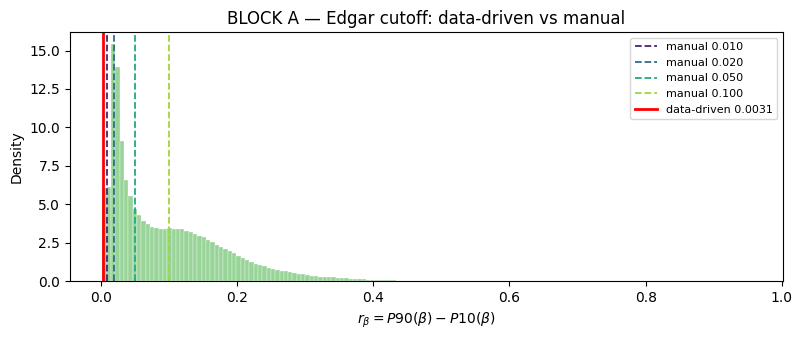


>>> Valore suggerito da usare in R_BETA_CUTOFF: 0.003084419295191765
>>> Confrontalo con il tuo 0.05 e scegli tu.


In [5]:
# ============================================================
# DIAGNOSTIC BLOCKS — da runnare PRIMA delle celle originali
# per vedere i valori data-driven PRIMA di decidere
# ============================================================
# Struttura:
#   BLOCK A — Edgar r_beta cutoff (da runnare dopo STEP 1, prima del filtro Edgar)
#   BLOCK B — Variance filter cutoff (da runnare dopo beta->M, prima del var filter)
#   BLOCK C — |ΔM| cutoff (da runnare dopo STEP 3 score, prima del filtro candidati)
#   BLOCK D — SCORE biologico (sostituzione completa della parte score in STEP 3)
# ============================================================


# ╔══════════════════════════════════════════════════════════╗
# ║  BLOCK A — Edgar r_beta cutoff automatico               ║
# ║  DOVE: metti questa cella DOPO la cella STEP 0-1        ║
# ║  (dopo che r_beta è stato calcolato, prima del filtro)  ║
# ╚══════════════════════════════════════════════════════════╝

def diagnose_edgar_cutoff(r_beta, candidate_cutoffs=[0.01, 0.02, 0.05, 0.10]):
    """
    Mostra il cutoff data-driven (gomito) e quante CpG vengono rimosse
    per ogni cutoff candidato. Decidi tu quale usare.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    try:
        from kneed import KneeLocator
        r_sorted = np.sort(r_beta)
        x = np.arange(len(r_sorted))
        kl = KneeLocator(x, r_sorted, curve="concave", direction="increasing")
        knee_val = float(r_sorted[kl.knee]) if kl.knee is not None else None
    except ImportError:
        print("kneed non disponibile — installa con: !pip install kneed -q")
        knee_val = None

    print("=" * 60)
    print("BLOCK A — Edgar r_beta cutoff diagnostics")
    print("=" * 60)
    print(f"r_beta: min={r_beta.min():.4f}  max={r_beta.max():.4f}"
          f"  median={np.median(r_beta):.4f}")
    print()

    if knee_val is not None:
        n_rem = int((r_beta < knee_val).sum())
        n_keep = int((r_beta >= knee_val).sum())
        print(f"  → Cutoff DATA-DRIVEN (gomito): {knee_val:.4f}")
        print(f"    Rimosse: {n_rem:,}  |  Tenute: {n_keep:,}  ({100*n_keep/len(r_beta):.1f}%)")
    else:
        print("  → Cutoff data-driven: NON calcolato (kneed mancante)")
    print()
    print("  Confronto con cutoff manuali:")
    for c in candidate_cutoffs:
        n_rem = int((r_beta < c).sum())
        n_keep = int((r_beta >= c).sum())
        marker = " ← originale" if c == 0.05 else ""
        print(f"    cutoff={c:.3f}  →  rimosse={n_rem:,}  tenute={n_keep:,}"
              f"  ({100*n_keep/len(r_beta):.1f}%){marker}")
    print()
    print("  DECISIONE: scegli il valore da usare in R_BETA_CUTOFF nella cella STEP 0-1")
    print("=" * 60)

    # plot
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(r_beta, bins=150, density=True, alpha=0.8, color="#7FC97F",
            edgecolor="white", linewidth=0.3)
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(candidate_cutoffs)))
    for c, col in zip(candidate_cutoffs, colors):
        ax.axvline(c, linestyle="--", linewidth=1.3, color=col, label=f"manual {c:.3f}")
    if knee_val is not None:
        ax.axvline(knee_val, linestyle="-", linewidth=2.0,
                   color="red", label=f"data-driven {knee_val:.4f}")
    ax.set_xlabel(r"$r_\beta = P90(\beta) - P10(\beta)$")
    ax.set_ylabel("Density")
    ax.set_title("BLOCK A — Edgar cutoff: data-driven vs manual")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return knee_val

# RUNNA così (dopo STEP 0-1):
!pip install kneed -q
edgar_cutoff_suggested = diagnose_edgar_cutoff(r_beta)
print(f"\n>>> Valore suggerito da usare in R_BETA_CUTOFF: {edgar_cutoff_suggested}")
print(">>> Confrontalo con il tuo 0.05 e scegli tu.")


Edgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs

Saved plot to: plots_outputs/GSE287331_edgar_variability.pdf


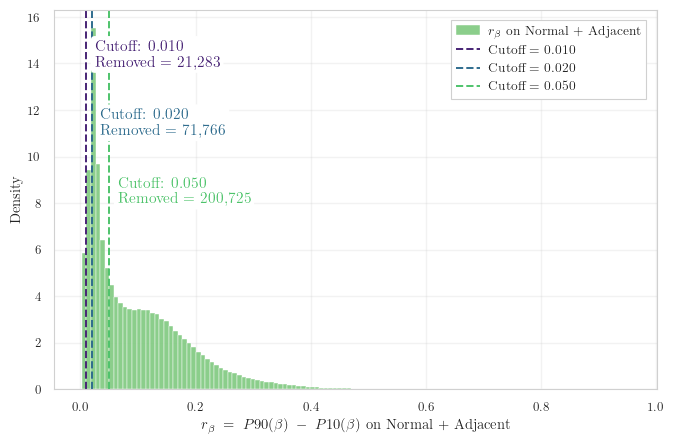

In [6]:
# -----------------------------
# PLOT — Edgar(β) variability (train-only) — white background only (no border)
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nEdgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

r_beta = np.asarray(r_beta, dtype=float)

cutoffs = [0.010, 0.020, 0.050]

HIST_COLOR = "#7FC97F"

LINE_COLORS = {
    0.010: plt.cm.viridis(0.10),
    0.020: plt.cm.viridis(0.35),
    0.050: plt.cm.viridis(0.72),
}

HIST_LABEL = r"$r_\beta$ on Normal + Adjacent"
XLABEL = r"$r_\beta \;=\; P90(\beta)\;-\;P10(\beta)$ on Normal + Adjacent"

fig, ax = plt.subplots()

ax.hist(
    r_beta,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=HIST_LABEL,
    zorder=1,
)

ymax = ax.get_ylim()[1]
X_SHIFT = 0.015

for i, c in enumerate(cutoffs):
    col = LINE_COLORS[c]

    ax.axvline(
        c,
        linestyle="--",
        linewidth=1.4,
        color=col,
        label=rf"Cutoff = {c:0.3f}",
        zorder=2,
    )

    removed = int((r_beta < c).sum())

    ax.text(
        c + X_SHIFT,
        ymax * (0.92 - 0.18 * i),
        f"Cutoff: {c:0.3f}\nRemoved = {removed:,}",
        color=col,
        fontsize=11.0,
        fontweight="semibold",
        ha="left",
        va="top",
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            linewidth=0,
            alpha=1.0,
        ),
    )

ax.set_xlabel(XLABEL)
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF) — after fig exists
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE287331_edgar_variability.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()



STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(193, 286000) | M_test=(49, 286000)
BLOCK B — Variance filter cutoff diagnostics
SD(M): min=0.1178  max=5.1685  median=0.5144

  → Nessuna valle trovata — distribuzione unimodale
    Suggerimento: usa drop_frac=0.02 (originale)

  Confronto con frazioni manuali:
    drop_frac=1.00%  SD_thr=0.2215  rimosse=2,860  tenute=283,140
    drop_frac=2.00%  SD_thr=0.2439  rimosse=5,720  tenute=280,280 ← originale
    drop_frac=5.00%  SD_thr=0.2816  rimosse=14,300  tenute=271,700
    drop_frac=10.00%  SD_thr=0.3203  rimosse=28,600  tenute=257,400

  DECISIONE: scegli il valore da usare in VAR_DROP_FRAC nella cella STEP 2


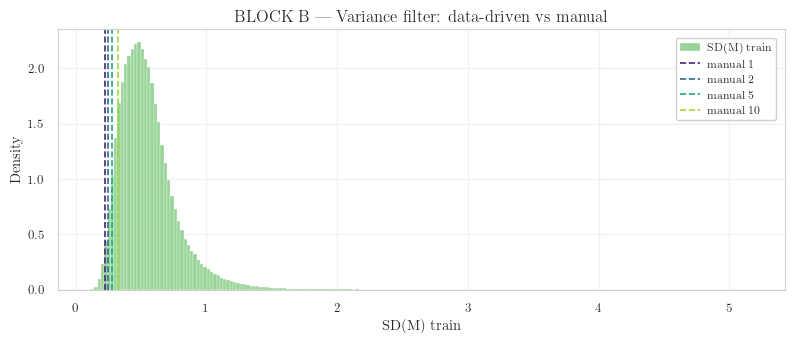


>>> Valore suggerito per VAR_DROP_FRAC: None
>>> Confrontalo con il tuo 0.02 e scegli tu.


In [7]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# ╔══════════════════════════════════════════════════════════╗
# ║  BLOCK B — Variance filter cutoff automatico            ║
# ║  DOVE: metti questa cella DOPO beta->M (inizio STEP 2)  ║
# ║  ma PRIMA del filtro soft_sd_filter                     ║
# ╚══════════════════════════════════════════════════════════╝

def diagnose_var_cutoff(M_train, candidate_fracs=[0.01, 0.02, 0.05, 0.10]):
    """
    Mostra il cutoff variance data-driven (prima valle della distribuzione SD)
    e quante CpG vengono rimosse per ogni frazione candidata.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.signal import find_peaks

    sd = M_train.std(axis=0, ddof=1)

    # cerca prima valle
    hist_vals, bin_edges = np.histogram(sd, bins=300)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    valleys, props = find_peaks(-hist_vals, prominence=hist_vals.max() * 0.05)

    if len(valleys) > 0:
        valley_sd = float(bin_centers[valleys[0]])
        frac_at_valley = float((sd < valley_sd).mean())
    else:
        valley_sd = None
        frac_at_valley = None

    print("=" * 60)
    print("BLOCK B — Variance filter cutoff diagnostics")
    print("=" * 60)
    print(f"SD(M): min={sd.min():.4f}  max={sd.max():.4f}  median={np.median(sd):.4f}")
    print()

    if valley_sd is not None:
        n_rem = int((sd < valley_sd).sum())
        n_keep = int((sd >= valley_sd).sum())
        print(f"  → Cutoff DATA-DRIVEN (prima valle): SD={valley_sd:.4f}")
        print(f"    Equivale a drop_frac={frac_at_valley:.3%}")
        print(f"    Rimosse: {n_rem:,}  |  Tenute: {n_keep:,}  ({100*n_keep/sd.size:.1f}%)")
    else:
        print("  → Nessuna valle trovata — distribuzione unimodale")
        print("    Suggerimento: usa drop_frac=0.02 (originale)")
    print()
    print("  Confronto con frazioni manuali:")
    for f in candidate_fracs:
        thr = float(np.quantile(sd, f))
        n_rem = int((sd < thr).sum())
        n_keep = sd.size - n_rem
        marker = " ← originale" if f == 0.02 else ""
        print(f"    drop_frac={f:.2%}  SD_thr={thr:.4f}  "
              f"rimosse={n_rem:,}  tenute={n_keep:,}{marker}")
    print()
    print("  DECISIONE: scegli il valore da usare in VAR_DROP_FRAC nella cella STEP 2")
    print("=" * 60)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(sd, bins=200, density=True, alpha=0.8, color="#7FC97F",
            edgecolor="white", linewidth=0.3, label="SD(M) train")
    if valley_sd is not None:
        ax.axvline(valley_sd, linestyle="-", linewidth=2.0,
                   color="red", label=f"data-driven (valle) {valley_sd:.4f}")
    colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(candidate_fracs)))
    for f, col in zip(candidate_fracs, colors):
        thr = float(np.quantile(sd, f))
        ax.axvline(thr, linestyle="--", linewidth=1.2, color=col,
                   label=f"manual {f:.0%} → {thr:.4f}")
    ax.set_xlabel("SD(M) train")
    ax.set_ylabel("Density")
    ax.set_title("BLOCK B — Variance filter: data-driven vs manual")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return frac_at_valley

# RUNNA così (dopo beta->M, prima del filtro):
var_frac_suggested = diagnose_var_cutoff(M_train)
print(f"\n>>> Valore suggerito per VAR_DROP_FRAC: {var_frac_suggested}")
print(">>> Confrontalo con il tuo 0.02 e scegli tu.")


In [8]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# Variance/SD filter (train-only), optional
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    M_train_f, cols_f, sd_f, keep_mask = soft_sd_filter(M_train, cols_full, drop_frac=VAR_DROP_FRAC)
    M_test_f = M_test[:, keep_mask]

    print(f"Variance filter: drop_frac={VAR_DROP_FRAC:.2%}")
    print(f"CpGs before: {M_train.shape[1]:,} | after: {M_train_f.shape[1]:,}  (dropped {M_train.shape[1]-M_train_f.shape[1]:,})")

    # overwrite "current" matrices/cols for next steps
    M_train, M_test, cols_full = M_train_f, M_test_f, cols_f
else:
    print("Variance filter OFF (no CpGs removed).")

# keep aligned beta matrices too (needed later for |Δβ| gates)
# B_train/B_test remain post-Edgar; apply same keep_mask if variance filter ON
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    B_train = B_train[:, keep_mask]
    B_test  = B_test[:, keep_mask]
    cpg_cols_current = cols_full.copy()
else:
    cpg_cols_current = cols_full.copy()

print(f"Current aligned: B_train={B_train.shape} | M_train={M_train.shape} | CpGs={len(cpg_cols_current):,}")



STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(193, 286000) | M_test=(49, 286000)
Variance filter: drop_frac=2.00%
CpGs before: 286,000 | after: 280,280  (dropped 5,720)
Current aligned: B_train=(193, 280280) | M_train=(193, 280280) | CpGs=280,280



STEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%

Saved plot to: plots_outputs/GSE287331_sdM_variance_filter.pdf


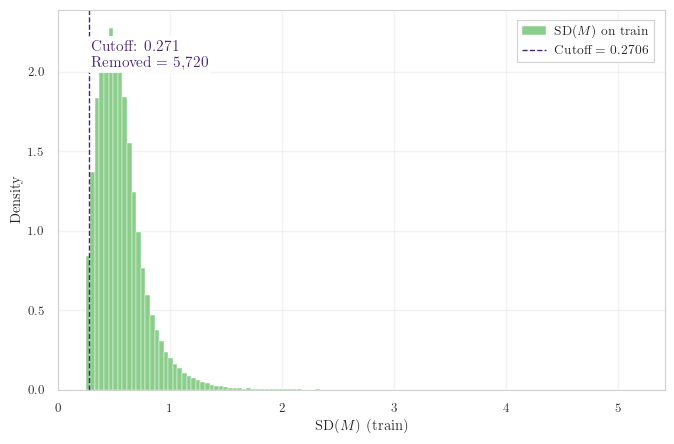

Kept = 274,560 / 280,280 CpGs (Removed = 5,720)


In [9]:
# =============================
# STEP 2 — PLOT: SD(M) distribution + 2% cutoff (train-only)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# Recompute pre-filter SD (identical to STEP 2 input)
M_train_pre = beta_to_m(B_train, eps=EPS_M).astype(np.float32)

sd_pre = M_train_pre.std(axis=0, ddof=1)
thr = float(np.quantile(sd_pre, VAR_DROP_FRAC))

total = int(sd_pre.size)
removed = int((~keep_mask).sum())
kept = total - removed

fig, ax = plt.subplots()

# Histogram (same green as Edgar)
HIST_COLOR = "#7FC97F"
ax.hist(
    sd_pre,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{SD}(M)$ on train",
    zorder=1,
)

# Cutoff line
cut_color = plt.cm.viridis(0.10)
ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=cut_color,
    label=rf"Cutoff = {thr:.4f}",
    zorder=2,
)

ax.set_xlabel(r"$\mathrm{SD}(M)$ (train)")
ax.set_ylabel("Density")

# Annotation
X_SHIFT = 0.02
ymax = ax.get_ylim()[1]

ax.text(
    thr + X_SHIFT,
    ymax * 0.92,
    f"Cutoff: {thr:.3f}\nRemoved = {removed:,}",
    color=cut_color,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE287331_sdM_variance_filter.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Kept = {kept:,} / {total:,} CpGs (Removed = {removed:,})")


In [10]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only, DIRECTIVE-COMPLIANT)
#   K=5, R=10
#   per split:
#     - compute MWU p-values on TRAIN-FOLD only
#     - compute |ΔM| and sign on TRAIN-FOLD only (for ranking)
#     - compute sign on VAL-FOLD (for stability check)
#   aggregate across splits:
#     score = 0.5*mean(rank_p_train) + 0.5*mean(rank_|ΔM|_train)
#     stability_sign = fraction of splits where sign_train == sign_val (and non-zero)
#     stability_sign >= 0.75
#     |ΔM| >= 0.15 (fallback 0.10 if too few candidates)
#   output: top 15k CpGs (candidates)
# -----------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|")
print("=" * 90)

# CONFIG
K_FOLDS = 5
R_REPEATS = 10
STABILITY_SIGN_MIN = 0.75
DELTA_M_THR_MAIN = 0.15
DELTA_M_THR_FALLBACK = 0.10
TOP_CANDIDATES = 15000
MIN_CANDIDATES_TARGET = 15000  # "collassa" if well below this

# Assumes available from STEP 2 (post-Edgar + optional var filter):
#   M_train (n_train, p), y_train (n_train,), cpg_cols_current (p,)
X = M_train
y = y_train
cols = np.array(cpg_cols_current, dtype=object)

n, p = X.shape
rkf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE)
n_splits_total = K_FOLDS * R_REPEATS
print(f"Train: n={n} | p={p:,} | splits={n_splits_total} (K={K_FOLDS}, R={R_REPEATS})")

# accumulators for score
rank_p_sum = np.zeros(p, dtype=np.float64)
rank_dm_sum = np.zeros(p, dtype=np.float64)

# accumulators for sign stability (train vs val)
sign_agree_count = np.zeros(p, dtype=np.int32)   # count splits where sign_train == sign_val and both non-zero
sign_valid_count = np.zeros(p, dtype=np.int32)   # count splits where both classes present in train+val and signs non-zero

valid_splits_for_score = 0

def _ranks_ascending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where smaller values -> smaller rank (best=1)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where larger values -> smaller rank (best=1)."""
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_va = X[val_idx]
    y_va = y[val_idx]

    # ensure both classes present in both folds (should hold with stratification, but keep safe)
    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    # TRAIN-FOLD ΔM (signed + abs) used for ranking
    dM_tr = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)

    # VAL-FOLD ΔM only for sign stability
    dM_va = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)  # -1,0,+1
    sign_va = np.sign(dM_va).astype(np.int8)

    # sign stability: count agreement where both non-zero
    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # MWU p-values on TRAIN-FOLD only
    # --- PREFILTER by |ΔM| to avoid MWU on all CpGs ---
    PREFILTER_TOP_DM = 50000   # you can tune (30k–70k reasonable)
    PRINT_EVERY = 1            # progress frequency
    
    # 1) prefilter indices by |ΔM| (train-fold)
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)
    
    # 2) MWU only on prefiltered CpGs
    pvals = np.ones(p, dtype=np.float64)  # default worst p-value
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided",
            method="asymptotic"
        ).pvalue


    # ranks per split (TRAIN-FOLD only)
    r_p = _ranks_ascending(pvals)       # best small p -> rank 1
    r_dm = _ranks_descending(abs_dM_tr) # best large |ΔM| -> rank 1

    rank_p_sum += r_p
    rank_dm_sum += r_dm
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == n_splits_total:
        print(f"  done split {split_id:>3}/{n_splits_total} | pf={idx_pf.size:,} | valid_for_score={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits computed in RSKF step (check labels / stratification).")

# aggregate score
mean_rank_p = rank_p_sum / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score
score = 0.5 * mean_rank_p + 0.5 * mean_rank_dm

# stability_sign = fraction of splits where sign_train == sign_val (only where both non-zero)
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]
# if never valid (rare), keep 0 stability (will be filtered out)

# global ΔM estimate on full TRAIN (used for thresholding)
dM_full = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)


# ╔══════════════════════════════════════════════════════════╗
# ║  BLOCK C — |ΔM| cutoff automatico                       ║
# ║  DOVE: metti questa cella DOPO il calcolo di            ║
# ║  abs_dM_full in STEP 3, ma PRIMA di mask_cand           ║
# ╚══════════════════════════════════════════════════════════╝

def diagnose_deltam_cutoff(abs_dM_full, candidate_cutoffs=[0.10, 0.15, 0.20, 0.30],
                            candidate_percentiles=[50, 60, 70, 80]):
    """
    Mostra il cutoff |ΔM| data-driven (percentile adattivo) e fisso.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    print("=" * 60)
    print("BLOCK C — |ΔM| cutoff diagnostics")
    print("=" * 60)
    print(f"|ΔM|: min={abs_dM_full.min():.4f}  max={abs_dM_full.max():.4f}"
          f"  median={np.median(abs_dM_full):.4f}")
    print()
    print("  Cutoff PERCENTILE (data-driven):")
    for p in candidate_percentiles:
        thr = float(np.percentile(abs_dM_full, p))
        n_keep = int((abs_dM_full >= thr).sum())
        print(f"    p{p}={thr:.4f}  →  tenute={n_keep:,}  ({100*n_keep/abs_dM_full.size:.1f}%)")
    print()
    print("  Cutoff FISSI (originali):")
    for c in candidate_cutoffs:
        n_keep = int((abs_dM_full >= c).sum())
        marker = " ← originale main" if c == 0.15 else \
                 " ← originale fallback" if c == 0.10 else ""
        print(f"    cutoff={c:.2f}  →  tenute={n_keep:,}"
              f"  ({100*n_keep/abs_dM_full.size:.1f}%){marker}")
    print()
    print("  DECISIONE: scegli tra percentile o fisso.")
    print("    Se vuoi data-driven: usa np.percentile(abs_dM_full, X)")
    print("    Se vuoi fisso: usa 0.15 (originale)")
    print("=" * 60)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(abs_dM_full, bins=200, density=True, alpha=0.8, color="#7FC97F",
            edgecolor="white", linewidth=0.3)
    colors_p = plt.cm.viridis(np.linspace(0.1, 0.7, len(candidate_percentiles)))
    for p, col in zip(candidate_percentiles, colors_p):
        thr = float(np.percentile(abs_dM_full, p))
        ax.axvline(thr, linestyle=":", linewidth=1.5, color=col,
                   label=f"p{p}={thr:.3f}")
    colors_f = plt.cm.plasma(np.linspace(0.2, 0.8, len(candidate_cutoffs)))
    for c, col in zip(candidate_cutoffs, colors_f):
        ax.axvline(c, linestyle="--", linewidth=1.2, color=col,
                   label=f"fixed {c:.2f}")
    ax.set_xlabel(r"$|\Delta M|$ train")
    ax.set_ylabel("Density")
    ax.set_title("BLOCK C — |ΔM| cutoff: percentile vs fixed")
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

# RUNNA così (dopo abs_dM_full calcolato in STEP 3):
diagnose_deltam_cutoff(abs_dM_full)
print("\n>>> Guarda il plot e scegli il valore da usare in DELTA_M_THR_MAIN")



STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|
Train: n=193 | p=280,280 | splits=50 (K=5, R=10)
  done split   1/50 | pf=50,000 | valid_for_score=1
  done split   2/50 | pf=50,000 | valid_for_score=2
  done split   3/50 | pf=50,000 | valid_for_score=3
  done split   4/50 | pf=50,000 | valid_for_score=4
  done split   5/50 | pf=50,000 | valid_for_score=5
  done split   6/50 | pf=50,000 | valid_for_score=6
  done split   7/50 | pf=50,000 | valid_for_score=7
  done split   8/50 | pf=50,000 | valid_for_score=8
  done split   9/50 | pf=50,000 | valid_for_score=9
  done split  10/50 | pf=50,000 | valid_for_score=10
  done split  11/50 | pf=50,000 | valid_for_score=11
  done split  12/50 | pf=50,000 | valid_for_score=12
  done split  13/50 | pf=50,000 | valid_for_score=13
  done split  14/50 | pf=50,000 | valid_for_score=14
  done split  15/50 | pf=50,000 | valid_for_score=15
  done split  16/50 | pf=50,000 | valid_for_score=16
  done split  17/50 | pf=50,000 |

RuntimeError: latex was not able to process the following string:
b'BLOCK C \\u2014 |\\u0394M| cutoff: percentile vs fixed'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpa92ttx6p f47eb57b39adb75e974480a4a6c035c3.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./f47eb57b39adb75e974480a4a6c035c3.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-di

Error in callback <function _draw_all_if_interactive at 0x78c165d36160> (for post_execute):


RuntimeError: latex was not able to process the following string:
b'BLOCK C \\u2014 |\\u0394M| cutoff: percentile vs fixed'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpobwj8396 f47eb57b39adb75e974480a4a6c035c3.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./f47eb57b39adb75e974480a4a6c035c3.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-di

RuntimeError: latex was not able to process the following string:
b'BLOCK C \\u2014 |\\u0394M| cutoff: percentile vs fixed'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpps4owwk6 f47eb57b39adb75e974480a4a6c035c3.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./f47eb57b39adb75e974480a4a6c035c3.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-di

<Figure size 800x350 with 1 Axes>

In [ ]:
print("working")

In [11]:
# ============================================================
# STEP 2.5 — Bio-weight (DA METTERE TRA STEP2 e STEP3)
# ============================================================

import pandas as pd
import numpy as np

MANIFEST_PATH_BIO = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

def load_manifest_bio(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Header manifest non trovato (colonna IlmnID).")

    df = pd.read_csv(
        path,
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
        usecols=["IlmnID", "Relation_to_UCSC_CpG_Island", "UCSC_RefGene_Group"],
    )
    df.columns = [c.strip() for c in df.columns]
    df["IlmnID"] = df["IlmnID"].astype(str).str.strip()
    return df

man_bio = load_manifest_bio(MANIFEST_PATH_BIO)

island_cpgs = set(man_bio.loc[man_bio["Relation_to_UCSC_CpG_Island"] == "Island", "IlmnID"])
promoter_cpgs = set(
    man_bio.loc[
        man_bio["UCSC_RefGene_Group"].fillna("").astype(str).str.contains("TSS", na=False),
        "IlmnID"
    ]
)

cols_bio = np.array(cpg_cols_current, dtype=object)

bio_weight = np.array([
    1.00 if (c in island_cpgs and c in promoter_cpgs) else
    0.70 if (c in island_cpgs) else
    0.50 if (c in promoter_cpgs) else
    0.20
    for c in cols_bio
], dtype=np.float32)

# normalizza in [0,1]
bio_weight_norm = (bio_weight - bio_weight.min()) / (bio_weight.max() - bio_weight.min())

# diagnostica
n_top    = int((bio_weight == 1.00).sum())
n_island = int((bio_weight == 0.70).sum())
n_prom   = int((bio_weight == 0.50).sum())
n_other  = int((bio_weight == 0.20).sum())

print(f"[BIO] CpG in isola CpG    : {len(island_cpgs):,}")
print(f"[BIO] CpG in promotore TSS: {len(promoter_cpgs):,}")
print(f"[BIO] Entrambi            : {len(island_cpgs & promoter_cpgs):,}")
print(f"\n[BIO] Distribuzione peso biologico su {len(cols_bio):,} CpG (post STEP2):")
print(f"  isola+TSS (1.00): {n_top:,}   ({100*n_top/len(cols_bio):.1f}%)")
print(f"  isola     (0.70): {n_island:,}   ({100*n_island/len(cols_bio):.1f}%)")
print(f"  promotore (0.50): {n_prom:,}   ({100*n_prom/len(cols_bio):.1f}%)")
print(f"  altro     (0.20): {n_other:,}   ({100*n_other/len(cols_bio):.1f}%)")


[BIO] CpG in isola CpG    : 161,441
[BIO] CpG in promotore TSS: 196,657
[BIO] Entrambi            : 73,261

[BIO] Distribuzione peso biologico su 280,280 CpG (post STEP2):
  isola+TSS (1.00): 7,722   (2.8%)
  isola     (0.70): 20,396   (7.3%)
  promotore (0.50): 39,778   (14.2%)
  altro     (0.20): 212,384   (75.8%)


In [12]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only, DIRECTIVE-COMPLIANT)
#   K=5, R=10
#   per split:
#     - compute MWU p-values on TRAIN-FOLD only
#     - compute |ΔM| and sign on TRAIN-FOLD only (for ranking)
#     - compute sign on VAL-FOLD (for stability check)
#   aggregate across splits:
#     score = 0.5*mean(rank_p_train) + 0.5*mean(rank_|ΔM|_train)
#     stability_sign = fraction of splits where sign_train == sign_val (and non-zero)
#     stability_sign >= 0.75
#     |ΔM| >= 0.15 (fallback 0.10 if too few candidates)
#   output: top 15k CpGs (candidates)
# -----------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|")
print("=" * 90)

# CONFIG
K_FOLDS = 5
R_REPEATS = 10
STABILITY_SIGN_MIN = 0.75
#DELTA_M_THR_MAIN = 0.15 
#DELTA_M_THR_FALLBACK = 0.10
TOP_CANDIDATES = 15000
MIN_CANDIDATES_TARGET = 15000  # "collassa" if well below this

# Assumes available from STEP 2 (post-Edgar + optional var filter):
#   M_train (n_train, p), y_train (n_train,), cpg_cols_current (p,)
X = M_train
y = y_train
cols = np.array(cpg_cols_current, dtype=object)

n, p = X.shape
rkf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE)
n_splits_total = K_FOLDS * R_REPEATS
print(f"Train: n={n} | p={p:,} | splits={n_splits_total} (K={K_FOLDS}, R={R_REPEATS})")

# accumulators for score
rank_p_sum = np.zeros(p, dtype=np.float64)
rank_dm_sum = np.zeros(p, dtype=np.float64)

# accumulators for sign stability (train vs val)
sign_agree_count = np.zeros(p, dtype=np.int32)   # count splits where sign_train == sign_val and both non-zero
sign_valid_count = np.zeros(p, dtype=np.int32)   # count splits where both classes present in train+val and signs non-zero

valid_splits_for_score = 0

def _ranks_ascending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where smaller values -> smaller rank (best=1)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where larger values -> smaller rank (best=1)."""
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_va = X[val_idx]
    y_va = y[val_idx]

    # ensure both classes present in both folds (should hold with stratification, but keep safe)
    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    # TRAIN-FOLD ΔM (signed + abs) used for ranking
    dM_tr = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)

    # VAL-FOLD ΔM only for sign stability
    dM_va = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)  # -1,0,+1
    sign_va = np.sign(dM_va).astype(np.int8)

    # sign stability: count agreement where both non-zero
    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # MWU p-values on TRAIN-FOLD only
    # --- PREFILTER by |ΔM| to avoid MWU on all CpGs ---
    PREFILTER_TOP_DM = 50000   # you can tune (30k–70k reasonable)
    PRINT_EVERY = 1            # progress frequency
    
    # 1) prefilter indices by |ΔM| (train-fold)
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)
    
    # 2) MWU only on prefiltered CpGs
    pvals = np.ones(p, dtype=np.float64)  # default worst p-value
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided",
            method="asymptotic"
        ).pvalue


    # ranks per split (TRAIN-FOLD only)
    r_p = _ranks_ascending(pvals)       # best small p -> rank 1
    r_dm = _ranks_descending(abs_dM_tr) # best large |ΔM| -> rank 1

    rank_p_sum += r_p
    rank_dm_sum += r_dm
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == n_splits_total:
        print(f"  done split {split_id:>3}/{n_splits_total} | pf={idx_pf.size:,} | valid_for_score={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits computed in RSKF step (check labels / stratification).")

# aggregate score
#mean_rank_p = rank_p_sum / valid_splits_for_score
#mean_rank_dm = rank_dm_sum / valid_splits_for_score
#score = 0.5 * mean_rank_p + 0.5 * mean_rank_dm

mean_rank_p  = rank_p_sum  / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score

# METTI:
score_stat_raw = 0.5 * mean_rank_p + 0.5 * mean_rank_dm        # [1, p]
score_stat = (score_stat_raw - score_stat_raw.min()) / \
             (score_stat_raw.max() - score_stat_raw.min())      # [0, 1]
score_bio  = 1.0 - bio_weight_norm                              # [0, 1]
W_BIO = 0.20
score = (1.0 - W_BIO) * score_stat + W_BIO * score_bio         # [0, 1]


print(f"\n[BIO] Integrated score with W_BIO={W_BIO}:")
print(f"  score_stat range: [{score_stat.min():.4f}, {score_stat.max():.4f}]")
print(f"  score      range: [{score.min():.4f}, {score.max():.4f}]")

# stability_sign = fraction of splits where sign_train == sign_val (only where both non-zero)
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]
# if never valid (rare), keep 0 stability (will be filtered out)

# global ΔM estimate on full TRAIN (used for thresholding)
dM_full = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

DELTA_M_THR_MAIN = float(np.percentile(abs_dM_full, 60))
DELTA_M_THR_FALLBACK = float(np.percentile(abs_dM_full, 50))
print(f"|ΔM| cutoff p60 (main)    : {DELTA_M_THR_MAIN:.4f}")
print(f"|ΔM| cutoff p50 (fallback): {DELTA_M_THR_FALLBACK:.4f}")

# candidate filter with fallback
thr = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand = int(mask_cand.sum())
print(f"Candidates with |ΔM|>={thr:.2f} and stability_sign>={STABILITY_SIGN_MIN:.2f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    thr = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.2f}: candidates={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3 produced 0 candidates even after fallback. Lower thresholds or inspect data.")

# pick top 15k by score (lower is better)
cand_idx = np.where(mask_cand)[0]
order = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top = cand_idx_sorted[:min(TOP_CANDIDATES, cand_idx_sorted.size)]

cpg_candidates = cols[cand_idx_top]

# keep useful stats for later steps (region anchoring / reporting)
step3_stats = {
    "score": score[cand_idx_top],
    "score_stat": score_stat[cand_idx_top],
    "mean_rank_p": mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM": mean_rank_dm[cand_idx_top],
    "stability_sign": stability_sign[cand_idx_top],
    "deltaM_full": dM_full[cand_idx_top],
    "abs_deltaM_full": abs_dM_full[cand_idx_top],
    "used_deltaM_thr": thr,
    "valid_splits_for_score": valid_splits_for_score,
    "sign_valid_splits": sign_valid_count[cand_idx_top],
}

print(f"Selected top candidates: {len(cpg_candidates):,} (target {TOP_CANDIDATES:,})")
print("Example:", cpg_candidates[:5].tolist())



STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|
Train: n=193 | p=280,280 | splits=50 (K=5, R=10)
  done split   1/50 | pf=50,000 | valid_for_score=1
  done split   2/50 | pf=50,000 | valid_for_score=2
  done split   3/50 | pf=50,000 | valid_for_score=3
  done split   4/50 | pf=50,000 | valid_for_score=4
  done split   5/50 | pf=50,000 | valid_for_score=5
  done split   6/50 | pf=50,000 | valid_for_score=6
  done split   7/50 | pf=50,000 | valid_for_score=7
  done split   8/50 | pf=50,000 | valid_for_score=8
  done split   9/50 | pf=50,000 | valid_for_score=9
  done split  10/50 | pf=50,000 | valid_for_score=10
  done split  11/50 | pf=50,000 | valid_for_score=11
  done split  12/50 | pf=50,000 | valid_for_score=12
  done split  13/50 | pf=50,000 | valid_for_score=13
  done split  14/50 | pf=50,000 | valid_for_score=14
  done split  15/50 | pf=50,000 | valid_for_score=15
  done split  16/50 | pf=50,000 | valid_for_score=16
  done split  17/50 | pf=50,000 |


STEP 3 — stability_sign distribution (train↔val agreement)

Saved plot to: plots_outputs/GSE287331_stability_sign_distribution.pdf


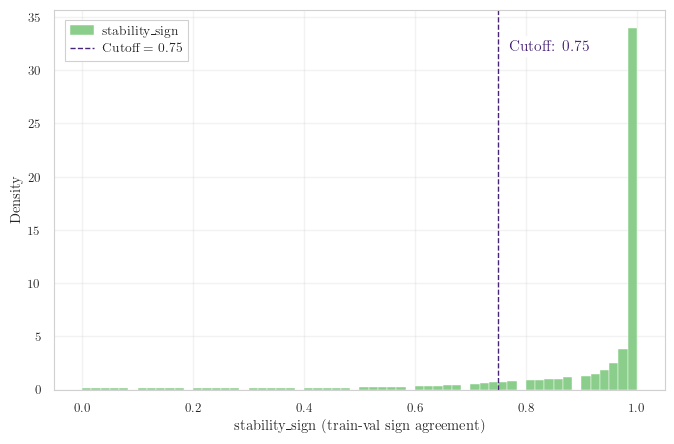

In [13]:
# =============================
# STEP 3 — PLOT: stability_sign distribution (train↔val agreement)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_NAME = "GSE287331"   # <-- modifica se necessario

print("\nSTEP 3 — stability_sign distribution (train↔val agreement)\n")

apply_thesis_style(use_tex=True, legend_position="upper left", legend_outside=False)

fig, ax = plt.subplots()

HIST_COLOR = "#7FC97F"
CUT_COLOR = plt.cm.viridis(0.10)

ax.hist(
    stability_sign,
    bins=60,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label="stability_sign",
    zorder=1,
)

ax.axvline(
    STABILITY_SIGN_MIN,
    linestyle="--",
    linewidth=1.0,
    color=CUT_COLOR,
    label=rf"Cutoff = {STABILITY_SIGN_MIN:.2f}",
    zorder=2,
)

ax.set_xlabel("stability_sign (train-val sign agreement)")
ax.set_ylabel("Density")

# annotation (white background only, no border)
ymax = ax.get_ylim()[1]
ax.text(
    STABILITY_SIGN_MIN + 0.02,
    ymax * 0.92,
    f"Cutoff: {STABILITY_SIGN_MIN:.2f}",
    color=CUT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_stability_sign_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()



STEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)

Saved plot to: plots_outputs/GSE287331_absDeltaM_vs_score.pdf


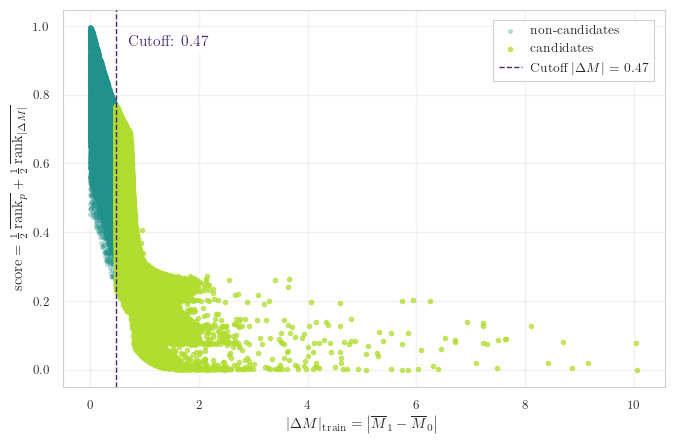

In [14]:
# =============================
# STEP 3 — PLOT: RSKF score vs |ΔM| (viridis coherent palette)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

score = np.asarray(score, dtype=float)
abs_dM_full = np.asarray(abs_dM_full, dtype=float)
mask_cand = np.asarray(mask_cand, dtype=bool)

idx_cand = np.where(mask_cand)[0]
idx_non = np.where(~mask_cand)[0]

MAX_NON = 25000
if idx_non.size > MAX_NON:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_non = rng.choice(idx_non, size=MAX_NON, replace=False)

# --- VIRIDIS PALETTE ---
c_non   = plt.cm.viridis(0.50)  # verde medio/scuro (tolte)
c_cand  = plt.cm.viridis(0.88)  # giallo-verde chiaro (tenute)
c_line  = plt.cm.viridis(0.10)  # verde scuro (cutoff)

fig, ax = plt.subplots()

ax.scatter(
    abs_dM_full[idx_non],
    score[idx_non],
    s=7,
    alpha=0.25,
    color=c_non,
    label="non-candidates",
    zorder=1,
)

ax.scatter(
    abs_dM_full[idx_cand],
    score[idx_cand],
    s=9,
    alpha=0.70,
    color=c_cand,
    label="candidates",
    zorder=2,
)

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=c_line,
    label=rf"Cutoff $|\Delta M|$ = {thr:.2f}",
    zorder=3,
)

ax.set_xlabel(r"$|\Delta M|_{\mathrm{train}} = \left|\overline{M}_{1} - \overline{M}_{0}\right|$")
ax.set_ylabel(
    r"$\mathrm{score} = \frac{1}{2}\,\overline{\mathrm{rank}_{p}} + \frac{1}{2}\,\overline{\mathrm{rank}_{|\Delta M|}}$"
)

# Annotazione cutoff stile Edgar
ymax = ax.get_ylim()[1]
x_text = thr + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

ax.text(
    x_text,
    ymax * 0.93,
    f"Cutoff: {thr:.2f}",
    color=c_line,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTDIR / f"{DATASET_NAME}_absDeltaM_vs_score.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


In [15]:
# =============================
# STEP 3 — CHECK: Spearman corr(score, |ΔM|) on TRAIN
#   tells you if the score is basically dominated by effect size
# =============================

import numpy as np
from scipy.stats import spearmanr

print("\nSTEP 3 — Spearman correlation between score and |ΔM| (full train)\n")

# Assumes from STEP 3 you have:
#   score        : np.ndarray (len p)
#   abs_dM_full  : np.ndarray (len p)
#   mask_cand    : np.ndarray bool (len p)  [optional]
#   cpg_cols_current : list/array CpG ids (len p) [optional]

score_arr = np.asarray(score, dtype=float)
absdm_arr = np.asarray(abs_dM_full, dtype=float)

# Safety: remove NaNs/Infs if any
ok = np.isfinite(score_arr) & np.isfinite(absdm_arr)
score_ok = score_arr[ok]
absdm_ok = absdm_arr[ok]

# Spearman on all CpGs
rho_all, p_all = spearmanr(score_ok, absdm_ok)

print(f"[ALL CpGs] Spearman rho(score, |ΔM|) = {rho_all:.4f} | p-value = {p_all:.3e} | n = {score_ok.size:,}")

# Optional: Spearman on candidates only (after stability + |ΔM| thresholds)
if "mask_cand" in globals():
    mask = np.asarray(mask_cand, dtype=bool)
    mask = mask & ok
    if mask.sum() > 10:
        rho_c, p_c = spearmanr(score_arr[mask], absdm_arr[mask])
        print(f"[CANDIDATES] Spearman rho(score, |ΔM|) = {rho_c:.4f} | p-value = {p_c:.3e} | n = {int(mask.sum()):,}")
    else:
        print("[CANDIDATES] not enough points to compute reliably.")

# Optional: quick diagnostic interpretation
if np.isfinite(rho_all):
    if abs(rho_all) > 0.90:
        print("Interpretation: |rho|>0.90 ⇒ score is (almost) monotone in |ΔM| → ranking dominated by effect size.")
    elif abs(rho_all) > 0.70:
        print("Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.")
    else:
        print("Interpretation: |rho|<=0.70 ⇒ MWU ranks contribute materially beyond effect size.")



STEP 3 — Spearman correlation between score and |ΔM| (full train)

[ALL CpGs] Spearman rho(score, |ΔM|) = -0.8061 | p-value = 0.000e+00 | n = 280,280
[CANDIDATES] Spearman rho(score, |ΔM|) = -0.8405 | p-value = 0.000e+00 | n = 112,108
Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.


In [16]:
# -----------------------------
# STEP 3b — Region anchoring su CpG islands (DIRECTIVE-COMPLIANT)
#   region_score = median(score) × fraction_stable
#   fraction_stable >= 0.6, >= 2 CpG per regione
#   top-m (m=2-3) per regione -> Pool A [anchored]
#   resto -> Pool B [non-anchored]
#
# NOTE (aderenza):
# - "fraction_stable" qui è calcolata su CpG che rispettano i vincoli di STEP 3:
#     stability_sign >= 0.75  AND  |ΔM| >= thr_usato_in_step3
#   (thr_usato_in_step3 = 0.15 oppure 0.10 se fallback)
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 3b — Region anchoring su CpG islands")
print("=" * 90)

# CONFIG
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_ISLAND_NAME_COL = "UCSC_CpG_Islands_Name"
MANIFEST_REL_COL = "Relation_to_UCSC_CpG_Island"

ANCHOR_CONTEXT = {"Island"}        # anchoring strictly on islands
FRACTION_STABLE_MIN = 0.60
MIN_CPGS_PER_REGION = 2
TOP_M_PER_REGION = 3               # set 2 or 3

# Assumes from STEP 3:
#   cpg_candidates : (n_cand,)
#   step3_stats["score"] : (n_cand,)   lower is better
#   step3_stats["stability_sign"] : (n_cand,)
#   step3_stats["abs_deltaM_full"] : (n_cand,)
#   step3_stats["used_deltaM_thr"] : scalar (0.15 or 0.10)
cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_stab  = np.array(step3_stats["stability_sign"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
thr_used   = float(step3_stats["used_deltaM_thr"])

if not (cand.shape[0] == cand_score.shape[0] == cand_stab.shape[0] == cand_absdM.shape[0]):
    raise RuntimeError("STEP 3b: candidate arrays are misaligned (cpg_candidates vs step3_stats).")

# Define CpG-level "stable" flag per STEP 3 directive (within the candidate set)
stable_cpg_flag = (cand_stab >= STABILITY_SIGN_MIN) & (cand_absdM >= thr_used)

print(f"Candidates: {cand.size:,}")
print(f"ΔM threshold used in STEP 3: {thr_used:.2f}")
print(f"Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): {int(stable_cpg_flag.sum()):,}")

# -----------------------------
# A) Build CpG -> island mapping (only Island context and named islands)
# -----------------------------
def load_manifest_with_real_header(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        start_row = None
        for i, line in enumerate(f):
            if line.startswith("IlmnID"):
                start_row = i
                break
    if start_row is None:
        raise ValueError(f"Non trovo header 'IlmnID' in: {path}")
    return pd.read_csv(path, skiprows=start_row, low_memory=False)

mf = load_manifest_with_real_header(MANIFEST_PATH)

# Keep only required columns
mf = mf[[MANIFEST_CPG_COL, MANIFEST_ISLAND_NAME_COL, MANIFEST_REL_COL]].copy()

mf.columns = ["cpg", "island", "rel"]

mf["cpg"] = mf["cpg"].astype(str)
mf["island"] = mf["island"].fillna("").astype(str).str.strip()
mf["rel"] = mf["rel"].fillna("").astype(str).str.strip()

# Filter strictly Island context + named islands
mf_island = mf[
    (mf["rel"].isin(list(ANCHOR_CONTEXT))) &
    (mf["island"] != "")
]

# CpG -> island dictionary
cpg_to_island = dict(zip(mf_island["cpg"], mf_island["island"]))

# map candidates to islands
island_id = np.array([cpg_to_island.get(c, None) for c in cand], dtype=object)
in_island = island_id != None
print(f"Mapped to named CpG islands (context={ANCHOR_CONTEXT}): {int(in_island.sum()):,}")

# -----------------------------
# B) Group by island, compute region_score and pick top-m CpGs per selected region
# -----------------------------
island_to_idx = {}
for i, rid in enumerate(island_id):
    if rid is None:
        continue
    island_to_idx.setdefault(rid, []).append(i)

region_rows = []
poolA_idx = []

for rid, idxs in island_to_idx.items():
    idxs = np.array(idxs, dtype=int)

    # constraint: >= 2 CpGs per region
    if idxs.size < MIN_CPGS_PER_REGION:
        continue

    # fraction_stable computed on STEP3 "stable" definition
    frac_stable = float(stable_cpg_flag[idxs].mean())
    if frac_stable < FRACTION_STABLE_MIN:
        continue

    # region_score = median(score) * fraction_stable
    med_score = float(np.median(cand_score[idxs]))
    region_score = med_score * frac_stable

    # top-m per region by candidate score (lower better)
    order = np.argsort(cand_score[idxs], kind="mergesort")
    chosen = idxs[order[:min(TOP_M_PER_REGION, idxs.size)]]
    poolA_idx.extend(chosen.tolist())

    region_rows.append((rid, idxs.size, frac_stable, med_score, region_score, chosen.size))

poolA_idx = np.array(sorted(set(poolA_idx)), dtype=int)

# -----------------------------
# C) Final pools
# -----------------------------
poolA_cpgs = cand[poolA_idx]  # anchored

maskA = np.zeros(cand.size, dtype=bool)
maskA[poolA_idx] = True
poolB_cpgs = cand[~maskA]     # non-anchored

print(f"Selected regions (pass constraints): {len(region_rows):,}")
print(f"Pool A (anchored) CpGs: {poolA_cpgs.size:,}  (top-m={TOP_M_PER_REGION} per region)")
print(f"Pool B (non-anchored) CpGs: {poolB_cpgs.size:,}")

region_summary = (
    pl.DataFrame(
        region_rows,
        schema=["island_id", "n_cpgs", "fraction_stable", "median_score", "region_score", "picked_m"]
    ).sort("region_score")
)

print("Top 5 regions by region_score (lower is better):")
print(region_summary.head(5))

# Outputs:
#   poolA_cpgs, poolB_cpgs, region_summary



STEP 3b — Region anchoring su CpG islands
Candidates: 15,000
ΔM threshold used in STEP 3: 0.47
Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): 15,000
Mapped to named CpG islands (context={'Island'}): 4,272
Selected regions (pass constraints): 705
Pool A (anchored) CpGs: 1,592  (top-m=3 per region)
Pool B (non-anchored) CpGs: 13,408
Top 5 regions by region_score (lower is better):
shape: (5, 6)
┌───────────────────────────┬────────┬─────────────────┬──────────────┬──────────────┬──────────┐
│ island_id                 ┆ n_cpgs ┆ fraction_stable ┆ median_score ┆ region_score ┆ picked_m │
│ ---                       ┆ ---    ┆ ---             ┆ ---          ┆ ---          ┆ ---      │
│ str                       ┆ i64    ┆ f64             ┆ f64          ┆ f64          ┆ i64      │
╞═══════════════════════════╪════════╪═════════════════╪══════════════╪══════════════╪══════════╡
│ chr14:102227441-102228854 ┆ 3      ┆ 1.0             ┆ 0.000587     ┆ 0.000587     ┆ 3        │
│ ch

In [17]:
from pathlib import Path
import polars as pl

# CONFIG
DATASET = "GSE287331"   # cambia: GSE287331 / GSE69914
OUTDIR = Path("./region_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# (opzionale ma consigliato) ordina e forza schema stabile
region_summary_out = (
    region_summary
    .select([
        "island_id",
        "n_cpgs",
        "fraction_stable",
        "median_score",
        "region_score",
        "picked_m",
    ])
    .with_columns([
        pl.col("island_id").cast(pl.Utf8),
        pl.col("n_cpgs").cast(pl.Int64),
        pl.col("picked_m").cast(pl.Int64),
        pl.col("fraction_stable").cast(pl.Float64),
        pl.col("median_score").cast(pl.Float64),
        pl.col("region_score").cast(pl.Float64),
    ])
    .sort(["region_score", "island_id"])
)

csv_path = OUTDIR / f"{DATASET}_region_summary.csv"
parq_path = OUTDIR / f"{DATASET}_region_summary.parquet"

region_summary_out.write_csv(csv_path)
region_summary_out.write_parquet(parq_path)

print(f"Saved CSV:   {csv_path}")
print(f"Saved PARQ:  {parq_path}")
print(f"Rows: {region_summary_out.height:,}")


Saved CSV:   region_outputs/GSE287331_region_summary.csv
Saved PARQ:  region_outputs/GSE287331_region_summary.parquet
Rows: 705



STEP 3b — Region anchoring: selected regions = 705

Saved plot to: plots_outputs/GSE287331_region_score_distribution.pdf


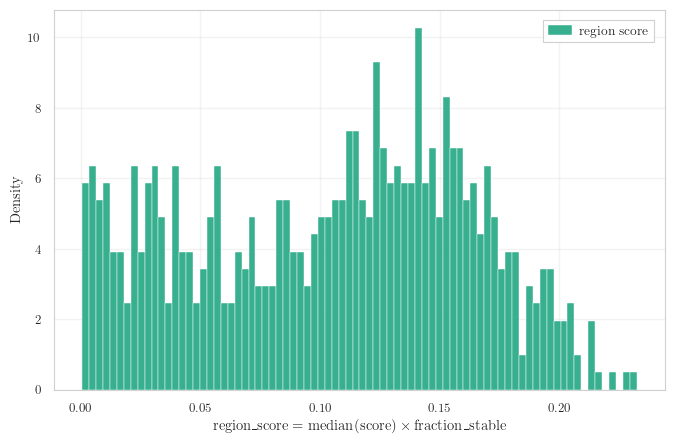

In [18]:
# =============================
# STEP 3b — PLOT: Region_score distribution (selected regions)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


print(f"\nSTEP 3b — Region anchoring: selected regions = {len(region_summary):,}\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# extract region_score
rs = region_summary.select("region_score").to_numpy().ravel().astype(float)

fig, ax = plt.subplots()

# histogram (viridis mid-green)
hist_color = plt.cm.viridis(0.60)

ax.hist(
    rs,
    bins=80,
    density=True,
    alpha=0.90,
    color=hist_color,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{region \; score}$",
)

ax.set_xlabel(r"$\mathrm{region\_score} = \mathrm{median}(\mathrm{score}) \times \mathrm{fraction\_stable}$")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_region_score_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()


In [19]:
# -----------------------------
# STEP 4 — Correlation clustering separato (DIRECTIVE-COMPLIANT)
#   Pool A: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Pool B: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Output: unione dei rappresentanti (A prima di B, unique)
#
# NOTE (aderenza):
# - correlazioni calcolate SOLO su TRAIN (M_train)
# - "miglior score" = minimo STEP3 score (0.5·mean(rank_p)+0.5·mean(rank_|ΔM|))
# - cluster = componenti connesse del grafo soglia |r|>=thr
# -----------------------------

import numpy as np

print("\n" + "=" * 90)
print("STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85")
print("=" * 90)

# CONFIG
CORR_CLUSTER_THR = 0.85

# Assumes from previous steps:
#   - M_train : (n_train, p_all)  TRAIN matrix in M-space (post STEP 2)
#   - cpg_cols_current : (p_all,) CpG names aligned to columns of M_train
#   - cpg_candidates : (n_cand,) top candidates from STEP 3
#   - step3_stats["score"] aligned to cpg_candidates (lower is better)
#   - poolA_cpgs, poolB_cpgs from STEP 3b

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)

# Map CpG -> STEP3 score (used to pick representative)
score_map = {c: s for c, s in zip(cand, cand_score)}

def _build_Z(pool_cpgs: np.ndarray):
    """
    Return standardized TRAIN matrix Z for pool CpGs and the ordered CpG list (aligned to Z columns).
    Standardization is per-CpG on TRAIN only.
    """
    pool = np.array([c for c in pool_cpgs if c in col_to_j], dtype=object)
    if pool.size == 0:
        return np.empty((M_train.shape[0], 0), dtype=np.float32), pool

    jj = np.array([col_to_j[c] for c in pool], dtype=int)
    Xp = M_train[:, jj].astype(np.float32, copy=False)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0, ddof=1) + 1e-12
    Z = (Xp - mu) / sd
    return Z, pool

def _connected_components_from_corr(Z: np.ndarray, thr: float):
    """
    Graph on CpGs where edge(i,j)=1 if |corr(i,j)|>=thr.
    Connected components = clusters.
    corr computed on standardized TRAIN data: C = (Z^T Z)/(n-1).
    """
    p = Z.shape[1]
    if p == 0:
        return []
    if p == 1:
        return [[0]]

    n = Z.shape[0]
    C = (Z.T @ Z) / (n - 1)
    A = (np.abs(C) >= thr)
    np.fill_diagonal(A, True)

    visited = np.zeros(p, dtype=bool)
    comps = []
    for i in range(p):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.where(A[u])[0]
            for v in nbrs:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(comp)
    return comps

def _pick_rep_by_best_score(pool_order: np.ndarray, comps):
    """Pick 1 CpG per component by minimal STEP3 score (lower is better)."""
    reps = []
    for comp in comps:
        members = pool_order[np.array(comp, dtype=int)]
        scores = np.array([score_map.get(c, np.inf) for c in members], dtype=float)
        best = members[int(np.argmin(scores))]
        reps.append(best)
    return np.array(reps, dtype=object)

def cluster_pool(pool_name: str, pool_cpgs: np.ndarray, thr: float):
    Z, pool_order = _build_Z(pool_cpgs)
    print(f"{pool_name}: CpGs in pool={pool_order.size:,}")

    if pool_order.size == 0:
        return np.array([], dtype=object), np.array([], dtype=int)

    comps = _connected_components_from_corr(Z, thr=thr)
    reps = _pick_rep_by_best_score(pool_order, comps)

    sizes = np.array([len(c) for c in comps], dtype=int)
    print(f"{pool_name}: clusters={len(comps):,} | reps={reps.size:,} | "
          f"median_cluster_size={int(np.median(sizes))} | max_cluster_size={int(sizes.max())}")
    return reps, sizes

# Separate clustering as per directive
reps_A, sizes_A = cluster_pool("Pool A (anchored)", poolA_cpgs, thr=CORR_CLUSTER_THR)
reps_B, sizes_B = cluster_pool("Pool B (non-anchored)", poolB_cpgs, thr=CORR_CLUSTER_THR)

# Union of representatives (A first, then B), unique
reps_union = np.array(list(dict.fromkeys(np.concatenate([reps_A, reps_B]).tolist())), dtype=object)

print(f"Union representatives: {reps_union.size:,} (A={reps_A.size:,}, B={reps_B.size:,})")

# Outputs for STEP 5:
#   reps_A, reps_B, reps_union



STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85
Pool A (anchored): CpGs in pool=1,592
Pool A (anchored): clusters=528 | reps=528 | median_cluster_size=1 | max_cluster_size=960
Pool B (non-anchored): CpGs in pool=13,408
Pool B (non-anchored): clusters=5,772 | reps=5,772 | median_cluster_size=1 | max_cluster_size=7534
Union representatives: 6,300 (A=528, B=5,772)


[OK] Saved PDF → figures/step4/GSE287331_cluster_size_ccdf_loglog_r0.85.pdf


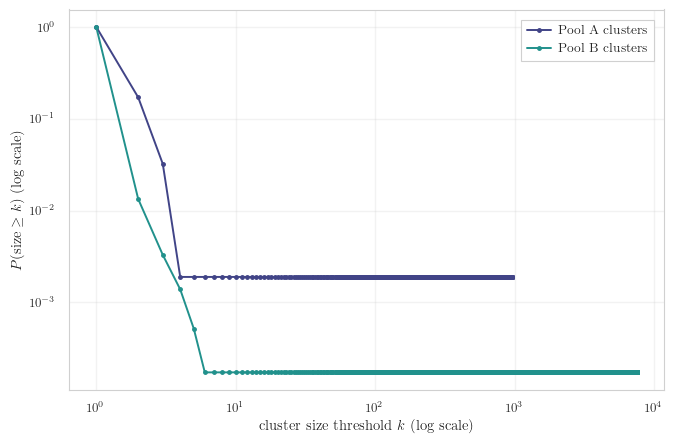

Correlation clustering tail (CCDF), $|r|\geq 0.85$


In [20]:
# =============================
# STEP 4 — PLOT (CCDF log-log, Viridis): Cluster size tail (Pool A vs Pool B)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

def ccdf_from_sizes(sizes: np.ndarray):
    sizes = np.asarray(sizes, dtype=int)
    sizes = sizes[sizes >= 1]
    if sizes.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    max_k = int(sizes.max())
    ks = np.arange(1, max_k + 1, dtype=int)

    hist = np.bincount(sizes, minlength=max_k + 1)
    tail_counts = np.cumsum(hist[::-1])[::-1]
    ccdf = tail_counts[ks] / float(sizes.size)
    return ks, ccdf

kA, ccdfA = ccdf_from_sizes(sizes_A)
kB, ccdfB = ccdf_from_sizes(sizes_B)

if ccdfA.size == 0 and ccdfB.size == 0:
    raise ValueError("Both sizes_A and sizes_B are empty.")

# --- Viridis colors ---
cmap = plt.cm.viridis
color_A = cmap(0.2)
color_B = cmap(0.5)

fig, ax = plt.subplots()

if ccdfA.size:
    ax.plot(kA, ccdfA,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_A, label="Pool A clusters")

if ccdfB.size:
    ax.plot(kB, ccdfB,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_B, label="Pool B clusters")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("cluster size threshold $k$ (log scale)")
ax.set_ylabel(r"$P(\mathrm{size}\geq k)$ (log scale)")


place_legend(ax)
fig.tight_layout()

OUT_DIR = Path("figures/step4")
OUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUT_DIR / f"GSE287331_cluster_size_ccdf_loglog_r{CORR_CLUSTER_THR:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[OK] Saved PDF → {pdf_path}")

plt.show()
print(f"Correlation clustering tail (CCDF), $|r|\geq {CORR_CLUSTER_THR:.2f}$")


In [21]:
# -----------------------------
# STEP 5 — Diversificazione soft + greedy (DIRECTIVE-COMPLIANT)
#   Vincoli (soft, target):
#     - chr <= 20% (sul K target, non dinamico su n_next)
#     - contesto <= 65% (sul K target, non dinamico su n_next)
#     - max 15 CpG / 500kb (vincolo spaziale hard finché non si rilassa)
#   Allentamento: spaziale -> contesto -> chr
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)")
print("=" * 90)

# CONFIG
K_TARGET = 5000
CHR_MAX_FRAC = 0.08
CTX_MAX_FRAC = 0.65
WIN_BP = 500_000
MAX_PER_WIN = 15

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_CHR_COL = "CHR"
MANIFEST_POS_COL = "MAPINFO"
MANIFEST_CTX_COL = "Relation_to_UCSC_CpG_Island"

# Assumes:
#   reps_union : (n_reps,)
#   score_map  : dict CpG -> STEP3 score (lower is better)
reps = np.array(reps_union, dtype=object)
if reps.size == 0:
    raise RuntimeError("STEP 5: reps_union is empty.")

# -----------------------------
# A) Manifest mapping CpG -> chr, pos, context
# -----------------------------
# -----------------------------
# Manifest load (robust) + mapping reps
# -----------------------------
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# Convert to Polars and normalize the needed columns
mf = pl.from_pandas(mf_pd).select([
    pl.col(MANIFEST_CPG_COL).cast(pl.Utf8).alias("cpg"),
    pl.col(MANIFEST_CHR_COL).cast(pl.Utf8).alias("chr"),
    pl.col(MANIFEST_POS_COL).cast(pl.Int64).alias("pos"),
    pl.col(MANIFEST_CTX_COL).cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# Filter only reps
mf = mf.filter(pl.col("cpg").is_in(reps.tolist()))

# Build maps
cpg_to_chr = dict(zip(mf["cpg"].to_list(), mf["chr"].to_list()))
cpg_to_pos = dict(zip(mf["cpg"].to_list(), mf["pos"].to_list()))
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# Keep only reps that map to chr+pos
mapped = []
for c in reps:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    mapped.append(c)

mapped = np.array(mapped, dtype=object)  # se ti serve come array

print(f"Reps union: {reps.size:,}")
print(f"Mapped reps (chr+pos available): {mapped.size:,}")
if mapped.size == 0:
    raise RuntimeError("STEP 5: No CpGs have manifest chr/pos mapping.")

# -----------------------------
# B) Greedy order by STEP3 score (lower better)
# -----------------------------
scores = np.array([score_map.get(c, np.inf) for c in mapped], dtype=float)
order = np.argsort(scores, kind="mergesort")
cand = mapped[order]
cand_scores = scores[order]

# -----------------------------
# C) Diversification greedy with staged relaxation (budgets on K_TARGET)
# -----------------------------
def diversify_greedy_budgets(
    cand_cpgs: np.ndarray,
    cand_scores: np.ndarray,
    k_target: int,
    enforce_spatial: bool,
    enforce_context: bool,
    enforce_chr: bool,
):
    selected = []
    chr_counts = {}
    ctx_counts = {}
    win_counts = {}  # (chr, win_id) -> count

    # budgets computed vs final K target (directive intent)
    chr_budget = int(np.floor(CHR_MAX_FRAC * k_target))
    ctx_budget = int(np.floor(CTX_MAX_FRAC * k_target))
    chr_budget = max(chr_budget, 1)
    ctx_budget = max(ctx_budget, 1)

    def _ok_chr(ch):
        if not enforce_chr:
            return True
        return (chr_counts.get(ch, 0) + 1) <= chr_budget

    def _ok_ctx(ctx):
        if not enforce_context:
            return True
        return (ctx_counts.get(ctx, 0) + 1) <= ctx_budget

    def _ok_spatial(ch, pos):
        if not enforce_spatial:
            return True
        win_id = int(pos // WIN_BP)
        return (win_counts.get((ch, win_id), 0) + 1) <= MAX_PER_WIN

    for c, s in zip(cand_cpgs, cand_scores):
        if len(selected) >= k_target:
            break

        ch = cpg_to_chr.get(c, "")
        pos = cpg_to_pos.get(c, None)
        ctx = cpg_to_ctx.get(c, "OpenSea")
        if ch == "" or pos is None:
            continue

        if not _ok_spatial(ch, pos):
            continue
        if not _ok_ctx(ctx):
            continue
        if not _ok_chr(ch):
            continue

        # accept
        selected.append(c)
        chr_counts[ch] = chr_counts.get(ch, 0) + 1
        ctx_counts[ctx] = ctx_counts.get(ctx, 0) + 1
        win_id = int(pos // WIN_BP)
        win_counts[(ch, win_id)] = win_counts.get((ch, win_id), 0) + 1

    return np.array(selected, dtype=object), chr_counts, ctx_counts, win_counts, chr_budget, ctx_budget

stages = [
    ("strict",        True,  True,  True),
    ("relax_spatial", False, True,  True),
    ("relax_context", False, False, True),
    ("relax_chr",     False, False, False),
]

selected_final = None
stage_used = None
diag = None

k_eff = min(K_TARGET, cand.size)

for name, e_sp, e_ctx, e_chr in stages:
    sel, chr_ct, ctx_ct, win_ct, chr_budget, ctx_budget = diversify_greedy_budgets(
        cand, cand_scores,
        k_target=k_eff,
        enforce_spatial=e_sp,
        enforce_context=e_ctx,
        enforce_chr=e_chr,
    )
    print(f"Stage={name:>13} | selected={sel.size:,} / {k_eff:,} | chr_budget={chr_budget} | ctx_budget={ctx_budget}")
    selected_final = sel
    stage_used = name
    diag = (chr_ct, ctx_ct, win_ct)
    if sel.size >= k_eff:
        break

selected_diverse = selected_final
print(f"Final selected after diversification: {selected_diverse.size:,} | stage_used={stage_used}")

chr_ct, ctx_ct, win_ct = diag
top_chr = sorted(chr_ct.items(), key=lambda x: -x[1])[:5]
top_ctx = sorted(ctx_ct.items(), key=lambda x: -x[1])[:5]
print("Top 5 chr counts:", top_chr)
print("Top 5 ctx counts:", top_ctx)

# Output for STEP 6:
#   selected_diverse



STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)
Reps union: 6,300
Mapped reps (chr+pos available): 6,300
Stage=       strict | selected=5,000 / 5,000 | chr_budget=400 | ctx_budget=3250
Final selected after diversification: 5,000 | stage_used=strict
Top 5 chr counts: [('11', 400), ('1', 400), ('2', 342), ('17', 335), ('19', 329)]
Top 5 ctx counts: [('OpenSea', 1992), ('Island', 1692), ('N_Shore', 556), ('S_Shore', 507), ('S_Shelf', 135)]


[OK] Saved PDF → figures/step5/GSE287331_chromosome_share_diversified_K5000_maxfrac0.08.pdf


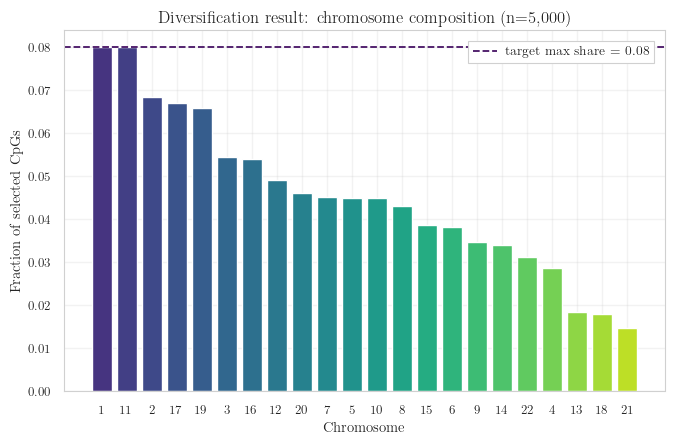

In [22]:
# =============================
# STEP 5 — PLOT: Chromosome share (Viridis + vertical labels)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
chrs = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
chrs = chrs[chrs != ""]

# counts and fractions
uniq, cnt = np.unique(chrs, return_counts=True)
frac = cnt / cnt.sum()

# sort descending
ordr = np.argsort(-frac)
uniq, cnt, frac = uniq[ordr], cnt[ordr], frac[ordr]

# --- Viridis colors ---
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.90, len(uniq)))

fig, ax = plt.subplots()
ax.bar(np.arange(len(uniq)), frac, color=colors)

ax.axhline(CHR_MAX_FRAC,
           linestyle="--",
           linewidth=1.3,
           color=cmap(0.05),
           label=rf"target max share = {CHR_MAX_FRAC:.2f}")

ax.set_xticks(np.arange(len(uniq)))
ax.set_xticklabels(uniq, rotation=0, ha="center")

ax.set_ylabel("Fraction of selected CpGs")
ax.set_xlabel("Chromosome")
ax.set_title(f"Diversification result: chromosome composition (n={len(sel):,})")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE PDF
# -----------------------------
OUT_DIR = Path("figures/step5")
OUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_tag = DATASET_NAME if "DATASET_NAME" in globals() else "dataset"

pdf_path = OUT_DIR / f"{dataset_tag}_chromosome_share_diversified_K{K_TARGET}_maxfrac{CHR_MAX_FRAC:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(f"[OK] Saved PDF → {pdf_path}")

plt.show()


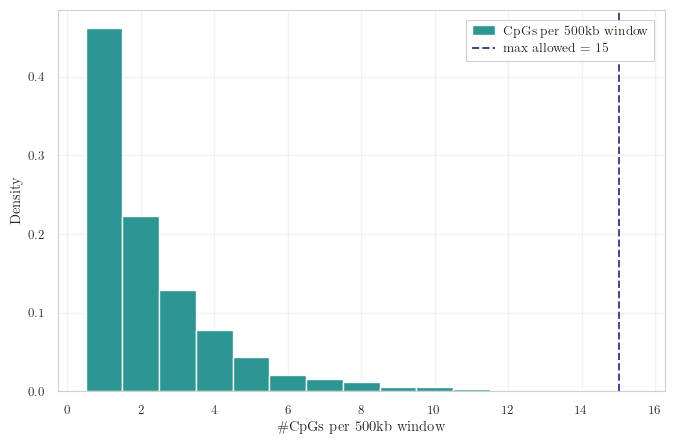

[Spatial density] windows=2134 | max_in_window=15 | violations(cnt>MAX_PER_WIN)=0
Saved as: SpatialDensityConstraint_GSE287331.pdf


In [23]:
# =============================
# STEP 5 — Spatial density constraint check
# Save as: SpatialDensityConstraint_<DATASET_NAME>.pdf
# =============================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import cm

DATASET_NAME = "GSE287331"

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)

pairs = []
for c in sel:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if (ch == "") or (ps is None):
        continue
    win = int(int(ps) // int(WIN_BP))
    pairs.append((str(ch), win))

if len(pairs) == 0:
    raise RuntimeError("No mapped CpGs for spatial window check.")

cnt = np.array(list(Counter(pairs).values()), dtype=int)

color_main = cm.viridis(0.5)
color_line = cm.viridis(0.2)

fig, ax = plt.subplots()

bins = np.arange(1, cnt.max() + 2) - 0.5
ax.hist(cnt,
        bins=bins,
        density=True,
        alpha=0.95,
        color=color_main,
        label=f"CpGs per {WIN_BP//1000}kb window")

ax.axvline(int(MAX_PER_WIN),
           linestyle="--",
           linewidth=1.4,
           color=color_line,
           label=rf"max allowed = {int(MAX_PER_WIN)}")

ax.set_xlabel(f"\#CpGs per {WIN_BP//1000}kb window")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# ---- SAVE ----
plot_name = "SpatialDensityConstraint"
fname = f"{plot_name}_{DATASET_NAME}.pdf"
fig.savefig(fname, bbox_inches="tight")

plt.show()

print(f"[Spatial density] windows={cnt.size} | max_in_window={cnt.max()} | violations(cnt>MAX_PER_WIN)={int(np.sum(cnt > MAX_PER_WIN))}")
print(f"Saved as: {fname}")


In [24]:
# -----------------------------
# STEP 6 — Final K selection
#   K = 5000 (take first K from STEP 5 output order)
# -----------------------------

K_FINAL = 5000

# Assumes from STEP 5:
#   selected_diverse : CpG list in chosen greedy order (best-first under constraints)
final_cpgs = np.array(selected_diverse, dtype=object)[:min(K_FINAL, len(selected_diverse))]

print("\n" + "=" * 90)
print(f"STEP 6 — Final CpG set: K={K_FINAL} (got {final_cpgs.size:,})")
print("=" * 90)

# Outputs for downstream modeling:
#   final_cpgs



STEP 6 — Final CpG set: K=5000 (got 5,000)


In [25]:
# =============================
# EXPORT — final 5000 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path
from datetime import datetime

# Assumes:
#   final_cpgs : np.ndarray (K=5000) from STEP 6

RUN_TAG = "gse287331_fs_v1"   # cambia come vuoi
OUTDIR = Path("./fs_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

final_cpgs = np.array(final_cpgs, dtype=object)

# basic checks
if final_cpgs.size == 0:
    raise RuntimeError("final_cpgs is empty. Check STEP 6.")
if len(np.unique(final_cpgs)) != final_cpgs.size:
    raise RuntimeError("final_cpgs contains duplicates.")

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# TXT (one per line)
txt_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.txt"
with open(txt_path, "w") as f:
    for c in final_cpgs:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.csv"
pl.DataFrame({"CpG_ID": final_cpgs}).write_csv(csv_path)

print("Saved CpGs TXT:", txt_path)
print("Saved CpGs CSV:", csv_path)
print("K =", final_cpgs.size)
print("Example:", final_cpgs[:5].tolist())


Saved CpGs TXT: fs_outputs/final_cpgs_K5000_gse287331_fs_v1_20260221_132711.txt
Saved CpGs CSV: fs_outputs/final_cpgs_K5000_gse287331_fs_v1_20260221_132711.csv
K = 5000
Example: ['cg14455366', 'cg03727227', 'cg08275306', 'cg06551493', 'cg13393204']


In [26]:
# =============================
# SVM CHECK — train/test on final FS CpGs + ROC plot (thesis style)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

print("\n" + "=" * 90)
print("SVM CHECK — final FS CpGs | train/test (no leakage) + ROC")
print("=" * 90)

# -----------------------------
# REQUIRED INPUTS (must exist)
# -----------------------------
#   M_train, M_test               : post-Edgar + beta->M + (optional) variance filter
#   y_train, y_test
#   cpg_cols_current              : columns aligned to M_train/M_test
#   final_cpgs                    : final selected CpGs (e.g., K=5000) from your FS pipeline
#   SVM_C, SVM_MAX_ITER, RANDOM_STATE
#   apply_thesis_style, place_legend
#
# Optional:
#   DATASET_NAME (string) e.g. "GSE225845" for saving plots

DATASET_NAME = globals().get("DATASET_NAME", "GSE287331")  # set explicitly if you want
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Default hyperparameters (if not already defined)
# -----------------------------
SVM_C = globals().get("SVM_C", 1.0)
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 5000)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

print(f"SVM_C = {SVM_C}")
print(f"SVM_MAX_ITER = {SVM_MAX_ITER}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

SVM_C = 0.5   # più regolarizzazione → meno overfitting
SVM_MAX_ITER = 10000
RANDOM_STATE = 42


# -----------------------------
# 1) Build matrices on final CpGs (aligned with current M space)
# -----------------------------
if "M_train" not in globals() or "M_test" not in globals():
    raise NameError("Missing M_train/M_test. Use the matrices produced by STEP 2 (post-Edgar + M-transform).")

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

final_cpgs = np.array(final_cpgs, dtype=object)
jj = np.array([col_to_j[c] for c in final_cpgs if c in col_to_j], dtype=int)

if jj.size == 0:
    raise RuntimeError("No final_cpgs found in cpg_cols_current. Check alignment / filtering masks.")

if jj.size != final_cpgs.size:
    missing = [c for c in final_cpgs.tolist() if c not in col_to_j]
    print(f"WARNING: {len(missing)} CpGs missing from current columns. Using {jj.size}/{final_cpgs.size}.")
    final_cpgs = np.array([c for c in final_cpgs.tolist() if c in col_to_j], dtype=object)

X_train = M_train[:, jj].astype(np.float32, copy=False)
X_test  = M_test[:,  jj].astype(np.float32, copy=False)

print(f"Shapes: X_train={X_train.shape} | X_test={X_test.shape}")
print(f"n_features (final) = {X_train.shape[1]:,}")

# -----------------------------
# 2) Linear SVM on M
# -----------------------------
svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", LinearSVC(C=SVM_C, class_weight="unbalanced", max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE)),
])

svm.fit(X_train, y_train)

score = svm.decision_function(X_test)
pred  = svm.predict(X_test)

auc  = roc_auc_score(y_test, score)
bacc = balanced_accuracy_score(y_test, pred)
cm   = confusion_matrix(y_test, pred, labels=[0, 1])

precision = precision_score(y_test, pred, zero_division=0)
recall    = recall_score(y_test, pred, zero_division=0)
f1        = f1_score(y_test, pred, zero_division=0)
pr_auc    = average_precision_score(y_test, score)
mcc       = matthews_corrcoef(y_test, pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp + 1e-12)

print("\nMETRICS (test):")
print(f"AUC         = {auc:.4f}")
print(f"BAcc        = {bacc:.4f}")
print(f"Precision   = {precision:.4f}")
print(f"Recall      = {recall:.4f}")
print(f"F1-score    = {f1:.4f}")
print(f"PR-AUC      = {pr_auc:.4f}")
print(f"Specificity = {specificity:.4f}")
print(f"MCC         = {mcc:.4f}")

print("\nConfusion matrix [labels 0,1]:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, pred, digits=4, zero_division=0))

# -----------------------------
# 3) ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

# no plot title (print to screen instead)
print(f"\nROC — Linear SVM on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_svmcheck_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# Outputs you may reuse later:
#   svm, fig_roc, score, pred, (auc, bacc, precision, recall, f1, pr_auc, specificity, mcc), cm



SVM CHECK — final FS CpGs | train/test (no leakage) + ROC
SVM_C = 1.0
SVM_MAX_ITER = 5000
RANDOM_STATE = 42
Shapes: X_train=(193, 5000) | X_test=(49, 5000)
n_features (final) = 5,000


InvalidParameterError: The 'class_weight' parameter of LinearSVC must be None, an instance of 'dict' or a str among {'balanced'}. Got 'unbalanced' instead.


FIG — PCA boundary with calibrated probability (train-only fit)

Dataset: GSE287331
SVM_C=0.5 | SVM_MAX_ITER=10000 | RANDOM_STATE=42
Saved plot to: plots_outputs/GSE287331_boundary_pca_prob_calibrated.pdf


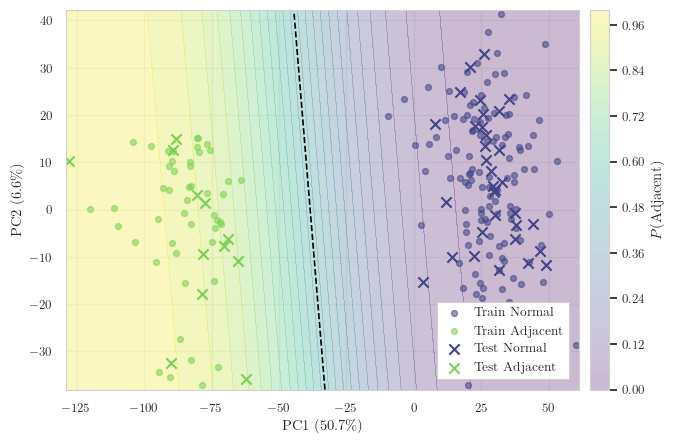

NameError: name 'auc' is not defined

In [27]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV

# -----------------------------
# CHECK REQUIRED MATRICES
# -----------------------------
if "X_train" not in globals() or "X_test" not in globals():
    raise RuntimeError("X_train / X_test not found. Run the SVM CHECK cell first.")

# -----------------------------
# CONFIG
# -----------------------------
DATASET_NAME = "GSE287331"
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

SVM_C = 0.5
SVM_MAX_ITER = 10000
RANDOM_STATE = 42

print("\nFIG — PCA boundary with calibrated probability (train-only fit)\n")
print(f"Dataset: {DATASET_NAME}")
print(f"SVM_C={SVM_C} | SVM_MAX_ITER={SVM_MAX_ITER} | RANDOM_STATE={RANDOM_STATE}")

# -----------------------------
# 1) Fit Linear SVM (train-only)
# -----------------------------
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        max_iter=SVM_MAX_ITER,
        random_state=RANDOM_STATE
    )),
])

svm_pipe.fit(X_train, y_train)

# -----------------------------
# 2) Calibrate (train-only)
# -----------------------------
cal = CalibratedClassifierCV(estimator=svm_pipe, method="sigmoid", cv=3)
cal.fit(X_train, y_train)

# -----------------------------
# 3) PCA (fit ONLY on train)
# -----------------------------
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_train)
Xte_std = pca_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Ztr = pca.fit_transform(Xtr_std)
Zte = pca.transform(Xte_std)

ve = pca.explained_variance_ratio_

# -----------------------------
# 4) Grid in PCA space
# -----------------------------
Z_all = np.vstack([Ztr, Zte])
x_min, x_max = Z_all[:,0].min()-1, Z_all[:,0].max()+1
y_min, y_max = Z_all[:,1].min()-1, Z_all[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 240),
    np.linspace(y_min, y_max, 240)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_std = pca.inverse_transform(grid_pca)
grid_orig = pca_scaler.inverse_transform(grid_std)

zz = cal.predict_proba(grid_orig)[:,1].reshape(xx.shape)

# -----------------------------
# 5) Plot
# -----------------------------
apply_thesis_style(use_tex=True, legend_position="lower right")

fig, ax = plt.subplots(figsize=(6.8, 4.5))

cf = ax.contourf(xx, yy, zz, levels=25, cmap="viridis", alpha=0.28)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linestyles="--", linewidths=1.2)

c0 = plt.cm.viridis(0.20)
c1 = plt.cm.viridis(0.80)

ax.scatter(Ztr[y_train==0,0], Ztr[y_train==0,1],
           s=18, alpha=0.55, c=[c0], label="Train Normal")

ax.scatter(Ztr[y_train==1,0], Ztr[y_train==1,1],
           s=18, alpha=0.55, c=[c1], label="Train Adjacent")

ax.scatter(Zte[y_test==0,0], Zte[y_test==0,1],
           s=55, marker="x", c=[c0], label="Test Normal")

ax.scatter(Zte[y_test==1,0], Zte[y_test==1,1],
           s=55, marker="x", c=[c1], label="Test Adjacent")

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE
# -----------------------------
pdf_path = OUTDIR / f"{DATASET_NAME}_boundary_pca_prob_calibrated.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"SVM boundary in PCA space | AUC={auc:.3f}")


In [28]:
# ============================================================
# CROSS-DATASET EVAL — INTERSECTION on the ACTUAL 5k columns of X_train (NO leakage)
# ============================================================

import polars as pl
import numpy as np
from pathlib import Path
from datetime import datetime
import json

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef
)

# -----------------------------
# CONFIG
# -----------------------------
EXTERNAL_DATASETS = {
    "GSE69914":  "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet",
    "GSE225845": "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
}

OUTDIR = Path("./cross_eval_from5k_intersection")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# REQUIRED IN MEMORY
# -----------------------------
# X_train, X_test, y_train, y_test
# EPS_M, SVM_C, SVM_MAX_ITER, RANDOM_STATE
# LABEL_COL, LABELS_USE
#
# And ONE of these must exist and match X_train columns (len == X_train.shape[1]):
#   cpg_cols_Xtrain OR final_cpgs OR cpg_cols_final OR cpg_cols_train_5k OR selected_5000_cpgs_in_order

def beta_to_m(beta_arr, eps):
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def compute_metrics(y, proba, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        "roc_auc": float(roc_auc_score(y, proba)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y, pred)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# -----------------------------
# Pick the correct CpG list for X_train columns
# -----------------------------
X_train = np.asarray(X_train, float)
X_test  = np.asarray(X_test, float)
y_train = np.asarray(y_train).ravel().astype(int)
y_test  = np.asarray(y_test).ravel().astype(int)

candidates = [
    "cpg_cols_Xtrain",
    "final_cpgs",
    "cpg_cols_final",
    "cpg_cols_train_5k",
    "selected_5000_cpgs_in_order",
    "selected_5000_cpgs",  # last resort
]

cpg_cols_5k = None
for name in candidates:
    if name in globals():
        tmp = list(globals()[name])
        if len(tmp) == X_train.shape[1]:
            cpg_cols_5k = tmp
            print(f"[OK] Using CpG column list: {name} (len={len(tmp)})")
            break

if cpg_cols_5k is None:
    raise NameError(
        "Non trovo la lista CpG che corrisponde alle colonne di X_train.\n"
        "Serve una lista di lunghezza X_train.shape[1] (cioè 5000) con i nomi CpG nell'ordine delle colonne.\n"
        "Esempi nomi attesi: final_cpgs / cpg_cols_final / cpg_cols_Xtrain / selected_5000_cpgs_in_order."
    )

cpg_to_idx_5k = {c: i for i, c in enumerate(cpg_cols_5k)}

print(f"[INFO] X_train shape={X_train.shape} | X_test shape={X_test.shape}")

# ============================================================
# LOOP
# ============================================================
for dname, path in EXTERNAL_DATASETS.items():
    print("\n" + "="*70)
    print("External:", dname)
    print("="*70)

    beta_ext = (
        pl.read_parquet(path)
        .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
        .with_columns(pl.col(LABEL_COL).cast(pl.Int64))
    )
    ext_cols = set(beta_ext.columns)

    # Intersection: (5k actually used in X_train) ∩ (external)
    common_cpgs = [c for c in cpg_cols_5k if c in ext_cols]
    print("CpGs after intersection:", len(common_cpgs))

    if len(common_cpgs) < 20:
        print("Too few common CpGs. Skipping.")
        continue

    idx_common = np.array([cpg_to_idx_5k[c] for c in common_cpgs], dtype=int)

    # Slice current 5k matrices (safe indices)
    Xtr = X_train[:, idx_common].astype(np.float32)
    Xte = X_test[:,  idx_common].astype(np.float32)

    # External β -> M
    Bex = beta_ext.select(common_cpgs).to_numpy().astype(np.float32)
    yex = beta_ext.select(LABEL_COL).to_numpy().ravel().astype(int)
    Xex = beta_to_m(Bex, EPS_M).astype(np.float32)

    print("Shapes: train", Xtr.shape, "| test", Xte.shape, "| ext", Xex.shape)

    # Refit SVM (NO leakage)
    base_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(
            C=SVM_C,
            class_weight="balanced",
            max_iter=SVM_MAX_ITER,
            random_state=RANDOM_STATE
        ))
    ])
    clf = CalibratedClassifierCV(base_pipe, method="sigmoid", cv=3)
    clf.fit(Xtr, y_train)

    # INTERNAL
    proba_te = clf.predict_proba(Xte)[:, 1]
    pred_te  = clf.predict(Xte)
    m_int = compute_metrics(y_test, proba_te, pred_te)

    # EXTERNAL
    proba_ex = clf.predict_proba(Xex)[:, 1]
    pred_ex  = clf.predict(Xex)
    m_ext = compute_metrics(yex, proba_ex, pred_ex)

    print("\nINTERNAL TEST:")
    print({k: round(v, 4) for k, v in m_int.items() if k not in ["tn","fp","fn","tp"]})

    print("\nEXTERNAL TEST:", dname)
    print({k: round(v, 4) for k, v in m_ext.items() if k not in ["tn","fp","fn","tp"]})

    # Save JSON
    run_tag = f"cross_from5k_{dname}_n{len(common_cpgs)}"
    payload = {
        "run_tag": run_tag,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "train_dataset": "CURRENT_TRAIN",
        "external_dataset": dname,
        "n_common_cpgs": int(len(common_cpgs)),
        "internal_metrics": m_int,
        "external_metrics": m_ext,
    }
    with open(OUTDIR / f"{run_tag}.json", "w") as f:
        json.dump(payload, f, indent=2)

    print("Saved:", OUTDIR / f"{run_tag}.json")

print("\nDONE.")


[OK] Using CpG column list: final_cpgs (len=5000)
[INFO] X_train shape=(193, 5000) | X_test shape=(49, 5000)

External: GSE69914
CpGs after intersection: 2443
Shapes: train (193, 2443) | test (49, 2443) | ext (92, 2443)

INTERNAL TEST:
{'roc_auc': 1.0, 'balanced_accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mcc': 1.0}

EXTERNAL TEST: GSE69914
{'roc_auc': 0.4357, 'balanced_accuracy': 0.4719, 'precision': 0.2, 'recall': 0.0238, 'f1': 0.0426, 'mcc': -0.1235}
Saved: cross_eval_from5k_intersection/cross_from5k_GSE69914_n2443.json

External: GSE225845
CpGs after intersection: 4985
Shapes: train (193, 4985) | test (49, 4985) | ext (253, 4985)

INTERNAL TEST:
{'roc_auc': 1.0, 'balanced_accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mcc': 1.0}

EXTERNAL TEST: GSE225845
{'roc_auc': 0.4183, 'balanced_accuracy': 0.5, 'precision': 0.5534, 'recall': 1.0, 'f1': 0.7125, 'mcc': 0.0}
Saved: cross_eval_from5k_intersection/cross_from5k_GSE225845_n4985.json

DONE.


In [29]:
print("working")

working


In [30]:
# ============================================================
# CpG KNAPSACK — cella unica autocontenuta
# Dipendenze dal notebook (devono esistere nello scope):
#   - cpg_candidates      : np.ndarray (n_cand,)  — output STEP3
#   - step3_stats         : dict con chiavi "score", "abs_deltaM_full"
#   - M_train             : np.ndarray (n_train, p)
#   - cpg_cols_current    : np.ndarray (p,)       — colonne di M_train
#   - poolA_cpgs          : list/array             — output STEP3b
#   - poolB_cpgs          : list/array o None      — output STEP3b
#   - cpg_to_chr          : dict CpG -> str        — output STEP5
#   - coef                : np.ndarray (p,)        — coef LinearSVC (opzionale)
# ============================================================

import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ──────────────────────────────────────────────
# CONFIG — modifica qui
# ──────────────────────────────────────────────
N_POOL      = 2000    # top-N CpG per RSKF score da passare al solver
K           = 50     # CpG da selezionare
K_A_min     = 35     # minimo da Pool A (island-anchored)
K_B_max     = 15     # massimo da Pool B
CHR_MAX     = 8      # max CpG per cromosoma
CORR_THR    = 0.85   # soglia correlazione per conflict edges
ALPHA       = 0.5    # peso |ΔM| nella funzione valore
BETA        = 0.5    # peso RSKF score nella funzione valore (alpha+beta=1)
TIME_LIMIT  = 120    # secondi per CBC
RANDOM_STATE = 42

# ──────────────────────────────────────────────
# 0. Allineamento input
# ──────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates,                 dtype=object)
cand_score = np.array(step3_stats["score"],           dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)

assert cand_arr.shape == cand_score.shape == cand_absdM.shape, \
    "cpg_candidates e step3_stats non allineati"

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}

print(f"Candidati STEP3 : {cand_arr.size:,}")
print(f"Colonne M_train : {cols_all.size:,}")

# ──────────────────────────────────────────────
# 1. Pool per il knapsack (top-N per RSKF score)
# ──────────────────────────────────────────────
order_score      = np.argsort(cand_score)
pool_cpgs        = cand_arr[order_score[:N_POOL]]
rskf_score_pool  = cand_score[order_score[:N_POOL]]
abs_dM_pool      = cand_absdM[order_score[:N_POOL]]

print(f"\nPool knapsack   : {len(pool_cpgs)} CpGs")
print(f"score range     : [{rskf_score_pool.min():.4f}, {rskf_score_pool.max():.4f}]")
print(f"|ΔM|  range     : [{abs_dM_pool.min():.4f}, {abs_dM_pool.max():.4f}]")

# ──────────────────────────────────────────────
# 2. Coeff SVM allineati (solo tiebreaker 1%)
# ──────────────────────────────────────────────
if "coef" in globals() and coef is not None:
    _coef        = np.asarray(coef, dtype=float).ravel()
    col_to_coef  = dict(zip(cols_all.tolist(), _coef.tolist()))
    coef_pool    = np.array([col_to_coef.get(c, 0.0) for c in pool_cpgs], dtype=float)
    print(f"coef range      : [{coef_pool.min():.4f}, {coef_pool.max():.4f}]")
else:
    print("coef SVM non trovato — uso ones.")
    coef_pool = np.ones(len(pool_cpgs), dtype=float)

# ──────────────────────────────────────────────
# 3. Pool A / B nel pool knapsack
# ──────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist())
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]
poolB_in_pool = [c for c in pool_cpgs if c in _poolB_set]
K_A_min_use   = min(K_A_min, len(poolA_in_pool))
K_B_max_use   = K_B_max

print(f"\nPool A nel pool : {len(poolA_in_pool)}  (K_A_min usato: {K_A_min_use})")
print(f"Pool B nel pool : {len(poolB_in_pool)}  (K_B_max usato: {K_B_max_use})")
if K_A_min_use < K_A_min:
    print(f"  ⚠ K_A_min ridotto da {K_A_min} -> {K_A_min_use}. Aumenta N_POOL se vuoi più CpG island.")

# ──────────────────────────────────────────────
# 4. Conflict edges da correlazione su M_train
# ──────────────────────────────────────────────
_valid  = [c for c in pool_cpgs if c in col_to_j]
_jj     = np.array([col_to_j[c] for c in _valid], dtype=int)
_pv     = np.array(_valid, dtype=object)

if len(_valid) < len(pool_cpgs):
    print(f"  ⚠ {len(pool_cpgs)-len(_valid)} CpG non in M_train, rimosse dal pool.")
    # riallinea tutto
    _mask        = np.array([c in set(_valid) for c in pool_cpgs])
    pool_cpgs    = _pv
    rskf_score_pool = rskf_score_pool[_mask]
    abs_dM_pool     = abs_dM_pool[_mask]
    coef_pool       = coef_pool[_mask]
    poolA_in_pool   = [c for c in pool_cpgs if c in _poolA_set]
    poolB_in_pool   = [c for c in pool_cpgs if c in _poolB_set]

Z  = M_train[:, _jj].astype(np.float64)
Z  = (Z - Z.mean(axis=0)) / (Z.std(axis=0, ddof=1) + 1e-12)
C  = (Z.T @ Z) / (Z.shape[0] - 1)
_i, _j = np.where(np.triu(np.abs(C) >= CORR_THR, k=1))
conflict_edges = [(_pv[i], _pv[j]) for i, j in zip(_i, _j)]

_nposs = len(_pv) * (len(_pv) - 1) // 2
print(f"\nConflict edges  : {len(conflict_edges):,} / {_nposs:,} ({100*len(conflict_edges)/_nposs:.1f}%) a |r|>={CORR_THR}")
if len(conflict_edges) > 50_000:
    print("  ⚠ Molti edges — considera N_POOL=300 se il solver è lento.")

# ──────────────────────────────────────────────
# 5. Funzione valore (rank-based)
# ──────────────────────────────────────────────
n_p         = len(pool_cpgs)
rank_dM     = np.argsort(np.argsort(abs_dM_pool))    / (n_p - 1)
rank_score  = 1.0 - np.argsort(np.argsort(rskf_score_pool)) / (n_p - 1)
_ac         = np.abs(coef_pool)
_ac_norm    = (_ac - _ac.min()) / (_ac.max() - _ac.min() + 1e-12)
value       = ALPHA * rank_dM + BETA * rank_score + 0.01 * _ac_norm

print(f"\nValore CpG      : min={value.min():.4f}  max={value.max():.4f}")

# ──────────────────────────────────────────────
# 6. Setup solver (arrays condivisi)
# ──────────────────────────────────────────────
chr_arr  = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
idx_of   = {c: i for i, c in enumerate(pool_cpgs.tolist())}

conflict_pairs = []
for a, b in conflict_edges:
    if a in idx_of and b in idx_of:
        ia, ib = idx_of[a], idx_of[b]
        if ia != ib:
            conflict_pairs.append((ia, ib))

# ──────────────────────────────────────────────
# 6a. MILP (PuLP + CBC)
# ──────────────────────────────────────────────
def _run_milp():
    import pulp
    prob = pulp.LpProblem("CpG_Knapsack", pulp.LpMaximize)
    x    = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]

    prob += pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))

    prob += pulp.lpSum(x) == K                                             # C1

    A_idx = [i for i, c in enumerate(pool_cpgs.tolist()) if c in _poolA_set]
    if A_idx:
        prob += pulp.lpSum(x[i] for i in A_idx) >= K_A_min_use            # C2

    if _poolB_set:
        B_idx = [i for i, c in enumerate(pool_cpgs.tolist()) if c in _poolB_set]
        if B_idx:
            prob += pulp.lpSum(x[i] for i in B_idx) <= K_B_max_use        # C3

    for ch in np.unique(chr_arr):                                          # C4
        if ch == "": continue
        idx_ch = np.where(chr_arr == ch)[0].tolist()
        prob   += pulp.lpSum(x[i] for i in idx_ch) <= CHR_MAX

    for ia, ib in conflict_pairs:                                          # C5
        prob += x[ia] + x[ib] <= 1

    status     = prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=TIME_LIMIT))
    status_str = pulp.LpStatus.get(status, str(status))

    if pulp.value(prob.objective) is not None:
        x_val   = np.array([pulp.value(v) for v in x], dtype=float)
        sel_idx = np.where(x_val > 0.5)[0]
        if len(sel_idx) == K:
            return pool_cpgs[sel_idx].tolist(), sel_idx, status_str
    return None, None, status_str

# ──────────────────────────────────────────────
# 6b. Greedy fallback
# ──────────────────────────────────────────────
def _run_greedy():
    order    = np.argsort(-value)
    selected, selset = [], set()
    cnt_A = cnt_B = 0
    chr_cnt = {}

    cadj = [set() for _ in range(n_p)]
    for ia, ib in conflict_pairs:
        cadj[ia].add(ib); cadj[ib].add(ia)

    def bad(i):
        ch = chr_arr[i]
        if ch != "" and chr_cnt.get(ch, 0) >= CHR_MAX: return True
        if pool_cpgs[i] in _poolB_set and cnt_B >= K_B_max_use: return True
        return any(j in selset for j in cadj[i])

    def add(i):
        nonlocal cnt_A, cnt_B
        selected.append(i); selset.add(i)
        if pool_cpgs[i] in _poolA_set: cnt_A += 1
        if pool_cpgs[i] in _poolB_set: cnt_B += 1
        ch = chr_arr[i]
        if ch != "": chr_cnt[ch] = chr_cnt.get(ch, 0) + 1

    def take(pred, n):
        done = 0
        for i in order:
            if len(selected) >= K or done >= n: break
            if i not in selset and not bad(i) and pred(i):
                add(i); done += 1

    take(lambda i: pool_cpgs[i] in _poolA_set, max(0, K_A_min_use - cnt_A))
    if cnt_A < K_A_min_use:
        raise RuntimeError(f"Greedy: Pool A insufficiente ({cnt_A}<{K_A_min_use}). Aumenta N_POOL.")
    take(lambda i: True, K - len(selected))
    if len(selected) != K:
        raise RuntimeError(f"Greedy: selezionato {len(selected)}/{K}. Rilassa CHR_MAX o CORR_THR.")

    sel_idx = np.array(selected, dtype=int)
    return pool_cpgs[sel_idx].tolist(), sel_idx, "GREEDY"

# ──────────────────────────────────────────────
# 6c. Esecuzione
# ──────────────────────────────────────────────
print("\n[SOLVER] Avvio...")
try:
    import pulp
    selected_cpgs, sel_idx, status_str = _run_milp()
    if selected_cpgs is None:
        print(f"[MILP] Status={status_str} — fallback greedy.")
        selected_cpgs, sel_idx, status_str = _run_greedy()
    else:
        print(f"[MILP] Status={status_str} ✓")
except Exception as e:
    print(f"[MILP] Non disponibile ({e}) — greedy.")
    selected_cpgs, sel_idx, status_str = _run_greedy()

# ──────────────────────────────────────────────
# 7. Diagnostica selezione
# ──────────────────────────────────────────────
_cnt_A = sum(1 for c in selected_cpgs if c in _poolA_set)
_cnt_B = sum(1 for c in selected_cpgs if c in _poolB_set)
_chrs, _cnts = np.unique(chr_arr[sel_idx], return_counts=True)
_chr_str = "  ".join(f"chr{c}:{n}" for c, n in zip(_chrs, _cnts) if c != "")

print(f"\n{'='*60}")
print(f"  Metodo      : {status_str}")
print(f"  Selezionate : {len(selected_cpgs)} / K={K}")
print(f"  Pool A      : {_cnt_A}  (min: {K_A_min_use})")
print(f"  Pool B      : {_cnt_B}  (max: {K_B_max_use})")
print(f"  Obiettivo   : {float(np.sum(value[sel_idx])):.6f}")
print(f"  mean|ΔM|    : {abs_dM_pool[sel_idx].mean():.4f}")
print(f"  Cromosomi   : {_chr_str}")
print(f"{'='*60}")

# ──────────────────────────────────────────────
# 8. Valutazione separazione norm-adj e norm-tum
# ──────────────────────────────────────────────
# Richiede M_all e y_all che includono anche label=2 (tumor)
# Se non li hai, questo blocco stampa un avviso e si ferma.

EVAL_PAIRS  = [(0, 1), (0, 2)]
LABEL_NAMES = {0: "Normal", 1: "Adjacent", 2: "Tumor"}

if "M_all" not in globals() or "y_all" not in globals():
    print("\n[EVAL] M_all / y_all non trovati — skip.")
    print("       Carica i dati completi (inclusi tumor) e riesegui.")
else:
    M_eval = np.array(M_all)
    y_eval = np.array(y_all)

    jj_eval = np.array([col_to_j[c] for c in selected_cpgs if c in col_to_j], dtype=int)
    if jj_eval.size < len(selected_cpgs):
        print(f"[EVAL] ⚠ {len(selected_cpgs)-jj_eval.size} CpG non in cpg_cols_current.")
    X_sel = M_eval[:, jj_eval]

    eval_results = {}
    for (la, lb) in EVAL_PAIRS:
        lname = f"{LABEL_NAMES.get(la,la)}_vs_{LABEL_NAMES.get(lb,lb)}"
        mask  = np.isin(y_eval, [la, lb])
        X_p   = X_sel[mask]
        y_p   = (y_eval[mask] == lb).astype(int)

        if X_p.shape[0] < 10 or y_p.sum() == 0 or (y_p == 0).sum() == 0:
            print(f"[EVAL] {lname}: campioni insufficienti, skip.")
            continue

        out = {"n": int(X_p.shape[0]), "k": int(jj_eval.size)}

        try:
            out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
        except Exception as e:
            out["silhouette"] = None

        try:
            X_sc = StandardScaler().fit_transform(X_p)
            lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                      max_iter=1000, random_state=RANDOM_STATE)
            aucs = cross_val_score(lr, X_sc, y_p, cv=5, scoring="roc_auc")
            out["auc_mean"] = float(aucs.mean())
            out["auc_std"]  = float(aucs.std())
        except Exception as e:
            out["auc_mean"] = out["auc_std"] = None

        m0 = X_p[y_p == 0].mean(axis=0)
        m1 = X_p[y_p == 1].mean(axis=0)
        out["mean_abs_dM"]   = float(np.abs(m1 - m0).mean())
        out["median_abs_dM"] = float(np.median(np.abs(m1 - m0)))

        try:
            pca = PCA(n_components=2, random_state=RANDOM_STATE)
            pca.fit(StandardScaler().fit_transform(X_p))
            out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
            out["pca_pc2"] = float(pca.explained_variance_ratio_[1])
        except Exception:
            out["pca_pc1"] = out["pca_pc2"] = None

        eval_results[lname] = out

        sil = f"{out['silhouette']:.4f}" if out["silhouette"] is not None else "N/A"
        auc = f"{out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out["auc_mean"] is not None else "N/A"
        pc1 = f"{out['pca_pc1']:.3f}" if out["pca_pc1"] is not None else "N/A"
        print(f"\n[EVAL] {lname}  (n={out['n']}, k={out['k']})")
        print(f"  Silhouette  : {sil}   (>0.5 buona separazione)")
        print(f"  AUC CV5     : {auc}")
        print(f"  mean |ΔM|   : {out['mean_abs_dM']:.4f}")
        print(f"  PCA PC1 var : {pc1}")

print("\n[DONE] Variabili disponibili: selected_cpgs, sel_idx, eval_results")

Candidati STEP3 : 15,000
Colonne M_train : 280,280

Pool knapsack   : 2000 CpGs
score range     : [0.0000, 0.1043]
|ΔM|  range     : [0.7955, 10.0558]
coef SVM non trovato — uso ones.

Pool A nel pool : 775  (K_A_min usato: 35)
Pool B nel pool : 1225  (K_B_max usato: 15)

Conflict edges  : 252,032 / 1,999,000 (12.6%) a |r|>=0.85
  ⚠ Molti edges — considera N_POOL=300 se il solver è lento.

Valore CpG      : min=0.0148  max=1.0000

[SOLVER] Avvio...
[MILP] Status=Optimal ✓

  Metodo      : Optimal
  Selezionate : 50 / K=50
  Pool A      : 35  (min: 35)
  Pool B      : 15  (max: 15)
  Obiettivo   : 43.560780
  mean|ΔM|    : 3.0646
  Cromosomi   : chr10:2  chr11:2  chr12:1  chr13:1  chr16:2  chr17:1  chr19:5  chr2:1  chr20:2  chr3:1  chr4:1  chr5:1  chr6:1  chr7:3  chr8:1  chr9:2

[EVAL] M_all / y_all non trovati — skip.
       Carica i dati completi (inclusi tumor) e riesegui.

[DONE] Variabili disponibili: selected_cpgs, sel_idx, eval_results


In [31]:
!pip install pulp
import pulp

In [32]:
# ============================================================
# CpG KNAPSACK POST-SVM — cella unica autocontenuta
#
# Flusso:
#   1. Estrae coef LinearSVC dalle 5000 CpG (final_cpgs)
#   2. Carica M_all / y_all dal parquet (norm+adj+tum)
#   3. Knapsack greedy sulle 5000 -> seleziona K=50
#      con valore = combinazione |coef_SVM| + |ΔM| + RSKF score
#   4. Valuta separazione norm-adj e norm-tum sulle 50 CpG
#
# Dipendenze richieste nello scope:
#   - final_cpgs          : np.ndarray (5000,)   — output STEP6
#   - cpg_cols_current    : np.ndarray (p,)       — colonne di M_train
#   - M_train, M_test     : matrici post STEP2
#   - y_train, y_test
#   - step3_stats         : dict "score", "abs_deltaM_full" allineati a cpg_candidates
#   - cpg_candidates      : np.ndarray (n_cand,)
#   - poolA_cpgs, poolB_cpgs (o None)
#   - cpg_to_chr          : dict CpG -> chr
#   - svm_pipe            : Pipeline già fittato (da cella SVM CHECK)
# ============================================================

import numpy as np
import polars as pl
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]          # 0=norm, 1=adj, 2=tum

K            = 50                  # CpG da selezionare
N_POOL       = 500                 # top-N da final_cpgs per score RSKF
CHR_MAX      = 8                   # max CpG per cromosoma
CORR_THR     = 0.85                # soglia correlazione conflict edges
W_COEF       = 0.50                # peso |coef_SVM| nella funzione valore
W_DM         = 0.30                # peso |ΔM|
W_SCORE      = 0.20                # peso RSKF score (inverso)
K_A_min      = 30                  # min da Pool A (island-anchored)
K_B_max      = 20                  # max da Pool B
RANDOM_STATE = 42

# ──────────────────────────────────────────────
# 1. Estrai coef SVM dalle 5000 CpG (final_cpgs)
# ──────────────────────────────────────────────
# NOTA: il LinearSVC è stato fittato su X_train con 5000 colonne (final_cpgs),
# quindi coef_ ha size 5000 allineato a final_cpgs, NON a cpg_cols_current.

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, \
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. " \
    f"Assicurati che svm_pipe sia stato fittato su X_train[:,final_cpgs]."

# coef_final è già allineato a final_arr (1:1)
coef_final = raw_coef

print(f"final_cpgs       : {final_arr.size}")
print(f"coef range       : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos coef (norm<adj ipermet.) : {(coef_final > 0).sum()}")
print(f"  neg coef (norm>adj ipomet.)  : {(coef_final < 0).sum()}")

# ──────────────────────────────────────────────
# 2. Carica M_all / y_all (norm + adj + tum)
# ──────────────────────────────────────────────
print("\nCaricamento dati completi (label 0,1,2)...")

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)

y_all_pl  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all_pl = beta_all.select(ID_COL).to_numpy().ravel()

# seleziona solo le colonne cpg (esclude metadata)
meta_cols = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols]

# allinea a cpg_cols_current (M_all deve avere stesse colonne di M_train)
# usa solo le CpG presenti in cpg_cols_current
common = [c for c in cpg_cols_parquet if c in col_to_j]
jj_common = np.array([col_to_j[c] for c in common], dtype=int)

M_all_beta = beta_all.select(common).to_numpy().astype(np.float32)

# beta -> M transform (stessa funzione del notebook)
EPS_M = 1e-6
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

M_all = beta_to_m(M_all_beta).astype(np.float32)

# costruisci mapping colonna per M_all
# M_all[:,i] corrisponde a common[i]
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape      : {M_all.shape}")
print(f"y_all distrib    : " + str({int(v): int((y_all_pl == v).sum()) for v in np.unique(y_all_pl)}))

y_all = y_all_pl

# ──────────────────────────────────────────────
# 3. Allinea RSKF score e |ΔM| alle final_cpgs
# ──────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"],           dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

# per le final_cpgs che sono in cpg_candidates
score_final = np.array([cand_score[cand_to_i[c]] if c in cand_to_i else np.nan
                         for c in final_arr], dtype=float)
absdM_final = np.array([cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan
                         for c in final_arr], dtype=float)

n_missing = int(np.isnan(score_final).sum())
if n_missing > 0:
    print(f"⚠ {n_missing} CpG di final_cpgs non trovate in cpg_candidates — score=nan, saranno penalizzate.")

# ──────────────────────────────────────────────
# 4. Costruisci pool knapsack (top-N per |coef_SVM|)
#    Usiamo |coef| come criterio principale di pre-selezione
#    perché siamo nel flusso "post-SVM"
# ──────────────────────────────────────────────
order_coef  = np.argsort(-np.abs(coef_final))   # maggior |coef| prima
pool_idx    = order_coef[:N_POOL]
pool_cpgs   = final_arr[pool_idx]
pool_coef   = coef_final[pool_idx]
pool_score  = score_final[pool_idx]
pool_absdM  = absdM_final[pool_idx]

print(f"\nPool knapsack    : {len(pool_cpgs)} CpGs (top |coef_SVM|)")
print(f"|coef| range     : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ──────────────────────────────────────────────
# 5. Pool A / B nel pool
# ──────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist())
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in = [c for c in pool_cpgs if c in _poolA_set]
poolB_in = [c for c in pool_cpgs if c in _poolB_set]
K_A_use  = min(K_A_min, len(poolA_in))
K_B_use  = K_B_max

print(f"Pool A nel pool  : {len(poolA_in)}  (K_A_min usato: {K_A_use})")
print(f"Pool B nel pool  : {len(poolB_in)}  (K_B_max usato: {K_B_use})")

# ──────────────────────────────────────────────
# 6. Conflict edges (correlazione su M_train)
# ──────────────────────────────────────────────
_valid   = [c for c in pool_cpgs if c in col_to_j]
_jj_pool = np.array([col_to_j[c] for c in _valid], dtype=int)
_pv      = np.array(_valid, dtype=object)

if len(_valid) < len(pool_cpgs):
    _mask      = np.array([c in set(_valid) for c in pool_cpgs])
    pool_cpgs  = _pv
    pool_coef  = pool_coef[_mask]
    pool_score = pool_score[_mask]
    pool_absdM = pool_absdM[_mask]
    poolA_in   = [c for c in pool_cpgs if c in _poolA_set]
    poolB_in   = [c for c in pool_cpgs if c in _poolB_set]

Z  = M_train[:, _jj_pool].astype(np.float64)
Z  = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C  = (Z.T @ Z) / (Z.shape[0] - 1)
_i, _j = np.where(np.triu(np.abs(C) >= CORR_THR, k=1))
conflict_edges = [(_pv[i], _pv[j]) for i, j in zip(_i, _j)]

_np = len(_pv)
print(f"\nConflict edges   : {len(conflict_edges):,} / {_np*(_np-1)//2:,} ({100*len(conflict_edges)/(_np*(_np-1)//2):.1f}%) a |r|>={CORR_THR}")

# ──────────────────────────────────────────────
# 7. Funzione valore (combinazione rank-normalizzata)
# ──────────────────────────────────────────────
n_p = len(pool_cpgs)

def rank_norm_asc(v):
    """rank normalizzato: più alto v -> rank più alto (in [0,1])"""
    v = np.where(np.isnan(v), v.min() - 1, v)   # nan -> penalizzato
    return np.argsort(np.argsort(v)) / (n_p - 1)

def rank_norm_desc(v):
    """rank normalizzato: più basso v -> rank più alto"""
    return 1.0 - rank_norm_asc(v)

r_coef  = rank_norm_asc(np.abs(pool_coef))    # |coef| alto = buono
r_dM    = rank_norm_asc(pool_absdM)            # |ΔM| alto = buono
r_score = rank_norm_desc(pool_score)           # score basso = buono

value = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score
print(f"\nValore CpG       : min={value.min():.4f}  max={value.max():.4f}")

# ──────────────────────────────────────────────
# 8. Greedy knapsack con conflict edges
# ──────────────────────────────────────────────
chr_arr = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
idx_of  = {c: i for i, c in enumerate(pool_cpgs.tolist())}

conflict_pairs = []
for a, b in conflict_edges:
    if a in idx_of and b in idx_of:
        ia, ib = idx_of[a], idx_of[b]
        if ia != ib:
            conflict_pairs.append((ia, ib))

cadj = [set() for _ in range(n_p)]
for ia, ib in conflict_pairs:
    cadj[ia].add(ib); cadj[ib].add(ia)

order    = np.argsort(-value)
selected, selset = [], set()
cnt_A = cnt_B = 0
chr_cnt = {}

def bad(i):
    ch = chr_arr[i]
    if ch != "" and chr_cnt.get(ch, 0) >= CHR_MAX: return True
    if pool_cpgs[i] in _poolB_set and cnt_B >= K_B_use: return True
    return any(j in selset for j in cadj[i])

def add(i):
    global cnt_A, cnt_B
    selected.append(i); selset.add(i)
    if pool_cpgs[i] in _poolA_set: cnt_A += 1
    if pool_cpgs[i] in _poolB_set: cnt_B += 1
    ch = chr_arr[i]
    if ch != "": chr_cnt[ch] = chr_cnt.get(ch, 0) + 1

def take(pred, n):
    done = 0
    for i in order:
        if len(selected) >= K or done >= n: break
        if i not in selset and not bad(i) and pred(i):
            add(i); done += 1

# fase 1: Pool A
take(lambda i: pool_cpgs[i] in _poolA_set, max(0, K_A_use - cnt_A))
if cnt_A < K_A_use:
    print(f"⚠ Pool A: raggiunto solo {cnt_A}/{K_A_use}. Aumenta N_POOL o abbassa K_A_min.")

# fase 2: riempimento libero
take(lambda i: True, K - len(selected))

if len(selected) != K:
    raise RuntimeError(f"Greedy: selezionato {len(selected)}/{K}. Rilassa CHR_MAX o CORR_THR.")

sel_idx       = np.array(selected, dtype=int)
selected_cpgs = pool_cpgs[sel_idx].tolist()

# ──────────────────────────────────────────────
# 9. Diagnostica selezione
# ──────────────────────────────────────────────
_cnt_A = sum(1 for c in selected_cpgs if c in _poolA_set)
_cnt_B = sum(1 for c in selected_cpgs if c in _poolB_set)
_chrs, _cnts = np.unique(chr_arr[sel_idx], return_counts=True)
_chr_str = "  ".join(f"chr{c}:{n}" for c, n in zip(_chrs, _cnts) if c != "")

print(f"\n{'='*60}")
print(f"  Selezionate  : {len(selected_cpgs)} / K={K}")
print(f"  Pool A       : {_cnt_A}  (min: {K_A_use})")
print(f"  Pool B       : {_cnt_B}  (max: {K_B_use})")
print(f"  mean|coef|   : {np.abs(pool_coef[sel_idx]).mean():.4f}")
print(f"  mean|ΔM|     : {pool_absdM[sel_idx].mean():.4f}")
print(f"  Cromosomi    : {_chr_str}")
print(f"{'='*60}")

# ──────────────────────────────────────────────
# 10. Valutazione separazione — SENZA leakage
#
# norm-adj : usa SOLO M_test/y_test (il 20% mai visto dalla FS)
# norm-tum : usa M_all filtrato label==2 + normal di M_test
#            (tumor mai usati in FS, normal dal test set)
# ──────────────────────────────────────────────
LABEL_NAMES = {0: "Normal", 1: "Adjacent", 2: "Tumor"}
RANDOM_STATE = 42

# allinea le 50 CpG a M_test (cpg_cols_current allineato a M_train/M_test)
jj_test = np.array([col_to_j[c] for c in selected_cpgs if c in col_to_j], dtype=int)

# allinea le 50 CpG a M_all (colonne di M_all = common)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs if c in col_to_j_all], dtype=int)

eval_results = {}

# ── CASO 1: norm vs adj su M_test ──
lname = "Normal_vs_Adjacent (test set)"
mask  = np.isin(y_test, [0, 1])
X_p   = M_test[mask][:, jj_test]
y_p   = (y_test[mask] == 1).astype(int)

# Verifica degenerazione CpG (std quasi zero = CpG quasi costante in una classe)
std0 = X_p[y_na == 0].std(0)
std1 = X_p[y_na == 1].std(0)
print(f"CpG con std<0.1 in Normal  : {(std0 < 0.1).sum()}")
print(f"CpG con std<0.1 in Adjacent: {(std1 < 0.1).sum()}")

# soglia più permissiva per capire la distribuzione
for thr in [0.05, 0.10, 0.20]:
    print(f"  std<{thr} | Normal: {(std0<thr).sum()} | Adjacent: {(std1<thr).sum()}")

print(f"\n[EVAL] {lname}  n={X_p.shape[0]} (norm={( y_p==0).sum()}, adj={(y_p==1).sum()})")

if X_p.shape[0] >= 10 and y_p.sum() > 0 and (y_p == 0).sum() > 0:
    out = {}
    try:
        out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
    except:
        out["silhouette"] = None
    try:
        X_sc = StandardScaler().fit_transform(X_p)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=RANDOM_STATE)
        # con pochi campioni usa cv=3 o leave-one-out
        n_cv = min(5, y_p.sum(), (y_p==0).sum())
        aucs = cross_val_score(lr, X_sc, y_p, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC error: {e}")
    m0 = X_p[y_p==0].mean(0); m1 = X_p[y_p==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1-m0).mean())
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X_p))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
    except:
        out["pca_pc1"] = None
    eval_results[lname] = out
    print(f"  Silhouette : {out['silhouette']:.4f}" if out['silhouette'] else "  Silhouette : N/A")
    print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out['auc_mean'] else "  AUC CV : N/A")
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")
    print(f"  PCA PC1    : {out['pca_pc1']:.3f}" if out['pca_pc1'] else "  PCA PC1 : N/A")
else:
    print("  Campioni insufficienti nel test set per questa coppia.")
    print("  Verifica che y_test contenga sia label 0 che label 1.")

# ── CASO 2: norm vs tum (tumor mai visti + normal dal test set) ──
lname = "Normal_vs_Tumor (test norm + all tumor)"
mask_tum  = (y_all == 2)
mask_norm_test = (y_test == 0)

X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_test][:, jj_test]

# verifica allineamento colonne (stesso ordine CpG)
# jj_test e jj_eval puntano alle stesse CpG ma in matrici diverse — ok se selected_cpgs è lo stesso
X_p = np.vstack([X_norm, X_tum])
y_p = np.array([0]*X_norm.shape[0] + [1]*X_tum.shape[0], dtype=int)


# soglia più permissiva per capire la distribuzione
for thr in [0.05, 0.10, 0.20]:
    print(f"  std<{thr} | Normal: {(std0<thr).sum()} | Adjacent: {(std1<thr).sum()}")

print(f"\n[EVAL] {lname}  n={X_p.shape[0]} (norm={X_norm.shape[0]}, tum={X_tum.shape[0]})")

if X_p.shape[0] >= 10 and y_p.sum() > 0:
    out = {}
    try:
        out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
    except:
        out["silhouette"] = None
    try:
        X_sc = StandardScaler().fit_transform(X_p)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=RANDOM_STATE)
        n_cv = min(5, y_p.sum(), (y_p==0).sum())
        aucs = cross_val_score(lr, X_sc, y_p, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC error: {e}")
    m0 = X_p[y_p==0].mean(0); m1 = X_p[y_p==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1-m0).mean())
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X_p))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
    except:
        out["pca_pc1"] = None
    eval_results[lname] = out
    print(f"  Silhouette : {out['silhouette']:.4f}" if out['silhouette'] else "  Silhouette : N/A")
    print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out['auc_mean'] else "  AUC CV : N/A")
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")
    print(f"  PCA PC1    : {out['pca_pc1']:.3f}" if out['pca_pc1'] else "  PCA PC1 : N/A")

print("\n[DONE] eval_results disponibile")
print("\n[DONE] Disponibili: selected_cpgs, sel_idx, eval_results, M_all, y_all")


final_cpgs       : 5000
coef range       : [-0.0039, 0.0032]
  pos coef (norm<adj ipermet.) : 1100
  neg coef (norm>adj ipomet.)  : 3900

Caricamento dati completi (label 0,1,2)...
M_all shape      : (311, 280280)
y_all distrib    : {0: 182, 1: 60, 2: 69}

Pool knapsack    : 500 CpGs (top |coef_SVM|)
|coef| range     : [0.0016, 0.0039]
Pool A nel pool  : 91  (K_A_min usato: 30)
Pool B nel pool  : 409  (K_B_max usato: 20)

Conflict edges   : 2 / 124,750 (0.0%) a |r|>=0.85

Valore CpG       : min=0.0764  max=0.9675

  Selezionate  : 50 / K=50
  Pool A       : 30  (min: 30)
  Pool B       : 20  (max: 20)
  mean|coef|   : 0.0024
  mean|ΔM|     : 2.0135
  Cromosomi    : chr1:4  chr10:2  chr11:5  chr12:3  chr15:5  chr16:4  chr17:2  chr18:1  chr19:4  chr2:3  chr20:2  chr3:2  chr4:2  chr5:4  chr6:3  chr7:1  chr8:2  chr9:1


NameError: name 'y_na' is not defined

In [33]:
# ============================================================
# CpG KNAPSACK POST-SVM — cella unica autocontenuta
#
# Flusso:
#   1. Estrae coef LinearSVC dalle 5000 CpG (final_cpgs)
#   2. Carica M_all / y_all dal parquet (norm+adj+tum)
#   3. Knapsack greedy sulle 5000 -> seleziona K=50
#      con valore = combinazione |coef_SVM| + |ΔM| + RSKF score
#   4. Valuta separazione norm-adj e norm-tum sulle 50 CpG
#
# Dipendenze richieste nello scope:
#   - final_cpgs          : np.ndarray (5000,)   — output STEP6
#   - cpg_cols_current    : np.ndarray (p,)       — colonne di M_train
#   - M_train, M_test     : matrici post STEP2
#   - y_train, y_test
#   - step3_stats         : dict "score", "abs_deltaM_full" allineati a cpg_candidates
#   - cpg_candidates      : np.ndarray (n_cand,)
#   - poolA_cpgs, poolB_cpgs (o None)
#   - cpg_to_chr          : dict CpG -> chr
#   - svm_pipe            : Pipeline già fittato (da cella SVM CHECK)
# ============================================================

import numpy as np
import polars as pl
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]          # 0=norm, 1=adj, 2=tum

K            = 50                  # CpG da selezionare
N_POOL       = 500                 # top-N da final_cpgs per score RSKF
CHR_MAX      = 8                   # max CpG per cromosoma
CORR_THR     = 0.85                # soglia correlazione conflict edges
W_COEF       = 0.50                # peso |coef_SVM| nella funzione valore
W_DM         = 0.30                # peso |ΔM|
W_SCORE      = 0.20                # peso RSKF score (inverso)
K_A_min      = 30                  # min da Pool A (island-anchored)
K_B_max      = 20                  # max da Pool B
RANDOM_STATE = 42

# ──────────────────────────────────────────────
# 1. Estrai coef SVM dalle 5000 CpG (final_cpgs)
# ──────────────────────────────────────────────
# NOTA: il LinearSVC è stato fittato su X_train con 5000 colonne (final_cpgs),
# quindi coef_ ha size 5000 allineato a final_cpgs, NON a cpg_cols_current.

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, \
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. " \
    f"Assicurati che svm_pipe sia stato fittato su X_train[:,final_cpgs]."

# coef_final è già allineato a final_arr (1:1)
coef_final = raw_coef

print(f"final_cpgs       : {final_arr.size}")
print(f"coef range       : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos coef (norm<adj ipermet.) : {(coef_final > 0).sum()}")
print(f"  neg coef (norm>adj ipomet.)  : {(coef_final < 0).sum()}")

# ──────────────────────────────────────────────
# 2. Carica M_all / y_all (norm + adj + tum)
# ──────────────────────────────────────────────
print("\nCaricamento dati completi (label 0,1,2)...")

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)

y_all_pl  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all_pl = beta_all.select(ID_COL).to_numpy().ravel()

# seleziona solo le colonne cpg (esclude metadata)
meta_cols = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols]

# allinea a cpg_cols_current (M_all deve avere stesse colonne di M_train)
# usa solo le CpG presenti in cpg_cols_current
common = [c for c in cpg_cols_parquet if c in col_to_j]
jj_common = np.array([col_to_j[c] for c in common], dtype=int)

M_all_beta = beta_all.select(common).to_numpy().astype(np.float32)

# beta -> M transform (stessa funzione del notebook)
EPS_M = 1e-6
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

M_all = beta_to_m(M_all_beta).astype(np.float32)

# costruisci mapping colonna per M_all
# M_all[:,i] corrisponde a common[i]
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape      : {M_all.shape}")
print(f"y_all distrib    : " + str({int(v): int((y_all_pl == v).sum()) for v in np.unique(y_all_pl)}))

y_all = y_all_pl

# ──────────────────────────────────────────────
# 3. Allinea RSKF score e |ΔM| alle final_cpgs
# ──────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"],           dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

# per le final_cpgs che sono in cpg_candidates
score_final = np.array([cand_score[cand_to_i[c]] if c in cand_to_i else np.nan
                         for c in final_arr], dtype=float)
absdM_final = np.array([cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan
                         for c in final_arr], dtype=float)

n_missing = int(np.isnan(score_final).sum())
if n_missing > 0:
    print(f"⚠ {n_missing} CpG di final_cpgs non trovate in cpg_candidates — score=nan, saranno penalizzate.")

# ──────────────────────────────────────────────
# 4. Costruisci pool knapsack (top-N per |coef_SVM|)
#    Usiamo |coef| come criterio principale di pre-selezione
#    perché siamo nel flusso "post-SVM"
# ──────────────────────────────────────────────
order_coef  = np.argsort(-np.abs(coef_final))   # maggior |coef| prima
pool_idx    = order_coef[:N_POOL]
pool_cpgs   = final_arr[pool_idx]
pool_coef   = coef_final[pool_idx]
pool_score  = score_final[pool_idx]
pool_absdM  = absdM_final[pool_idx]

print(f"\nPool knapsack    : {len(pool_cpgs)} CpGs (top |coef_SVM|)")
print(f"|coef| range     : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ──────────────────────────────────────────────
# 5. Pool A / B nel pool
# ──────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist())
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in = [c for c in pool_cpgs if c in _poolA_set]
poolB_in = [c for c in pool_cpgs if c in _poolB_set]
K_A_use  = min(K_A_min, len(poolA_in))
K_B_use  = K_B_max

print(f"Pool A nel pool  : {len(poolA_in)}  (K_A_min usato: {K_A_use})")
print(f"Pool B nel pool  : {len(poolB_in)}  (K_B_max usato: {K_B_use})")

# ──────────────────────────────────────────────
# 6. Conflict edges (correlazione su M_train)
# ──────────────────────────────────────────────
_valid   = [c for c in pool_cpgs if c in col_to_j]
_jj_pool = np.array([col_to_j[c] for c in _valid], dtype=int)
_pv      = np.array(_valid, dtype=object)

if len(_valid) < len(pool_cpgs):
    _mask      = np.array([c in set(_valid) for c in pool_cpgs])
    pool_cpgs  = _pv
    pool_coef  = pool_coef[_mask]
    pool_score = pool_score[_mask]
    pool_absdM = pool_absdM[_mask]
    poolA_in   = [c for c in pool_cpgs if c in _poolA_set]
    poolB_in   = [c for c in pool_cpgs if c in _poolB_set]

Z  = M_train[:, _jj_pool].astype(np.float64)
Z  = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C  = (Z.T @ Z) / (Z.shape[0] - 1)
_i, _j = np.where(np.triu(np.abs(C) >= CORR_THR, k=1))
conflict_edges = [(_pv[i], _pv[j]) for i, j in zip(_i, _j)]

_np = len(_pv)
print(f"\nConflict edges   : {len(conflict_edges):,} / {_np*(_np-1)//2:,} ({100*len(conflict_edges)/(_np*(_np-1)//2):.1f}%) a |r|>={CORR_THR}")

# ──────────────────────────────────────────────
# 7. Funzione valore (combinazione rank-normalizzata)
# ──────────────────────────────────────────────
n_p = len(pool_cpgs)

def rank_norm_asc(v):
    """rank normalizzato: più alto v -> rank più alto (in [0,1])"""
    v = np.where(np.isnan(v), v.min() - 1, v)   # nan -> penalizzato
    return np.argsort(np.argsort(v)) / (n_p - 1)

def rank_norm_desc(v):
    """rank normalizzato: più basso v -> rank più alto"""
    return 1.0 - rank_norm_asc(v)

r_coef  = rank_norm_asc(np.abs(pool_coef))    # |coef| alto = buono
r_dM    = rank_norm_asc(pool_absdM)            # |ΔM| alto = buono
r_score = rank_norm_desc(pool_score)           # score basso = buono

value = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score
print(f"\nValore CpG       : min={value.min():.4f}  max={value.max():.4f}")

# ──────────────────────────────────────────────
# 8. Greedy knapsack con conflict edges
# ──────────────────────────────────────────────
chr_arr = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
idx_of  = {c: i for i, c in enumerate(pool_cpgs.tolist())}

conflict_pairs = []
for a, b in conflict_edges:
    if a in idx_of and b in idx_of:
        ia, ib = idx_of[a], idx_of[b]
        if ia != ib:
            conflict_pairs.append((ia, ib))

cadj = [set() for _ in range(n_p)]
for ia, ib in conflict_pairs:
    cadj[ia].add(ib); cadj[ib].add(ia)

order    = np.argsort(-value)
selected, selset = [], set()
cnt_A = cnt_B = 0
chr_cnt = {}

def bad(i):
    ch = chr_arr[i]
    if ch != "" and chr_cnt.get(ch, 0) >= CHR_MAX: return True
    if pool_cpgs[i] in _poolB_set and cnt_B >= K_B_use: return True
    return any(j in selset for j in cadj[i])

def add(i):
    global cnt_A, cnt_B
    selected.append(i); selset.add(i)
    if pool_cpgs[i] in _poolA_set: cnt_A += 1
    if pool_cpgs[i] in _poolB_set: cnt_B += 1
    ch = chr_arr[i]
    if ch != "": chr_cnt[ch] = chr_cnt.get(ch, 0) + 1

def take(pred, n):
    done = 0
    for i in order:
        if len(selected) >= K or done >= n: break
        if i not in selset and not bad(i) and pred(i):
            add(i); done += 1

# fase 1: Pool A
take(lambda i: pool_cpgs[i] in _poolA_set, max(0, K_A_use - cnt_A))
if cnt_A < K_A_use:
    print(f"⚠ Pool A: raggiunto solo {cnt_A}/{K_A_use}. Aumenta N_POOL o abbassa K_A_min.")

# fase 2: riempimento libero
take(lambda i: True, K - len(selected))

if len(selected) != K:
    raise RuntimeError(f"Greedy: selezionato {len(selected)}/{K}. Rilassa CHR_MAX o CORR_THR.")

sel_idx       = np.array(selected, dtype=int)
selected_cpgs = pool_cpgs[sel_idx].tolist()

# ──────────────────────────────────────────────
# 9. Diagnostica selezione
# ──────────────────────────────────────────────
_cnt_A = sum(1 for c in selected_cpgs if c in _poolA_set)
_cnt_B = sum(1 for c in selected_cpgs if c in _poolB_set)
_chrs, _cnts = np.unique(chr_arr[sel_idx], return_counts=True)
_chr_str = "  ".join(f"chr{c}:{n}" for c, n in zip(_chrs, _cnts) if c != "")

print(f"\n{'='*60}")
print(f"  Selezionate  : {len(selected_cpgs)} / K={K}")
print(f"  Pool A       : {_cnt_A}  (min: {K_A_use})")
print(f"  Pool B       : {_cnt_B}  (max: {K_B_use})")
print(f"  mean|coef|   : {np.abs(pool_coef[sel_idx]).mean():.4f}")
print(f"  mean|ΔM|     : {pool_absdM[sel_idx].mean():.4f}")
print(f"  Cromosomi    : {_chr_str}")
print(f"{'='*60}")

# ──────────────────────────────────────────────
# 10. Valutazione separazione — SENZA leakage
#
# norm-adj : usa SOLO M_test/y_test (il 20% mai visto dalla FS)
# norm-tum : usa M_all filtrato label==2 + normal di M_test
#            (tumor mai usati in FS, normal dal test set)
# ──────────────────────────────────────────────
LABEL_NAMES = {0: "Normal", 1: "Adjacent", 2: "Tumor"}
RANDOM_STATE = 42

# allinea le 50 CpG a M_test (cpg_cols_current allineato a M_train/M_test)
jj_test = np.array([col_to_j[c] for c in selected_cpgs if c in col_to_j], dtype=int)

# allinea le 50 CpG a M_all (colonne di M_all = common)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs if c in col_to_j_all], dtype=int)

eval_results = {}

# ── CASO 1: norm vs adj su M_test ──
lname = "Normal_vs_Adjacent (test set)"
mask  = np.isin(y_test, [0, 1])
X_p   = M_test[mask][:, jj_test]
y_p   = (y_test[mask] == 1).astype(int)

print(f"\n[EVAL] {lname}  n={X_p.shape[0]} (norm={( y_p==0).sum()}, adj={(y_p==1).sum()})")

if X_p.shape[0] >= 10 and y_p.sum() > 0 and (y_p == 0).sum() > 0:
    out = {}
    try:
        out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
    except:
        out["silhouette"] = None
    try:
        X_sc = StandardScaler().fit_transform(X_p)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=RANDOM_STATE)
        # con pochi campioni usa cv=3 o leave-one-out
        n_cv = min(5, y_p.sum(), (y_p==0).sum())
        aucs = cross_val_score(lr, X_sc, y_p, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC error: {e}")
    m0 = X_p[y_p==0].mean(0); m1 = X_p[y_p==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1-m0).mean())
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X_p))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
    except:
        out["pca_pc1"] = None
    eval_results[lname] = out
    print(f"  Silhouette : {out['silhouette']:.4f}" if out['silhouette'] else "  Silhouette : N/A")
    print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out['auc_mean'] else "  AUC CV : N/A")
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")
    print(f"  PCA PC1    : {out['pca_pc1']:.3f}" if out['pca_pc1'] else "  PCA PC1 : N/A")
else:
    print("  Campioni insufficienti nel test set per questa coppia.")
    print("  Verifica che y_test contenga sia label 0 che label 1.")

# ── CASO 2: norm vs tum (tumor mai visti + normal dal test set) ──
lname = "Normal_vs_Tumor (test norm + all tumor)"
mask_tum  = (y_all == 2)
mask_norm_test = (y_test == 0)

X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_test][:, jj_test]

# verifica allineamento colonne (stesso ordine CpG)
# jj_test e jj_eval puntano alle stesse CpG ma in matrici diverse — ok se selected_cpgs è lo stesso
X_p = np.vstack([X_norm, X_tum])
y_p = np.array([0]*X_norm.shape[0] + [1]*X_tum.shape[0], dtype=int)

print(f"\n[EVAL] {lname}  n={X_p.shape[0]} (norm={X_norm.shape[0]}, tum={X_tum.shape[0]})")

if X_p.shape[0] >= 10 and y_p.sum() > 0:
    out = {}
    try:
        out["silhouette"] = float(silhouette_score(X_p, y_p, metric="euclidean"))
    except:
        out["silhouette"] = None
    try:
        X_sc = StandardScaler().fit_transform(X_p)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=RANDOM_STATE)
        n_cv = min(5, y_p.sum(), (y_p==0).sum())
        aucs = cross_val_score(lr, X_sc, y_p, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC error: {e}")
    m0 = X_p[y_p==0].mean(0); m1 = X_p[y_p==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1-m0).mean())
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X_p))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
    except:
        out["pca_pc1"] = None
    eval_results[lname] = out
    print(f"  Silhouette : {out['silhouette']:.4f}" if out['silhouette'] else "  Silhouette : N/A")
    print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}" if out['auc_mean'] else "  AUC CV : N/A")
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")
    print(f"  PCA PC1    : {out['pca_pc1']:.3f}" if out['pca_pc1'] else "  PCA PC1 : N/A")

print("\n[DONE] eval_results disponibile")
print("\n[DONE] Disponibili: selected_cpgs, sel_idx, eval_results, M_all, y_all")


final_cpgs       : 5000
coef range       : [-0.0039, 0.0032]
  pos coef (norm<adj ipermet.) : 1100
  neg coef (norm>adj ipomet.)  : 3900

Caricamento dati completi (label 0,1,2)...
M_all shape      : (477, 279578)
y_all distrib    : {0: 113, 1: 140, 2: 224}

Pool knapsack    : 500 CpGs (top |coef_SVM|)
|coef| range     : [0.0016, 0.0039]
Pool A nel pool  : 91  (K_A_min usato: 30)
Pool B nel pool  : 409  (K_B_max usato: 20)

Conflict edges   : 2 / 124,750 (0.0%) a |r|>=0.85

Valore CpG       : min=0.0764  max=0.9675

  Selezionate  : 50 / K=50
  Pool A       : 30  (min: 30)
  Pool B       : 20  (max: 20)
  mean|coef|   : 0.0024
  mean|ΔM|     : 2.0135
  Cromosomi    : chr1:4  chr10:2  chr11:5  chr12:3  chr15:5  chr16:4  chr17:2  chr18:1  chr19:4  chr2:3  chr20:2  chr3:2  chr4:2  chr5:4  chr6:3  chr7:1  chr8:2  chr9:1

[EVAL] Normal_vs_Adjacent (test set)  n=49 (norm=37, adj=12)
  Silhouette : 0.4218
  AUC CV     : 1.0000 ± 0.0000
  mean|ΔM|   : 2.0363
  PCA PC1    : 0.503

[EVAL] Normal

Saved: plots_outputs/50cpg_pca_norm_adj_tum.pdf


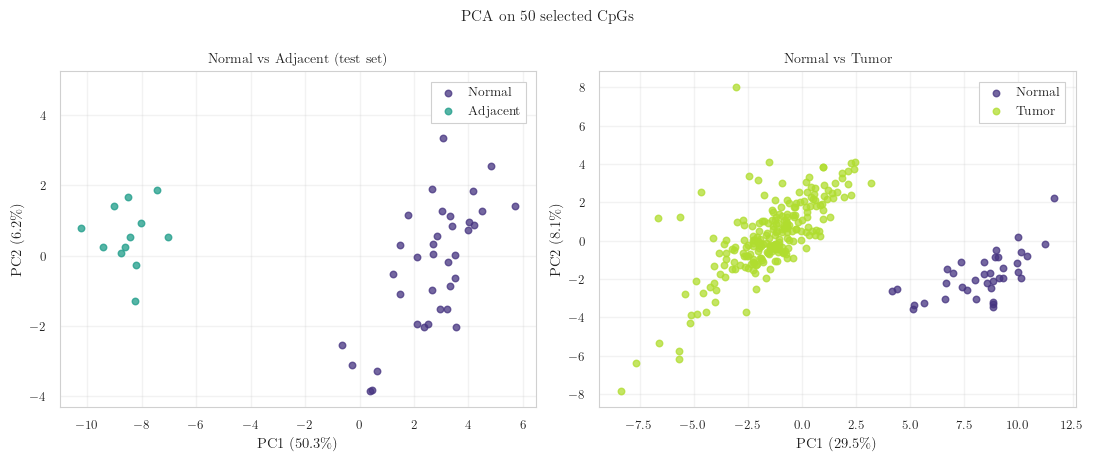

Saved: plots_outputs/50cpg_heatmap.pdf


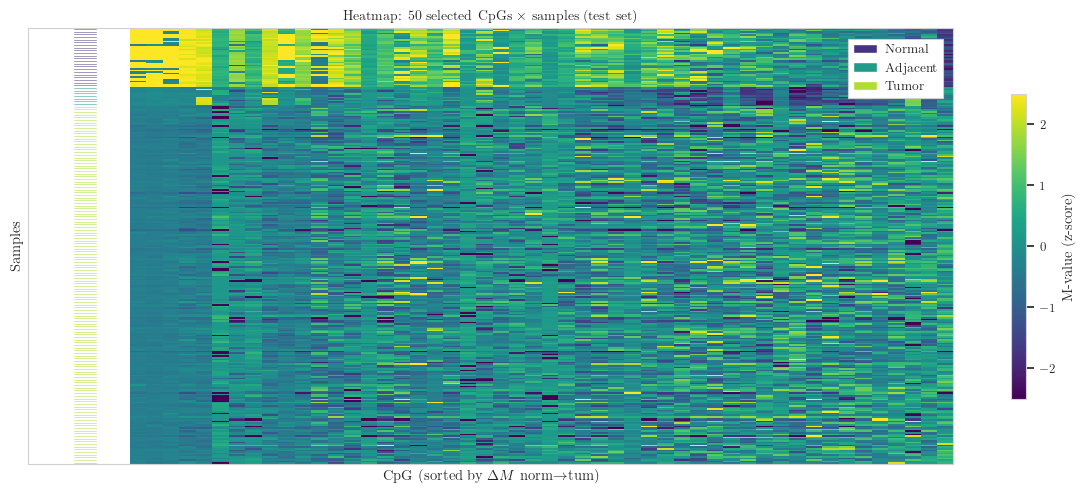

Saved: plots_outputs/50cpg_deltaM_boxplot.pdf


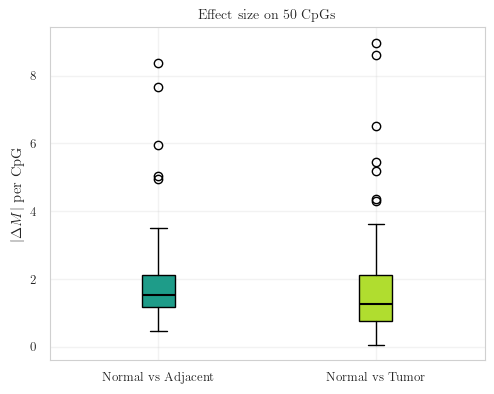


Summary |ΔM|:
  norm-adj : mean=2.036  median=1.524  max=8.357
  norm-tum : mean=1.949  median=1.255  max=8.974


In [34]:
# ============================================================
# PLOT — Visualizzazione separazione sulle 50 CpG selezionate
# Richiede nello scope:
#   selected_cpgs, jj_test, jj_eval
#   M_test, y_test, M_all, y_all
#   col_to_j, col_to_j_all
#   apply_thesis_style, place_legend
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

apply_thesis_style(use_tex=True, legend_outside=False)
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── Palette coerente ──
C_NORM = plt.cm.viridis(0.15)
C_ADJ  = plt.cm.viridis(0.55)
C_TUM  = plt.cm.viridis(0.88)

# ── Costruisci dataset per ogni coppia ──
# norm-adj: solo test set
mask_na  = np.isin(y_test, [0, 1])
X_na     = M_test[mask_na][:, jj_test]
y_na     = y_test[mask_na]

# norm-tum: normal da test + tutti i tumor da M_all
mask_tum      = (y_all == 2)
mask_norm_te  = (y_test == 0)
X_nt = np.vstack([M_test[mask_norm_te][:, jj_test],
                  M_all[mask_tum][:, jj_eval]])
y_nt = np.array([0]*mask_norm_te.sum() + [2]*mask_tum.sum(), dtype=int)

# norm+adj+tum insieme (per heatmap completa)
X_all3 = np.vstack([
    M_test[mask_norm_te][:, jj_test],
    M_test[y_test == 1][:, jj_test],
    M_all[mask_tum][:, jj_eval],
])
y_all3 = np.array(
    [0]*mask_norm_te.sum() +
    [1]*(y_test == 1).sum() +
    [2]*mask_tum.sum(), dtype=int
)
label_str3 = np.array(["Normal"]*mask_norm_te.sum() +
                       ["Adjacent"]*(y_test==1).sum() +
                       ["Tumor"]*mask_tum.sum())

# ============================================================
# FIG 1 — PCA 2D: norm-adj (test) e norm-tum
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (X_p, y_p, title, pairs) in zip(axes, [
    (X_na,  y_na,  "Normal vs Adjacent (test set)",
     [(0, C_NORM, "Normal"), (1, C_ADJ, "Adjacent")]),
    (X_nt,  y_nt,  "Normal vs Tumor",
     [(0, C_NORM, "Normal"), (2, C_TUM, "Tumor")]),
]):
    Xsc = StandardScaler().fit_transform(X_p)
    pca = PCA(n_components=2, random_state=42)
    Z   = pca.fit_transform(Xsc)
    ve  = pca.explained_variance_ratio_

    for lab, col, lbl in pairs:
        mask = (y_p == lab)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=[col], s=22, alpha=0.75, label=lbl, zorder=2)

    ax.set_xlabel(rf"PC1 ({ve[0]*100:.1f}\%)")
    ax.set_ylabel(rf"PC2 ({ve[1]*100:.1f}\%)")
    ax.set_title(title, fontsize=10)
    place_legend(ax)

fig.suptitle("PCA on 50 selected CpGs", fontsize=11, y=1.01)
fig.tight_layout()
pdf = OUTDIR / "50cpg_pca_norm_adj_tum.pdf"
fig.savefig(pdf, bbox_inches="tight")
print(f"Saved: {pdf}")
plt.show()

# ============================================================
# FIG 2 — Heatmap delle 50 CpG (norm+adj+tum, test set)
# ordine campioni per label, ordine CpG per |ΔM| norm-tum
# ============================================================
# sort CpG per |ΔM| norm vs tum
m0_nt = X_all3[y_all3 == 0].mean(0)
m2_nt = X_all3[y_all3 == 2].mean(0)
cpg_order = np.argsort(m2_nt - m0_nt)  # crescente: ipo- a sx, iper- a dx

# sort campioni per label
sample_order = np.argsort(y_all3)
X_heat = X_all3[sample_order][:, cpg_order]
y_heat = y_all3[sample_order]

# colori riga (label)
row_colors_vals = [C_NORM if l == 0 else C_ADJ if l == 1 else C_TUM for l in y_heat]
row_colors = np.array(row_colors_vals)

# z-score per colonna (per visualizzazione)
Xz = (X_heat - X_heat.mean(0)) / (X_heat.std(0) + 1e-12)

fig2, ax2 = plt.subplots(figsize=(12, 5))
im = ax2.imshow(Xz, aspect="auto", cmap="viridis",
                vmin=-2.5, vmax=2.5, interpolation="nearest")

# barre colorate per label a sinistra
n_norm = (y_heat == 0).sum()
n_adj  = (y_heat == 1).sum()
n_tum  = (y_heat == 2).sum()

for start, n, col, lbl in [
    (0,                 n_norm, C_NORM, "Normal"),
    (n_norm,            n_adj,  C_ADJ,  "Adjacent"),
    (n_norm + n_adj,    n_tum,  C_TUM,  "Tumor"),
]:
    ax2.barh(np.arange(start, start + n), [-1.5]*n,
             left=-2.5, color=col, height=1.0, label=lbl)

plt.colorbar(im, ax=ax2, label="M-value (z-score)", shrink=0.7)
ax2.set_xlabel("CpG (sorted by $\\Delta M$ norm$\\to$tum)")
ax2.set_ylabel("Samples")
ax2.set_title("Heatmap: 50 selected CpGs × samples (test set)", fontsize=10)
ax2.set_yticks([])
ax2.set_xticks([])
place_legend(ax2)
fig2.tight_layout()
pdf2 = OUTDIR / "50cpg_heatmap.pdf"
fig2.savefig(pdf2, bbox_inches="tight")
print(f"Saved: {pdf2}")
plt.show()

# ============================================================
# FIG 3 — Boxplot |ΔM| per le 50 CpG: norm-adj vs norm-tum
# ============================================================
m0_na = X_na[y_na == 0].mean(0)
m1_na = X_na[y_na == 1].mean(0)
dm_na = np.abs(m1_na - m0_na)

m0_nt2 = X_nt[y_nt == 0].mean(0)
m2_nt2 = X_nt[y_nt == 2].mean(0)
dm_nt = np.abs(m2_nt2 - m0_nt2)

fig3, ax3 = plt.subplots(figsize=(5, 4))
bp = ax3.boxplot([dm_na, dm_nt],
                 labels=["Normal vs Adjacent", "Normal vs Tumor"],
                 patch_artist=True,
                 medianprops=dict(color="black", linewidth=1.5))
bp["boxes"][0].set_facecolor(C_ADJ)
bp["boxes"][1].set_facecolor(C_TUM)

ax3.set_ylabel(r"$|\Delta M|$ per CpG")
ax3.set_title("Effect size on 50 CpGs", fontsize=10)
fig3.tight_layout()
pdf3 = OUTDIR / "50cpg_deltaM_boxplot.pdf"
fig3.savefig(pdf3, bbox_inches="tight")
print(f"Saved: {pdf3}")
plt.show()

print(f"\nSummary |ΔM|:")
print(f"  norm-adj : mean={dm_na.mean():.3f}  median={np.median(dm_na):.3f}  max={dm_na.max():.3f}")
print(f"  norm-tum : mean={dm_nt.mean():.3f}  median={np.median(dm_nt):.3f}  max={dm_nt.max():.3f}")


In [35]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs)]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 56
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 0


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [36]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(final_cpgs)]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 5000
Geni COSMIC breast: 44
CpG trovate nel manifest: 5000 / 5000
Geni associati alle 50 CpG (unique): 3987
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 8


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
15,AKT1,oncogene,1,"breast, colorectal, ovarian, NSCLC"
74,BRCA2,TSG,1,"breast, ovarian, pancreatic"
217,ESR1,"oncogene, TSG, fusion",1,breast
244,FBLN2,TSG,2,"breast cancer, colorectal adenocarcinoma"
280,GATA3,"oncogene, TSG",1,breast
399,MAP2K4,"oncogene, TSG",1,"pancreatic, breast, colorectal"
579,RB1,TSG,1,"retinoblastoma, sarcoma, breast, small cell lu..."
681,TBX3,"oncogene, TSG",1,"breast, large intestine, skin"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [37]:
!pip install gprofiler-official -q

In [38]:
!pip install gprofiler-official -q
from gprofiler import GProfiler
import pandas as pd

gp = GProfiler(return_dataframe=True)

# ── STEP 1: costruisci background dai geni delle 5000 final_cpgs ──
m5000 = man.loc[man["IlmnID"].isin(final_cpgs.tolist()),
                ["IlmnID", "UCSC_RefGene_Name"]].copy()
m5000["GENE_SYMBOL"] = m5000["UCSC_RefGene_Name"].fillna("").str.split(";")
m5000 = m5000.explode("GENE_SYMBOL")
m5000["GENE_SYMBOL"] = m5000["GENE_SYMBOL"].str.strip()
background_genes = list(set(m5000["GENE_SYMBOL"]) - {""})
print(f"Background genes (5000 CpG): {len(background_genes)}")

# ── STEP 2: enrichment CON background corretto ──
results = gp.profile(
    organism='hsapiens',
    query=list(genes_50),
    background=background_genes,
    sources=['GO:BP', 'KEGG', 'REAC'],
    significance_threshold_method='fdr',
)
results_sig = results[results['p_value'] < 0.05].sort_values('p_value')
print(f"\nTermini significativi: {len(results_sig)}")
print(results_sig[['source','name','p_value','intersection_size']].head(20))

Background genes (5000 CpG): 3987

Termini significativi: 7
  source                              name       p_value  intersection_size
0  GO:BP                  cellular process  1.643294e-09               2898
1  GO:BP                biological_process  8.692918e-09               2965
2   REAC                REACTOME root term  9.642575e-04               1861
3   KEGG                    KEGG root term  1.433727e-02               1419
4  GO:BP  multicellular organismal process  2.204754e-02               1445
5  GO:BP  regulation of biological process  2.693714e-02               2089
6  GO:BP             biological regulation  4.898065e-02               2165


In [39]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs)]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 5000 / 5000
Geni unici associati alle 50 CpG: 3987

Geni noti nel field cancerization: 20
  ['BRCA1', 'BRCA2', 'CCND2', 'CDKN2A', 'DAB2IP', 'DKK3', 'HOXA10', 'HOXA5', 'KMT2A', 'NDRG2', 'PCDH10', 'RASSF1', 'RUNX3', 'SFRP2', 'SFRP5', 'SMPD3', 'TBX2', 'TBX3', 'XPC', 'ZEB1']
       CpG GENE_SYMBOL              direction  coef_svm
cg02286533       BRCA1  hypomethylated_in_adj -0.000741
cg24900425       BRCA1  hypomethylated_in_adj -0.000135
cg24674189       BRCA2 hypermethylated_in_adj  0.000093
cg08333564       CCND2  hypomethylated_in_adj -0.000745
cg23322868      CDKN2A  hypomethylated_in_adj -0.000599
cg04763867      DAB2IP  hypomethylated_in_adj -0.000366
cg16859537        DKK3  hypomethylated_in_adj -0.001375
cg01215762      HOXA10  hypomethylated_in_adj -0.000122
cg18134292      HOXA10 hypermethylated_in_adj  0.000819
cg19759481       HOXA5  hypomethylated_in_adj -0.001440
cg25506432       HOXA5  hypomethylated_in_adj -0.000916
cg20697405       KMT2A hyperme

In [40]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(final_cpgs)]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 5000 / 5000
Geni unici associati alle 50 CpG: 3987

Geni noti nel field cancerization: 20
  ['BRCA1', 'BRCA2', 'CCND2', 'CDKN2A', 'DAB2IP', 'DKK3', 'HOXA10', 'HOXA5', 'KMT2A', 'NDRG2', 'PCDH10', 'RASSF1', 'RUNX3', 'SFRP2', 'SFRP5', 'SMPD3', 'TBX2', 'TBX3', 'XPC', 'ZEB1']
       CpG GENE_SYMBOL              direction  coef_svm
cg02286533       BRCA1  hypomethylated_in_adj -0.000741
cg24900425       BRCA1  hypomethylated_in_adj -0.000135
cg24674189       BRCA2 hypermethylated_in_adj  0.000093
cg08333564       CCND2  hypomethylated_in_adj -0.000745
cg23322868      CDKN2A  hypomethylated_in_adj -0.000599
cg04763867      DAB2IP  hypomethylated_in_adj -0.000366
cg16859537        DKK3  hypomethylated_in_adj -0.001375
cg01215762      HOXA10  hypomethylated_in_adj -0.000122
cg18134292      HOXA10 hypermethylated_in_adj  0.000819
cg19759481       HOXA5  hypomethylated_in_adj -0.001440
cg25506432       HOXA5  hypomethylated_in_adj -0.000916
cg20697405       KMT2A hyperme

In [41]:
# ============================================================
# CpG KNAPSACK POST-SVM — MILP (PuLP/CBC) + vincoli biologici opzionali
#
# Flusso:
#   1) Estrae coef LinearSVC sulle 5000 CpG (final_cpgs)
#   2) Carica M_all / y_all dal parquet (norm+adj+tum) in M-space
#   3) Costruisce pool top-N per |coef| e conflict edges (corr su M_train)
#   4) MILP: seleziona K CpG massimizzando value = comb(|coef|, |ΔM|, RSKF score)
#      + vincoli: chr_max, conflict edges, PoolA min, PoolB max
#      + (opzionali) vincoli biologici: promoter quota, island quota, max per gene, min geni distinti
#   5) Eval separazione: Normal-vs-Adjacent su M_test; Normal-vs-Tumor su (test normals + all tumors)
#
# Dipendenze richieste nello scope:
#   - final_cpgs          : np.ndarray (5000,)   — output STEP6
#   - cpg_cols_current    : np.ndarray (p,)      — colonne di M_train/M_test
#   - M_train, M_test     : matrici post STEP2 (M-space)
#   - y_train, y_test
#   - step3_stats         : dict con "score", "abs_deltaM_full" allineati a cpg_candidates
#   - cpg_candidates      : np.ndarray (n_cand,)
#   - poolA_cpgs, poolB_cpgs (o None)
#   - cpg_to_chr          : dict CpG -> chr (stringa tipo "1","2","X"...)
#   - svm_pipe            : Pipeline già fittato su X_train[:, final_cpgs]
#
# (Opzionali, per vincoli biologici)
#   - cpg_to_gene         : dict CpG -> gene (string o "GENE1;GENE2")
#   - cpg_to_feature      : dict CpG -> feature group ("TSS200","TSS1500","Body","Intergenic"...)
#   - cpg_to_island       : dict CpG -> island group ("Island","N_Shore","S_Shore","OpenSea"...)
# ============================================================

import numpy as np
import polars as pl
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# --- MILP
import pulp

# ──────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]          # 0=norm, 1=adj, 2=tum

K            = 50                  # CpG da selezionare
N_POOL       = 500                 # top-N da final_cpgs per |coef|
CHR_MAX      = 8                   # max CpG per cromosoma
CORR_THR     = 0.85                # soglia correlazione conflict edges
W_COEF       = 0.50                # peso |coef_SVM|
W_DM         = 0.30                # peso |ΔM|
W_SCORE      = 0.20                # peso RSKF score (inverso)

K_A_min      = 30                  # min da Pool A (island-anchored)
K_B_max      = 20                  # max da Pool B
RANDOM_STATE = 42

EPS_M        = 1e-6

# ──────────────────────────────────────────────
# BIO CONSTRAINTS (OPZIONALI) — metti None per disattivare
# ──────────────────────────────────────────────
# Quote per contesto genomico (se cpg_to_feature / cpg_to_island disponibili)
K_PROMOTER_MIN = None   # es. 15  (TSS200/TSS1500/1stExon/5'UTR)
K_ISLAND_MIN   = None   # es. 10  ("Island")
K_SHORE_MIN    = None   # es. 10  ("N_Shore" + "S_Shore")

# Diversità gene (se cpg_to_gene disponibile)
MAX_PER_GENE    = None  # es. 2
MIN_DISTINCT_G  = None  # es. 30

# Timeout CBC (secondi)
CBC_TIME_LIMIT  = 60

# ──────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def safe_std(z):
    return z.std(0, ddof=1) + 1e-12

def rank_norm_asc(v):
    """rank normalizzato: più alto v -> rank più alto (in [0,1])"""
    v = np.asarray(v, float)
    v2 = v.copy()
    # penalizza NaN mandandoli sotto al minimo
    if np.isnan(v2).any():
        mn = np.nanmin(v2)
        v2 = np.where(np.isnan(v2), mn - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, (len(v2) - 1))

def rank_norm_desc(v):
    """rank normalizzato: più basso v -> rank più alto"""
    return 1.0 - rank_norm_asc(v)

def parse_gene(g):
    if g is None: 
        return None
    if isinstance(g, (list, tuple)):
        g = ";".join([str(x) for x in g])
    g = str(g).strip()
    if g == "" or g.lower() == "nan":
        return None
    # prende il primo gene se multipli separati da ';' o ','
    for sep in [";", ","]:
        if sep in g:
            g = g.split(sep)[0].strip()
            break
    return g if g != "" else None

def in_promoter(feat):
    if feat is None: 
        return False
    s = str(feat)
    return any(x in s for x in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

# ──────────────────────────────────────────────
# 1. Estrai coef SVM dalle 5000 CpG (final_cpgs)
# ──────────────────────────────────────────────
cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, \
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. " \
    f"Assicurati che svm_pipe sia stato fittato su X_train[:,final_cpgs]."

coef_final = raw_coef

print(f"final_cpgs       : {final_arr.size}")
print(f"coef range       : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos coef (norm<adj ipermet.) : {(coef_final > 0).sum()}")
print(f"  neg coef (norm>adj ipomet.)  : {(coef_final < 0).sum()}")

# ──────────────────────────────────────────────
# 2. Carica M_all / y_all (norm + adj + tum)
# ──────────────────────────────────────────────
print("\nCaricamento dati completi (label 0,1,2)...")

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)

y_all = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols]

common = [c for c in cpg_cols_parquet if c in col_to_j]      # usa solo CpG presenti nel train space
M_all_beta = beta_all.select(common).to_numpy().astype(np.float32)
M_all = beta_to_m(M_all_beta).astype(np.float32)

col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape      : {M_all.shape}")
print(f"y_all distrib    : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ──────────────────────────────────────────────
# 3. Allinea RSKF score e |ΔM| alle final_cpgs
# ──────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"],           dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array([cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr], dtype=float)
absdM_final = np.array([cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr], dtype=float)

n_missing = int(np.isnan(score_final).sum())
if n_missing > 0:
    print(f"⚠ {n_missing} CpG di final_cpgs non trovate in cpg_candidates — score=nan, saranno penalizzate.")

# ──────────────────────────────────────────────
# 4. Costruisci pool knapsack (top-N per |coef|)
# ──────────────────────────────────────────────
order_coef  = np.argsort(-np.abs(coef_final))
pool_idx    = order_coef[:N_POOL]

pool_cpgs   = final_arr[pool_idx]
pool_coef   = coef_final[pool_idx]
pool_score  = score_final[pool_idx]
pool_absdM  = absdM_final[pool_idx]

print(f"\nPool knapsack    : {len(pool_cpgs)} CpGs (top |coef_SVM|)")
print(f"|coef| range     : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ──────────────────────────────────────────────
# 5. Pool A / B nel pool
# ──────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in = [c for c in pool_cpgs if c in _poolA_set]
poolB_in = [c for c in pool_cpgs if c in _poolB_set]

K_A_use  = min(K_A_min, len(poolA_in))
K_B_use  = K_B_max

print(f"Pool A nel pool  : {len(poolA_in)}  (K_A_min usato: {K_A_use})")
print(f"Pool B nel pool  : {len(poolB_in)}  (K_B_max usato: {K_B_use})")

# ──────────────────────────────────────────────
# 6. Conflict edges (correlazione su M_train) — solo CpG presenti in train columns
# ──────────────────────────────────────────────
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]
    poolA_in   = [c for c in pool_cpgs if c in _poolA_set]
    poolB_in   = [c for c in pool_cpgs if c in _poolB_set]

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)

Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / safe_std(Z)
C = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

n_p = len(pool_cpgs)
tot_pairs = n_p * (n_p - 1) // 2
print(f"\nConflict edges   : {len(conflict_pairs):,} / {tot_pairs:,} ({100*len(conflict_pairs)/max(1,tot_pairs):.3f}%) a |r|>={CORR_THR}")

# ──────────────────────────────────────────────
# 7. Funzione valore (rank-normalizzata)
# ──────────────────────────────────────────────
r_coef  = rank_norm_asc(np.abs(pool_coef))
r_dM    = rank_norm_asc(pool_absdM)
r_score = rank_norm_desc(pool_score)

value = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score
print(f"\nValore CpG       : min={value.min():.4f}  max={value.max():.4f}")

# ──────────────────────────────────────────────
# 8. MILP (PuLP/CBC)
# ──────────────────────────────────────────────
print("\n[MILP] Setup...")

chr_arr = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)

# BIO maps opzionali
_has_gene    = ("cpg_to_gene" in globals()) and (globals()["cpg_to_gene"] is not None)
_has_feat    = ("cpg_to_feature" in globals()) and (globals()["cpg_to_feature"] is not None)
_has_island  = ("cpg_to_island" in globals()) and (globals()["cpg_to_island"] is not None)

cpg_to_gene   = globals().get("cpg_to_gene", None)
cpg_to_feature= globals().get("cpg_to_feature", None)
cpg_to_island = globals().get("cpg_to_island", None)

# Prepara categorie promoter/island/shore (se disponibili)
is_prom = np.zeros(n_p, dtype=int)
is_island = np.zeros(n_p, dtype=int)
is_shore  = np.zeros(n_p, dtype=int)

if _has_feat:
    for k, c in enumerate(pool_cpgs):
        is_prom[k] = 1 if in_promoter(cpg_to_feature.get(c, None)) else 0

if _has_island:
    for k, c in enumerate(pool_cpgs):
        g = cpg_to_island.get(c, None)
        s = "" if g is None else str(g)
        is_island[k] = 1 if "Island" in s else 0
        is_shore[k]  = 1 if ("Shore" in s) else 0  # N_Shore o S_Shore

# Prepara mapping gene (se disponibile)
gene_of = np.array([None]*n_p, dtype=object)
if _has_gene:
    for k, c in enumerate(pool_cpgs):
        gene_of[k] = parse_gene(cpg_to_gene.get(c, None))

# Variabili MILP
prob = pulp.LpProblem("CpG_Knapsack_PostSVM", pulp.LpMaximize)
x = [pulp.LpVariable(f"x_{i}", lowBound=0, upBound=1, cat="Binary") for i in range(n_p)]

# Obiettivo
prob += pulp.lpSum([float(value[i]) * x[i] for i in range(n_p)])

# Cardinalità
prob += pulp.lpSum(x) == int(K), "K_exact"

# Pool A min (solo se poolA_cpgs fornito)
if len(_poolA_set) > 0 and K_A_use > 0:
    prob += pulp.lpSum([x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set]) >= int(K_A_use), "PoolA_min"

# Pool B max (solo se poolB_cpgs fornito)
if len(_poolB_set) > 0 and K_B_use is not None:
    prob += pulp.lpSum([x[i] for i in range(n_p) if pool_cpgs[i] in _poolB_set]) <= int(K_B_use), "PoolB_max"

# Max per cromosoma
if CHR_MAX is not None:
    chrs = [c for c in np.unique(chr_arr) if c != ""]
    for ch in chrs:
        prob += pulp.lpSum([x[i] for i in range(n_p) if chr_arr[i] == ch]) <= int(CHR_MAX), f"ChrMax_{ch}"

# Conflict edges (decorrelazione)
for (i, j) in conflict_pairs:
    prob += x[i] + x[j] <= 1, f"conf_{i}_{j}"

# --- BIO vincoli opzionali
if K_PROMOTER_MIN is not None:
    if _has_feat:
        prob += pulp.lpSum([x[i] for i in range(n_p) if is_prom[i] == 1]) >= int(K_PROMOTER_MIN), "Promoter_min"
    else:
        print("⚠ K_PROMOTER_MIN richiesto ma cpg_to_feature non disponibile: vincolo ignorato.")

if K_ISLAND_MIN is not None:
    if _has_island:
        prob += pulp.lpSum([x[i] for i in range(n_p) if is_island[i] == 1]) >= int(K_ISLAND_MIN), "Island_min"
    else:
        print("⚠ K_ISLAND_MIN richiesto ma cpg_to_island non disponibile: vincolo ignorato.")

if K_SHORE_MIN is not None:
    if _has_island:
        prob += pulp.lpSum([x[i] for i in range(n_p) if is_shore[i] == 1]) >= int(K_SHORE_MIN), "Shore_min"
    else:
        print("⚠ K_SHORE_MIN richiesto ma cpg_to_island non disponibile: vincolo ignorato.")

# Max per gene + min geni distinti (introduce y_g)
y_g = None
if (MAX_PER_GENE is not None or MIN_DISTINCT_G is not None):
    if not _has_gene:
        print("⚠ Vincoli gene richiesti ma cpg_to_gene non disponibile: vincoli ignorati.")
    else:
        genes = sorted({g for g in gene_of.tolist() if g is not None})
        y_g = {g: pulp.LpVariable(f"y_{g}", lowBound=0, upBound=1, cat="Binary") for g in genes}

        # link: se selezioni una CpG di gene g -> y_g=1
        for i in range(n_p):
            g = gene_of[i]
            if g is not None:
                prob += x[i] <= y_g[g], f"link_{i}"

        if MAX_PER_GENE is not None:
            for g in genes:
                prob += pulp.lpSum([x[i] for i in range(n_p) if gene_of[i] == g]) <= int(MAX_PER_GENE), f"MaxPerGene_{g}"

        if MIN_DISTINCT_G is not None:
            prob += pulp.lpSum([y_g[g] for g in genes]) >= int(MIN_DISTINCT_G), "MinDistinctGenes"

print(f"[MILP] Vars: x={n_p}" + (f", y_g={len(y_g)}" if y_g is not None else ""))

# Solve
solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
status = prob.solve(solver)
status_str = pulp.LpStatus.get(status, str(status))
obj_val = pulp.value(prob.objective)

print(f"[MILP] Status: {status_str} | Objective: {obj_val:.6f}")

if status_str not in ["Optimal", "Feasible"]:
    raise RuntimeError(f"MILP infeasible/failed. Status={status_str}. "
                       f"Prova a rilassare CHR_MAX/CORR_THR/K_A_min/K_B_max o BIO constraints.")

sel_idx = np.array([i for i in range(n_p) if pulp.value(x[i]) > 0.5], dtype=int)
if sel_idx.size != K:
    raise RuntimeError(f"MILP ha selezionato {sel_idx.size}/{K} (status={status_str}).")

selected_cpgs = pool_cpgs[sel_idx].tolist()

# ──────────────────────────────────────────────
# 9. Diagnostica selezione
# ──────────────────────────────────────────────
_cnt_A = sum(1 for c in selected_cpgs if c in _poolA_set)
_cnt_B = sum(1 for c in selected_cpgs if c in _poolB_set)
_chrs, _cnts = np.unique(chr_arr[sel_idx], return_counts=True)
_chr_str = "  ".join(f"chr{c}:{n}" for c, n in zip(_chrs, _cnts) if c != "")

print(f"\n{'='*70}")
print(f"  Selezionate  : {len(selected_cpgs)} / K={K}")
print(f"  Pool A       : {_cnt_A}  (min: {K_A_use})")
print(f"  Pool B       : {_cnt_B}  (max: {K_B_use})")
print(f"  mean|coef|   : {np.abs(pool_coef[sel_idx]).mean():.4f}")
print(f"  mean|ΔM|     : {np.nanmean(pool_absdM[sel_idx]):.4f}")
print(f"  Cromosomi    : {_chr_str if _chr_str else 'N/A'}")
if _has_feat and K_PROMOTER_MIN is not None:
    print(f"  Promoter     : {int(is_prom[sel_idx].sum())} (min {K_PROMOTER_MIN})")
if _has_island and K_ISLAND_MIN is not None:
    print(f"  Island       : {int(is_island[sel_idx].sum())} (min {K_ISLAND_MIN})")
if _has_island and K_SHORE_MIN is not None:
    print(f"  Shore        : {int(is_shore[sel_idx].sum())} (min {K_SHORE_MIN})")
if _has_gene and (MIN_DISTINCT_G is not None or MAX_PER_GENE is not None):
    sel_genes = [parse_gene(cpg_to_gene.get(c, None)) for c in selected_cpgs]
    sel_genes = [g for g in sel_genes if g is not None]
    print(f"  Distinct genes: {len(set(sel_genes))} " + (f"(min {MIN_DISTINCT_G})" if MIN_DISTINCT_G is not None else ""))
print(f"{'='*70}")

# ──────────────────────────────────────────────
# 10. Valutazione separazione — SENZA leakage
#     norm-adj : SOLO M_test
#     norm-tum : test normals + all tumors
# ──────────────────────────────────────────────
LABEL_NAMES = {0: "Normal", 1: "Adjacent", 2: "Tumor"}

# allinea le 50 CpG a M_test (train/test condividono cpg_cols_current)
jj_test = np.array([col_to_j[c] for c in selected_cpgs if c in col_to_j], dtype=int)
# allinea le 50 CpG a M_all (colonne = common)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs if c in col_to_j_all], dtype=int)

eval_results = {}

def eval_pair(name, X, ybin):
    out = {}
    print(f"\n[EVAL] {name}  n={X.shape[0]} (0={(ybin==0).sum()}, 1={(ybin==1).sum()})")
    if X.shape[0] < 10 or (ybin==0).sum()==0 or (ybin==1).sum()==0:
        print("  Campioni insufficienti.")
        eval_results[name] = out
        return

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette : N/A ({e})")

    try:
        X_sc = StandardScaler().fit_transform(X)
        lr = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, int((ybin==0).sum()), int((ybin==1).sum()))
        aucs = cross_val_score(lr, X_sc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV     : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV     : N/A ({e})")

    m0 = X[ybin==0].mean(0); m1 = X[ybin==1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|   : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1    : {out['pca_pc1']:.3f}")
    except Exception as e:
        out["pca_pc1"] = None
        print(f"  PCA PC1    : N/A ({e})")

    eval_results[name] = out

# ── 10a: Normal vs Adjacent (test set)
mask = np.isin(y_test, [0, 1])
X_p = M_test[mask][:, jj_test]
y_p = (y_test[mask] == 1).astype(int)
eval_pair("Normal_vs_Adjacent (test set)", X_p, y_p)

# ── 10b: Normal vs Tumor (test normals + all tumors)
mask_tum = (y_all == 2)
mask_norm_test = (y_test == 0)

X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_test][:, jj_test]
X_p = np.vstack([X_norm, X_tum])
y_p = np.array([0]*X_norm.shape[0] + [1]*X_tum.shape[0], dtype=int)
eval_pair("Normal_vs_Tumor (test norm + all tumor)", X_p, y_p)

print("\n[DONE] Oggetti disponibili:")
print("  selected_cpgs, sel_idx, eval_results, conflict_pairs, pool_cpgs, value, M_all, y_all")


final_cpgs       : 5000
coef range       : [-0.0039, 0.0032]
  pos coef (norm<adj ipermet.) : 1100
  neg coef (norm>adj ipomet.)  : 3900

Caricamento dati completi (label 0,1,2)...
M_all shape      : (477, 279578)
y_all distrib    : {0: 113, 1: 140, 2: 224}

Pool knapsack    : 500 CpGs (top |coef_SVM|)
|coef| range     : [0.0016, 0.0039]
Pool A nel pool  : 91  (K_A_min usato: 30)
Pool B nel pool  : 409  (K_B_max usato: 20)

Conflict edges   : 2 / 124,750 (0.002%) a |r|>=0.85

Valore CpG       : min=0.0764  max=0.9675

[MILP] Setup...
[MILP] Vars: x=500
[MILP] Status: Optimal | Objective: 40.447896

  Selezionate  : 50 / K=50
  Pool A       : 30  (min: 30)
  Pool B       : 20  (max: 20)
  mean|coef|   : 0.0024
  mean|ΔM|     : 2.0135
  Cromosomi    : chr1:4  chr10:2  chr11:5  chr12:3  chr15:5  chr16:4  chr17:2  chr18:1  chr19:4  chr2:3  chr20:2  chr3:2  chr4:2  chr5:4  chr6:3  chr7:1  chr8:2  chr9:1

[EVAL] Normal_vs_Adjacent (test set)  n=49 (0=37, 1=12)
  Silhouette : 0.4218
  AUC CV 

In [42]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs)]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 56

Geni noti nel field cancerization: 1
  ['TBX2']
       CpG GENE_SYMBOL             direction  coef_svm
cg07095230        TBX2 hypomethylated_in_adj -0.002098

Tabella completa (57 righe):
       CpG  GENE_SYMBOL              direction  coef_svm
cg18558388       SAP30L hypermethylated_in_adj  0.003192
cg18558388   SAP30L-AS1 hypermethylated_in_adj  0.003192
cg26870803           PC hypermethylated_in_adj  0.002578
cg26870803        LRFN4 hypermethylated_in_adj  0.002578
cg04018448      CASKIN1 hypermethylated_in_adj  0.001855
cg24522982        KCTD1  hypomethylated_in_adj -0.001823
cg17504203       SPIRE2  hypomethylated_in_adj -0.001872
cg17832858        CYTH3  hypomethylated_in_adj -0.001980
cg04287931        BMP2K  hypomethylated_in_adj -0.001991
cg25683185        ACRBP  hypomethylated_in_adj -0.002012
cg26985666       SLC1A2  hypomethylated_in_adj -0.002018
cg15732840 LOC100132215  hypomethylated_in_adj -0.002026

In [43]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs)]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 56
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 0


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


STEP 1 — Estrazione coef SVM
final_cpgs        : 5000
coef range        : [-0.0039, 0.0032]
  pos (ipermet.)  : 1100
  neg (ipomet.)   : 3900

STEP 2 — Caricamento M_all (label 0,1,2)
M_all shape       : (311, 280280)
y_all distrib     : {0: 182, 1: 60, 2: 69}

STEP 4 — Pool top-5000 per |coef_SVM|
Pool effettivo    : 5000 CpG
|coef| range      : [0.0000, 0.0039]
Pool A nel pool   : 512  →  K_A_use = 25  (nominale 25)

STEP 6 — Conflict edges (correlazione su M_train)
Conflict edges    : 23 / 12,497,500 (0.00%) a |r|≥0.85

STEP 7 — Attributi genomici dal manifest
CpG con promotore : 3022
CpG in island     : 1692
Geni distinti pool: 3491  →  G_min_use = 25  (nominale 25)

f1 value range    : [0.0424, 0.9965]
f2 norm factor    : 125.0  (K×(2+η) = 50×2.5)

STEP 10 — Sweep μ

[μ=0.000] Solving MILP...
  Status     : Optimal
  f1         : 47.8832
  f2         : 117.5000  (f2_hat=0.9400)
  Δ(bio/clf) : 0.0000
  Jaccard(0) : 1.0000
  Promotori  : 43  |  Islands: 50  |  Geni: 49
  Saturato   

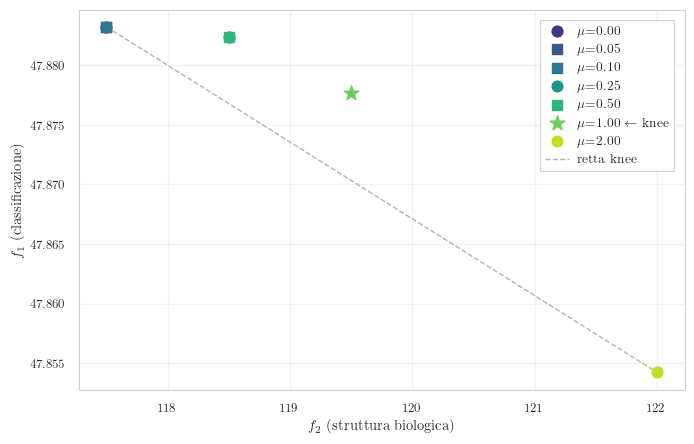

Salvato diagnostiche: knapsack_outputs/knapsack_sweep_diagnostics.pdf


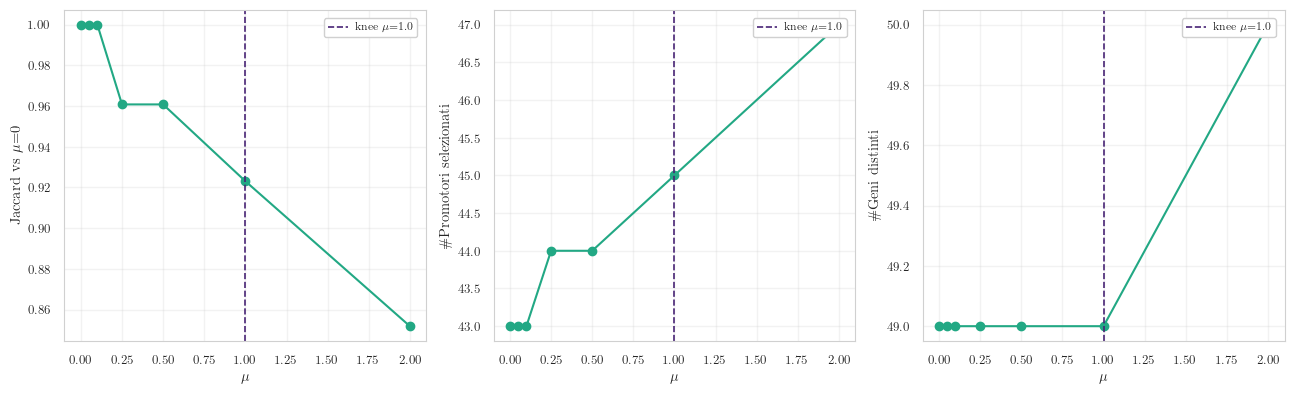

Salvato CSV sweep: knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG knee)

  [Normal vs Adjacent (test)]  n=49 (0=37, 1=12)
  Silhouette    : 0.4145
  AUC CV5       : 1.0000 ± 0.0000
  mean|ΔM|      : 2.6953
  PCA PC1       : 0.527

  [Normal vs Tumor]  n=106 (0=37, 1=69)
  Silhouette    : 0.4130
  AUC CV5       : 1.0000 ± 0.0000
  mean|ΔM|      : 2.0148
  PCA PC1       : 0.403

STEP 16 — Confronto μ=0 (pura classificazione) vs knee
                                      μ=0       knee
f1                                47.8832    47.8777
f2                               117.5000   119.5000
n_promoter                             43         45
n_island                               50         50
n_genes                                49         49
Jaccard(mu0, knee)                 0.9231

OUTPUT FINALE
  selected_cpgs_final : 50 CpG (knee, μ=1.0)
  sweep_results       : lista con tutte le run
  eval_results_final  : metriche separazione
  OUTDIR      

In [44]:
##### NUOVO MODELLO DELLO ZAIMO
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ
#
# Modello:
#   max  f1(x) + μ * f2_hat(x, y)
#
#   f1(x)     = Σ v_i * x_i       (classificazione)
#              v_i = 0.5*c̃_i + 0.2*d̃_i + 0.3*s̃_i
#
#   f2(x,y)   = Σ_{i∈P} x_i       (promotori)
#             + Σ_{i∈L} x_i        (CpG islands)
#             + 0.5 * Σ_g y_g      (geni distinti)
#
#   f2_hat    = f2 / (K * (2 + 0.5))  ∈ [0, 1]
#
# Vincoli hard:
#   C1: Σ x_i = K
#   C2: x_i + x_j ≤ 1   ∀ (i,j) ∈ E  (conflict edges, |r| ≥ 0.85)
#   C3: Σ_{chr=c} x_i ≤ 10   ∀ c
#   C4: Σ_{i∈A} x_i ≥ K_A*  (adattivo: min(25, |A ∩ I|))
#   C5: x_i ≤ y_g   ∀ i: gene(i)=g
#   C6: Σ_{gene=g} x_i ≤ 2   ∀ g
#   C7: Σ_g y_g ≥ G_min*  (adattivo: min(25, |G|))
#
# Sweep μ ∈ {0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0}
# Knee: distanza massima dalla retta (μ=0) → (max f2 osservato)
#
# Dipendenze nello scope (dal notebook):
#   final_cpgs, cpg_cols_current, M_train, M_test, y_train, y_test
#   step3_stats, cpg_candidates, poolA_cpgs, poolB_cpgs
#   cpg_to_chr, svm_pipe, man (manifest DataFrame)
#   apply_thesis_style, place_legend  (opzionale, per i plot)
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG — modifica qui
# ─────────────────────────────────────────────────────────────
BETA_PATH    = "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet"
ID_COL       = "id_tissue"
LABEL_COL    = "label"
LABELS_ALL   = [0, 1, 2]           # 0=Normal, 1=Adjacent, 2=Tumor

K            = 50                  # CpG da selezionare
N_POOL       = 5000                # top-N da final_cpgs per |coef|
CHR_MAX      = 10                  # C3: max CpG per cromosoma
CORR_THR     = 0.85                # C2: soglia correlazione conflict edges
ETA          = 0.5                 # peso geni in f2

W_COEF       = 0.5                 # peso |coef_SVM| in f1
W_DM         = 0.2                 # peso |ΔM| in f1 (abbassato per rischio doppio conteggio)
W_SCORE      = 0.3                 # peso RSKF score in f1

K_A_NOMINAL  = 25                  # C4: min Pool A (adattivo)
G_MIN_NOMINAL= 25                  # C7: min geni distinti (adattivo)
MAX_PER_GENE = 2                   # C6: max CpG per gene

CBC_TIME_LIMIT = 120               # secondi per ogni solve

MU_GRID = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

EPS_M    = 1e-6
RANDOM_STATE = 42

OUTDIR = Path("./knapsack_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    """Rank normalizzato in [0,1]: valore più alto → rank più alto."""
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    n = len(v2)
    return r / max(1, n - 1)

def rank_norm_desc(v):
    """Rank normalizzato: valore più basso → rank più alto."""
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    """
    Estrae il primo gene dal campo manifest (es. "BRCA1;TP53" → "BRCA1").
    Restituisce None se intergenico o NaN.
    """
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    """True se il contesto genomico è promotoriale."""
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    """True se il contesto è CpG Island."""
    if ctx is None:
        return False
    return "Island" in str(ctx) and "Shore" not in str(ctx) and "Shelf" not in str(ctx)

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    """
    Distanza massima dalla retta che congiunge
    il punto con f2 minimo (μ=0) e quello con f2 massimo.
    Ignora i punti saturati (f2 identico al precedente).
    """
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)

    # punti non saturati
    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0

    # normalizza in [0,1] × [0,1]
    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)

    # retta da primo a ultimo punto valido
    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)

    dists = []
    for i in range(len(idx_v)):
        p = np.array([f2_n[i], f1_n[i]])
        dists.append(np.linalg.norm((p - p0) - np.dot(p - p0, d_norm) * d_norm))

    return int(idx_v[np.argmax(dists)])


# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM dalle 5000 CpG
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all.tolist())}

final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, (
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. "
    "Assicurati che svm_pipe sia fittato su X_train[:, final_cpgs]."
)
coef_final = raw_coef

print(f"final_cpgs        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Carica M_all (norm+adj+tum) per evaluation
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 2 — Caricamento M_all (label 0,1,2)")
print("=" * 70)

beta_all = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
)
y_all  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols_set   = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols_set]

common       = [c for c in cpg_cols_parquet if c in col_to_j]
M_all_beta   = beta_all.select(common).to_numpy().astype(np.float32)
M_all        = beta_to_m(M_all_beta).astype(np.float32)
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape       : {M_all.shape}")
print(f"y_all distrib     : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ─────────────────────────────────────────────────────────────
# STEP 3 — Allinea RSKF score e |ΔM| a final_cpgs
# ─────────────────────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array(
    [cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
absdM_final = np.array(
    [cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
n_miss = int(np.isnan(score_final).sum())
if n_miss > 0:
    print(f"⚠ {n_miss} CpG non trovate in cpg_candidates (score=nan, penalizzate).")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Costruisci pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# rimuovi CpG non presenti in M_train
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    n_drop = (~valid_mask).sum()
    print(f"  ⚠ Rimosse {n_drop} CpG non presenti in M_train.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B nel pool
# ─────────────────────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]
poolB_in_pool = [c for c in pool_cpgs if c in _poolB_set]

# C4 adattivo
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use = {K_A_use}  (nominale {K_A_NOMINAL})")
if K_A_use < K_A_NOMINAL:
    print(f"  ⚠ K_A ridotto: solo {len(poolA_in_pool)} CpG Pool A nel pool top-{N_POOL}.")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su M_train)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges (correlazione su M_train)")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.2f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici dal manifest
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici dal manifest")
print("=" * 70)

# Usa il manifest 'man' già caricato nel notebook (cella 35/38)
# Colonne attese: IlmnID, UCSC_RefGene_Name, UCSC_RefGene_Group, Relation_to_UCSC_CpG_Island

man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

# dizionari rapidi
cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

# array per il pool
chr_arr    = np.array([cpg_to_chr.get(c, "") for c in pool_cpgs], dtype=object)
gene_arr   = np.array([parse_first_gene(cpg_gene_dict.get(c, None)) for c in pool_cpgs], dtype=object)
is_prom    = np.array([in_promoter(cpg_feat_dict.get(c, ""))   for c in pool_cpgs], dtype=int)
is_island  = np.array([in_island(cpg_island_dict.get(c, ""))   for c in pool_cpgs], dtype=int)

# geni annotati (solo non-None)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

# C7 adattivo
G_min_use = min(G_MIN_NOMINAL, len(genes_pool))
print(f"CpG con promotore : {is_prom.sum()}")
print(f"CpG in island     : {is_island.sum()}")
print(f"Geni distinti pool: {len(genes_pool)}  →  G_min_use = {G_min_use}  (nominale {G_MIN_NOMINAL})")

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1 (rank-normalizzata, pool fisso)
# ─────────────────────────────────────────────────────────────
r_coef  = rank_norm_asc(np.abs(pool_coef))
r_dM    = rank_norm_asc(pool_absdM)
r_score = rank_norm_desc(pool_score)

value   = W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score

F2_NORM = float(K * (2 + ETA))  # upper bound deterministico di f2

print(f"\nf1 value range    : [{value.min():.4f}, {value.max():.4f}]")
print(f"f2 norm factor    : {F2_NORM:.1f}  (K×(2+η) = {K}×{2+ETA})")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP per un dato μ
# ─────────────────────────────────────────────────────────────

def solve_milp(mu: float):
    """
    Risolve il MILP per un dato μ.
    Restituisce (selected_cpgs, f1_val, f2_val, status_str) oppure None se infeasible.
    """
    prob = pulp.LpProblem(f"CpG_Knapsack_mu{mu:.3f}", pulp.LpMaximize)

    # variabili CpG
    x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]

    # variabili gene (y_g ∈ {0,1})
    y_g = {g: pulp.LpVariable(f"yg_{g.replace('-','_')}", cat="Binary") for g in genes_pool}

    # ── Obiettivo ──────────────────────────────────────────────
    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat  = f2_expr / F2_NORM

    prob += f1_expr + mu * f2_hat

    # ── C1: cardinalità ────────────────────────────────────────
    prob += pulp.lpSum(x) == K, "C1_cardinality"

    # ── C2: conflict edges ──────────────────────────────────────
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_conf_{idx}"

    # ── C3: max per cromosoma ───────────────────────────────────
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch) <= CHR_MAX, f"C3_chr_{ch}"

    # ── C4: Pool A min (adattivo) ────────────────────────────────
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4_poolA_min"
        )

    # ── C5: link CpG → gene ─────────────────────────────────────
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_link_{i}"

    # ── C6: max CpG per gene ─────────────────────────────────────
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if len(idx_g) > 0:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_maxgene_{g}"

    # ── C7: min geni distinti (adattivo) ─────────────────────────
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7_min_genes"

    # ── Solve ────────────────────────────────────────────────────
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))

    obj_val = pulp.value(prob.objective)
    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [μ={mu:.3f}] Status={status_str} — INFEASIBLE/FAILED")
        return None

    sel_idx_milp = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx_milp.size != K:
        print(f"  [μ={mu:.3f}] MILP ha selezionato {sel_idx_milp.size}/{K} — SKIP")
        return None

    # valori obiettivo reali
    f1_val  = float(sum(value[i] for i in sel_idx_milp))
    f2_val  = float(
        is_prom[sel_idx_milp].sum()
        + is_island[sel_idx_milp].sum()
        + ETA * len({gene_arr[i] for i in sel_idx_milp if gene_arr[i] is not None})
    )

    selected = pool_cpgs[sel_idx_milp].tolist()
    return selected, f1_val, f2_val, status_str, sel_idx_milp


# ─────────────────────────────────────────────────────────────
# STEP 10 — Sweep su μ
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 10 — Sweep μ")
print("=" * 70)

sweep_results = []
sel_mu0 = None   # set a μ=0 per Jaccard

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving MILP...")
    result = solve_milp(mu)
    if result is None:
        sweep_results.append({
            "mu": mu, "status": "FAILED",
            "f1": np.nan, "f2": np.nan, "f2_hat": np.nan,
            "delta": np.nan, "jaccard_vs_0": np.nan,
            "n_promoter": np.nan, "n_island": np.nan, "n_genes": np.nan,
            "selected": []
        })
        continue

    selected, f1_val, f2_val, status_str, sel_idx_milp = result

    if mu == 0.0:
        sel_mu0 = selected

    f2_hat_val = f2_val / F2_NORM
    delta_val  = (mu * f2_hat_val) / max(f1_val, 1e-12)
    jacc       = jaccard(selected, sel_mu0) if sel_mu0 is not None else 1.0

    n_prom  = int(is_prom[sel_idx_milp].sum())
    n_isl   = int(is_island[sel_idx_milp].sum())
    n_genes = len({gene_arr[i] for i in sel_idx_milp if gene_arr[i] is not None})

    # flag saturazione
    sat = False
    if len(sweep_results) > 0 and not np.isnan(sweep_results[-1]["f2"]):
        sat = (f2_val == sweep_results[-1]["f2"])

    sweep_results.append({
        "mu": mu, "status": status_str,
        "f1": f1_val, "f2": f2_val, "f2_hat": f2_hat_val,
        "delta": delta_val, "jaccard_vs_0": jacc,
        "n_promoter": n_prom, "n_island": n_isl, "n_genes": n_genes,
        "saturated": sat,
        "selected": selected
    })

    print(f"  Status     : {status_str}")
    print(f"  f1         : {f1_val:.4f}")
    print(f"  f2         : {f2_val:.4f}  (f2_hat={f2_hat_val:.4f})")
    print(f"  Δ(bio/clf) : {delta_val:.4f}")
    print(f"  Jaccard(0) : {jacc:.4f}")
    print(f"  Promotori  : {n_prom}  |  Islands: {n_isl}  |  Geni: {n_genes}")
    print(f"  Saturato   : {sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Selezione knee e diagnostiche
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]
mu_vals   = [r["mu"] for r in valid_res]

knee_idx   = knee_index(f1_vals, f2_vals)
knee_res   = valid_res[knee_idx]
knee_mu    = knee_res["mu"]

print(f"Knee selezionato  : μ = {knee_mu:.3f}")
print(f"  f1              : {knee_res['f1']:.4f}")
print(f"  f2              : {knee_res['f2']:.4f}  (f2_hat={knee_res['f2_hat']:.4f})")
print(f"  Jaccard vs μ=0  : {knee_res['jaccard_vs_0']:.4f}")
print(f"  Promotori       : {knee_res['n_promoter']}")
print(f"  Islands         : {knee_res['n_island']}")
print(f"  Geni distinti   : {knee_res['n_genes']}")

selected_cpgs_final = knee_res["selected"]
print(f"\nSet finale (knee) : {len(selected_cpgs_final)} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Plot curva di trade-off
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

fig, ax = plt.subplots(figsize=(7, 4.5))

cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.9, len(valid_res)))

for i, (r, col) in enumerate(zip(valid_res, colors)):
    marker = "*" if r["mu"] == knee_mu else ("s" if r.get("saturated") else "o")
    size   = 120 if r["mu"] == knee_mu else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=f"$\mu$={r['mu']:.2f}" + (" $\leftarrow $ knee" if r["mu"] == knee_mu else ""))

# retta (μ=0) → (max f2 osservato)
p0 = np.array([f2_vals[0],  f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", linewidth=1.0,
        alpha=0.6, label="retta knee")

ax.set_xlabel(r"$f_2$ (struttura biologica)")
ax.set_ylabel(r"$f_1$ (classificazione)")

try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
pdf_path = OUTDIR / "knapsack_tradeoff_curve.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"\nSalvato plot: {pdf_path}")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — Plot diagnostiche sweep (Jaccard, #promoter, #genes)
# ─────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(13, 4))
mu_ax = [r["mu"] for r in valid_res]

for ax_i, (key, label) in zip(axes, [
    ("jaccard_vs_0", "Jaccard vs $\mu$=0"),
    ("n_promoter",   "\#Promotori selezionati"),
    ("n_genes",      "\#Geni distinti"),
]):
    vals = [r[key] for r in valid_res]
    ax_i.plot(mu_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
    ax_i.axvline(knee_mu, linestyle="--", color=cmap(0.1), linewidth=1.2, label=f"knee $\mu$={knee_mu}")
    ax_i.set_xlabel(r"$\mu$")
    ax_i.set_ylabel(label)
    ax_i.legend(fontsize=8)

fig2.tight_layout()
pdf2 = OUTDIR / "knapsack_sweep_diagnostics.pdf"
fig2.savefig(pdf2, dpi=300, bbox_inches="tight")
print(f"Salvato diagnostiche: {pdf2}")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva sweep summary CSV
# ─────────────────────────────────────────────────────────────
import csv

csv_path = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes", "saturated"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})

print(f"Salvato CSV sweep: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Valutazione separazione sulle 50 CpG (knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG knee)")
print("=" * 70)

# allineamento indici
jj_test = np.array([col_to_j[c]     for c in selected_cpgs_final if c in col_to_j],     dtype=int)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs_final if c in col_to_j_all], dtype=int)

def eval_pair(name, X, ybin):
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")

    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")

    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None

    return out

eval_results_final = {}

# Normal vs Adjacent (solo test set — no leakage)
mask_na = np.isin(y_test, [0, 1])
X_na    = M_test[mask_na][:, jj_test]
y_na    = (y_test[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair("Normal vs Adjacent (test)", X_na, y_na)

# Normal vs Tumor (test normals + tutti i tumor)
mask_tum      = (y_all == 2)
mask_norm_te  = (y_test == 0)
X_tum  = M_all[mask_tum][:, jj_eval]
X_norm = M_test[mask_norm_te][:, jj_test]
X_nt   = np.vstack([X_norm, X_tum])
y_nt   = np.array([0] * X_norm.shape[0] + [1] * X_tum.shape[0], dtype=int)
eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs knee (se diversi)
# ─────────────────────────────────────────────────────────────
if knee_mu != 0.0 and sel_mu0 is not None:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 (pura classificazione) vs knee")
    print("=" * 70)

    res_mu0 = next(r for r in valid_res if r["mu"] == 0.0)

    print(f"{'':30s} {'μ=0':>10s} {'knee':>10s}")
    print(f"{'f1':30s} {res_mu0['f1']:>10.4f} {knee_res['f1']:>10.4f}")
    print(f"{'f2':30s} {res_mu0['f2']:>10.4f} {knee_res['f2']:>10.4f}")
    print(f"{'n_promoter':30s} {res_mu0['n_promoter']:>10} {knee_res['n_promoter']:>10}")
    print(f"{'n_island':30s} {res_mu0['n_island']:>10} {knee_res['n_island']:>10}")
    print(f"{'n_genes':30s} {res_mu0['n_genes']:>10} {knee_res['n_genes']:>10}")
    print(f"{'Jaccard(mu0, knee)':30s} {jaccard(sel_mu0, selected_cpgs_final):>10.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final : {len(selected_cpgs_final)} CpG (knee, μ={knee_mu})")
print(f"  sweep_results       : lista con tutte le run")
print(f"  eval_results_final  : metriche separazione")
print(f"  OUTDIR              : {OUTDIR}")
print("=" * 70)

# dopo run con W_COSMIC=0
selected_cpgs_no_cosmic = selected_cpgs_final.copy()

In [45]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_final )]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 61
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 0


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [46]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs_final )]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 61

Geni noti nel field cancerization: 1
  ['TBX2']
       CpG GENE_SYMBOL             direction  coef_svm
cg07095230        TBX2 hypomethylated_in_adj -0.002098

Tabella completa (61 righe):
       CpG  GENE_SYMBOL              direction  coef_svm
cg18558388       SAP30L hypermethylated_in_adj  0.003192
cg18558388   SAP30L-AS1 hypermethylated_in_adj  0.003192
cg00804091         EMC8 hypermethylated_in_adj  0.001999
cg00804091       COX4I1 hypermethylated_in_adj  0.001999
cg20120430        MYST4 hypermethylated_in_adj  0.001979
cg04018448      CASKIN1 hypermethylated_in_adj  0.001855
cg12474080       VPS37C  hypomethylated_in_adj -0.001558
cg11774413        CLOCK  hypomethylated_in_adj -0.001578
cg15268727        KNDC1  hypomethylated_in_adj -0.001589
cg02879554      MIR1225  hypomethylated_in_adj -0.001663
cg02879554         PKD1  hypomethylated_in_adj -0.001663
cg05085886        ASNA1  hypomethylated_in_adj -0.001677

In [47]:
print("working")

working


STEP 1 — Estrazione coef SVM
final_cpgs        : 5000
coef range        : [-0.0039, 0.0032]
  pos (ipermet.)  : 1100
  neg (ipomet.)   : 3900

STEP 2 — Caricamento dati  [EVAL_TUMOR=True]
M_all shape       : (311, 280280)
y_all distrib     : {0: 182, 1: 60, 2: 69}

STEP 4 — Pool top-5000 per |coef_SVM|
Pool effettivo    : 5000 CpG
|coef| range      : [0.0000, 0.0039]
Pool A nel pool   : 512  →  K_A_use=25 (nominale 25)

STEP 6 — Conflict edges
Conflict edges    : 23 / 12,497,500 (0.000%) a |r|≥0.85

STEP 7 — Attributi genomici + COSMIC prior
CpG con promotore : 3022
CpG in island     : 1692
Geni distinti pool: 3491  →  G_min_use=25 (nominale 25)
Geni COSMIC breast: 44
CpG COSMIC nel pool: 8  (0.2% del pool)
CpG ipermet. pool : 1100  (coef>0)
CpG ipomet. pool  : 3900  (coef<0)

f1 value range    : [0.0424, 1.1689]  (W_COSMIC=0.3)
f2 norm factor    : 125.0

STEP 10a — Sweep μ  (W_COSMIC=0.3 fissato)

[μ=0.000] Solving...
  Status     : Optimal
  f1         : 47.7179
  f2         : 114.50

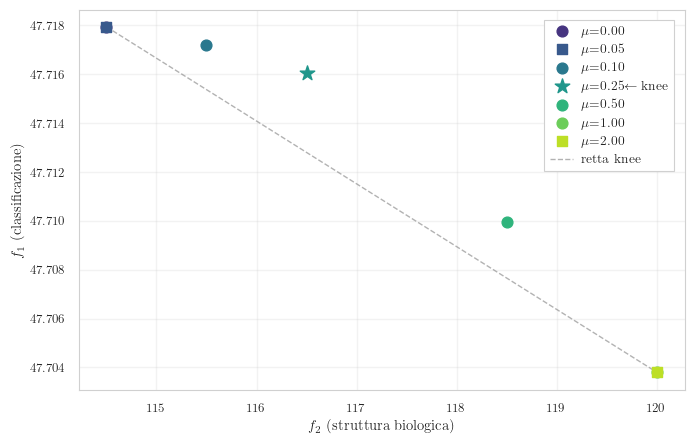

Salvato: knapsack_outputs/knapsack_sweep_diagnostics.pdf


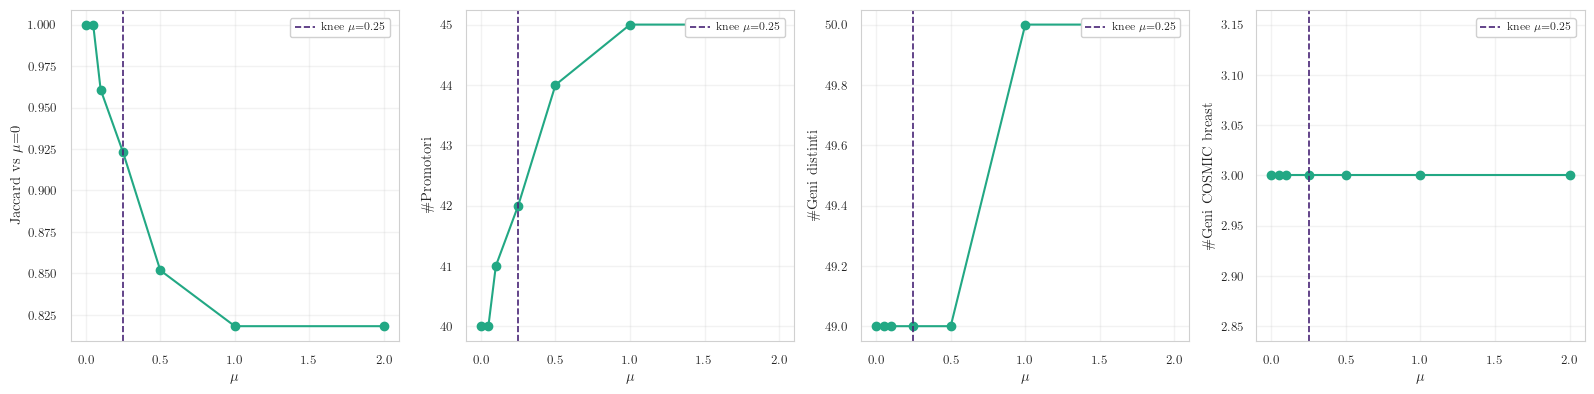

Salvato: knapsack_outputs/knapsack_wcosmic_sweep.pdf


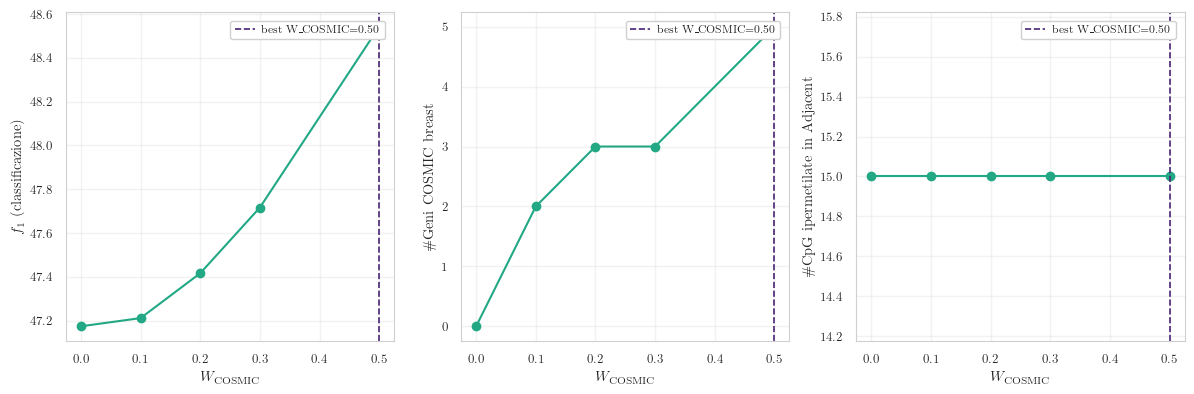

Salvato CSV: knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG finali)

  [Normal vs Adjacent (test)]  n=49 (0=37, 1=12)
  Silhouette    : 0.3816
  AUC CV5       : 1.0000 ± 0.0000
  mean|ΔM|      : 2.4892
  PCA PC1       : 0.473

  [Normal vs Tumor]  n=106 (0=37, 1=69)
  Silhouette    : 0.4203
  AUC CV5       : 1.0000 ± 0.0000
  mean|ΔM|      : 1.9979
  PCA PC1       : 0.389

STEP 16 — Confronto μ=0 vs set finale
                                      μ=0     finale
f1                                47.7179    48.5420
f2                               114.5000   116.5000
n_promoter                             40         42
n_island                               50         50
n_genes                                49         49
n_cosmic                                3          5
n_hyper                                15         15
Jaccard(mu0, finale)               0.8868

OUTPUT FINALE
  selected_cpgs_final : 50 CpG
  knee_mu             : 0.25
  best

In [48]:
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ  [v2]
#
# MODIFICHE rispetto a v1:
#   1) W_COSMIC: prior COSMIC breast cancer nel value di f1
#      v_i = W_COEF*c̃_i + W_DM*d̃_i + W_SCORE*s̃_i + W_COSMIC*is_cosmic_i
#      → sweep secondario su W_COSMIC con μ fissato al knee
#   2) MIN_HYPER: vincolo C8 che impone almeno MIN_HYPER CpG
#      ipERmetilate in Adjacent (coef_SVM > 0)
#   3) EVAL_TUMOR: flag per attivare/disattivare la valutazione
#      Normal vs Tumor (default False: studio è Normal vs Adjacent)
#
# Modello:
#   max  f1(x) + μ * f2_hat(x, y)
#   f1(x)   = Σ v_i * x_i      v_i = W_COEF*c̃ + W_DM*d̃ + W_SCORE*s̃ + W_COSMIC*cosmic_i
#   f2(x,y) = Σ_{i∈P} x_i  +  Σ_{i∈L} x_i  +  η * Σ_g y_g
#   f2_hat  = f2 / (K*(2+η))
#
# Vincoli hard:
#   C1: Σ x_i = K
#   C2: x_i + x_j ≤ 1        ∀ (i,j): |r_ij| ≥ CORR_THR
#   C3: Σ_{chr=c} x_i ≤ CHR_MAX
#   C4: Σ_{i∈A} x_i ≥ K_A*   (adattivo: min(K_A_NOMINAL, |A∩I|))
#   C5: x_i ≤ y_g             ∀ i: gene(i)=g
#   C6: Σ_{gene=g} x_i ≤ 2   ∀ g
#   C7: Σ_g y_g ≥ G_min*      (adattivo: min(G_MIN_NOMINAL, |G|))
#   C8: Σ_{coef>0} x_i ≥ MIN_HYPER   [NUOVO]
#
# Sweep principale: μ ∈ MU_GRID  (con W_COSMIC fissato)
# Sweep secondario: W_COSMIC ∈ W_COSMIC_GRID  (con μ=knee)
#
# Dipendenze nello scope (dal notebook):
#   final_cpgs, cpg_cols_current, M_train, M_test, y_train, y_test
#   step3_stats, cpg_candidates, poolA_cpgs, poolB_cpgs
#   cpg_to_chr, svm_pipe, man (manifest DataFrame già caricato)
#   apply_thesis_style, place_legend  (opzionale, per i plot)
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG — modifica qui
# ─────────────────────────────────────────────────────────────
BETA_PATH     = "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet"
CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

ID_COL        = "id_tissue"
LABEL_COL     = "label"
LABELS_ALL    = [0, 1, 2]           # 0=Normal, 1=Adjacent, 2=Tumor

K             = 50                  # CpG da selezionare
N_POOL        = 5000                # top-N da final_cpgs per |coef|
CHR_MAX       = 10                  # C3: max CpG per cromosoma
CORR_THR      = 0.85                # C2: soglia correlazione conflict edges
ETA           = 0.5                 # peso geni distinti in f2

# Pesi f1 (sommano a 1 senza COSMIC; COSMIC è bonus additivo)
W_COEF        = 0.5                 # peso |coef_SVM|
W_DM          = 0.2                 # peso |ΔM|
W_SCORE       = 0.3                 # peso RSKF score (invertito)

# [NUOVO] Prior COSMIC breast cancer nel value
# Sweep secondario su questo parametro (vedi STEP 10b)
W_COSMIC      = 0.3                 # valore usato nello sweep principale μ
W_COSMIC_GRID = [0.0, 0.1, 0.2, 0.3, 0.5]   # sweep secondario (μ fissato al knee)

# Vincoli
K_A_NOMINAL   = 25                  # C4: min Pool A (adattivo)
G_MIN_NOMINAL = 25                  # C7: min geni distinti (adattivo)
MAX_PER_GENE  = 2                   # C6: max CpG per gene

# [NUOVO] C8: min CpG ipERmetilate in Adjacent (coef_SVM > 0)
# Metti 0 per disattivare
MIN_HYPER     = 15

# Sweep principale μ
MU_GRID       = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

# [NUOVO] Evaluation Normal vs Tumor: False = solo Normal vs Adjacent
EVAL_TUMOR    = True

CBC_TIME_LIMIT = 120               # secondi per ogni solve
EPS_M          = 1e-6
RANDOM_STATE   = 42

OUTDIR = Path("./knapsack_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    """Rank normalizzato [0,1]: valore più alto → rank più alto."""
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, len(v2) - 1)

def rank_norm_desc(v):
    """Rank normalizzato: valore più basso → rank più alto."""
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    """
    Estrae il primo gene dal campo manifest (es. "BRCA1;TP53" → "BRCA1").
    Restituisce None se intergenico o NaN.
    """
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    if ctx is None:
        return False
    s = str(ctx)
    return "Island" in s and "Shore" not in s and "Shelf" not in s

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    """
    Distanza massima dalla retta (μ=0) → (punto con f2 massimo osservato).
    Ignora punti saturati (f2 identico al precedente).
    """
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)

    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0

    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)

    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)

    dists = [
        np.linalg.norm((np.array([f2_n[i], f1_n[i]]) - p0)
                       - np.dot(np.array([f2_n[i], f1_n[i]]) - p0, d_norm) * d_norm)
        for i in range(len(idx_v))
    ]
    return int(idx_v[np.argmax(dists)])

def eval_pair(name, X, ybin):
    """Valuta separazione tra due gruppi sulle CpG selezionate."""
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out

    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")

    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")

    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")

    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None

    return out


# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM dalle final_cpgs
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

cols_all  = np.array(cpg_cols_current, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}
final_arr = np.array(final_cpgs, dtype=object)

raw_coef = np.array(svm_pipe.named_steps['svm'].coef_[0], dtype=float)
assert raw_coef.size == final_arr.size, (
    f"coef size {raw_coef.size} != final_cpgs size {final_arr.size}. "
    "Assicurati che svm_pipe sia fittato su X_train[:, final_cpgs]."
)
coef_final = raw_coef

print(f"final_cpgs        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Carica M_all per evaluation (solo se EVAL_TUMOR=True)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 2 — Caricamento dati{'  [EVAL_TUMOR=True]' if EVAL_TUMOR else '  [solo Normal+Adjacent]'}")
print("=" * 70)

if EVAL_TUMOR:
    beta_all = (
        pl.read_parquet(BETA_PATH)
        .filter(pl.col(LABEL_COL).is_in(LABELS_ALL))
    )
else:
    beta_all = (
        pl.read_parquet(BETA_PATH)
        .filter(pl.col(LABEL_COL).is_in([0, 1]))
    )

y_all  = beta_all.select(LABEL_COL).to_numpy().ravel().astype(int)
id_all = beta_all.select(ID_COL).to_numpy().ravel()

meta_cols_set    = {ID_COL, LABEL_COL}
cpg_cols_parquet = [c for c in beta_all.columns if c not in meta_cols_set]
common           = [c for c in cpg_cols_parquet if c in col_to_j]

M_all_beta   = beta_all.select(common).to_numpy().astype(np.float32)
M_all        = beta_to_m(M_all_beta).astype(np.float32)
col_to_j_all = {c: i for i, c in enumerate(common)}

print(f"M_all shape       : {M_all.shape}")
print(f"y_all distrib     : " + str({int(v): int((y_all == v).sum()) for v in np.unique(y_all)}))

# ─────────────────────────────────────────────────────────────
# STEP 3 — Allinea RSKF score e |ΔM| a final_cpgs
# ─────────────────────────────────────────────────────────────
cand_arr   = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
cand_to_i  = {c: i for i, c in enumerate(cand_arr.tolist())}

score_final = np.array(
    [cand_score[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
absdM_final = np.array(
    [cand_absdM[cand_to_i[c]] if c in cand_to_i else np.nan for c in final_arr],
    dtype=float
)
n_miss = int(np.isnan(score_final).sum())
if n_miss > 0:
    print(f"⚠ {n_miss} CpG non in cpg_candidates — score=nan, penalizzate.")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# rimuovi CpG non in M_train
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    print(f"  ⚠ Rimosse {(~valid_mask).sum()} CpG non in M_train.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B
# ─────────────────────────────────────────────────────────────
_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]

# C4 adattivo
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use={K_A_use} (nominale {K_A_NOMINAL})")
if K_A_use < K_A_NOMINAL:
    print(f"  ⚠ K_A ridotto: solo {len(poolA_in_pool)} CpG Pool A nel pool.")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su M_train)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = M_train[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.3f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici dal manifest
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici + COSMIC prior")
print("=" * 70)

# usa 'man' già caricato nel notebook
man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

chr_arr   = np.array([cpg_to_chr.get(c, "")                         for c in pool_cpgs], dtype=object)
gene_arr  = np.array([parse_first_gene(cpg_gene_dict.get(c, None))  for c in pool_cpgs], dtype=object)
is_prom   = np.array([in_promoter(cpg_feat_dict.get(c, ""))         for c in pool_cpgs], dtype=int)
is_island = np.array([in_island(cpg_island_dict.get(c, ""))         for c in pool_cpgs], dtype=int)

# geni annotati (per C5-C7)
genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})

# C7 adattivo
G_min_use = min(G_MIN_NOMINAL, len(genes_pool))

# ── [NUOVO] Prior COSMIC breast cancer ──────────────────────
cgc = pd.read_csv(CGC_PATH, sep="\t")
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
COSMIC_BREAST_GENES = set(cgc.loc[mask_breast, "GENE_SYMBOL"].astype(str))

is_cosmic = np.array(
    [1.0 if (gene_arr[i] is not None and gene_arr[i] in COSMIC_BREAST_GENES) else 0.0
     for i in range(n_p)],
    dtype=float
)

# ── [NUOVO] Flag ipERmetilazione (coef_SVM > 0 = ipermet. in Adjacent)
is_hyper = np.array([1 if pool_coef[i] > 0 else 0 for i in range(n_p)], dtype=int)

print(f"CpG con promotore : {is_prom.sum()}")
print(f"CpG in island     : {is_island.sum()}")
print(f"Geni distinti pool: {len(genes_pool)}  →  G_min_use={G_min_use} (nominale {G_MIN_NOMINAL})")
print(f"Geni COSMIC breast: {len(COSMIC_BREAST_GENES)}")
print(f"CpG COSMIC nel pool: {int(is_cosmic.sum())}  "
      f"({100*is_cosmic.mean():.1f}% del pool)")
print(f"CpG ipermet. pool : {is_hyper.sum()}  (coef>0)")
print(f"CpG ipomet. pool  : {(1-is_hyper).sum()}  (coef<0)")

if MIN_HYPER > is_hyper.sum():
    print(f"  ⚠ MIN_HYPER={MIN_HYPER} > CpG ipermet. nel pool ({is_hyper.sum()}). "
          f"Abbassa MIN_HYPER o aumenta N_POOL.")

# upper bound deterministico di f2
F2_NORM = float(K * (2 + ETA))

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1 (rank-normalizzata sul pool fisso)
#
# [MODIFICATO] v_i = W_COEF*c̃ + W_DM*d̃ + W_SCORE*s̃ + W_COSMIC*cosmic_i
# I rank sono calcolati sul pool fisso → non confrontabili tra run diverse.
# W_COSMIC è bonus additivo (non entra nella normalizzazione dei pesi).
# ─────────────────────────────────────────────────────────────
def compute_value(w_cosmic):
    r_coef  = rank_norm_asc(np.abs(pool_coef))
    r_dM    = rank_norm_asc(pool_absdM)
    r_score = rank_norm_desc(pool_score)
    return W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score + w_cosmic * is_cosmic

# value per lo sweep principale (W_COSMIC fissato)
value_main = compute_value(W_COSMIC)

print(f"\nf1 value range    : [{value_main.min():.4f}, {value_main.max():.4f}]  (W_COSMIC={W_COSMIC})")
print(f"f2 norm factor    : {F2_NORM:.1f}")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP
# ─────────────────────────────────────────────────────────────
def solve_milp(mu: float, value: np.ndarray, label: str = ""):
    """
    Risolve il MILP per un dato (μ, value).
    Restituisce dict con risultati oppure None se infeasible.
    """
    prob = pulp.LpProblem(f"CpG_Knapsack_{label}_mu{mu:.3f}", pulp.LpMaximize)

    x   = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]
    y_g = {g: pulp.LpVariable(f"yg_{i}", cat="Binary") for i, g in enumerate(genes_pool)}

    # ── Obiettivo ────────────────────────────────────────────
    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat = f2_expr / F2_NORM
    prob  += f1_expr + mu * f2_hat

    # ── C1: cardinalità ──────────────────────────────────────
    prob += pulp.lpSum(x) == K, "C1"

    # ── C2: conflict edges ───────────────────────────────────
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_{idx}"

    # ── C3: max per cromosoma ────────────────────────────────
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch)
            <= CHR_MAX, f"C3_{ch}"
        )

    # ── C4: Pool A min (adattivo) ────────────────────────────
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4"
        )

    # ── C5: link CpG → gene ──────────────────────────────────
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_{i}"

    # ── C6: max CpG per gene ─────────────────────────────────
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if idx_g:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_{g}"

    # ── C7: min geni distinti (adattivo) ─────────────────────
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7"

    # ── C8 [NUOVO]: min CpG ipERmetilate in Adjacent ─────────
    if MIN_HYPER > 0:
        n_hyper_in_pool = int(is_hyper.sum())
        if n_hyper_in_pool >= MIN_HYPER:
            prob += (
                pulp.lpSum(x[i] for i in range(n_p) if is_hyper[i])
                >= MIN_HYPER, "C8_hyper_min"
            )
        else:
            print(f"  ⚠ C8 disattivato: solo {n_hyper_in_pool} CpG ipermet. nel pool < MIN_HYPER={MIN_HYPER}")

    # ── Solve ────────────────────────────────────────────────
    solver     = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status     = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))
    obj_val    = pulp.value(prob.objective)

    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [{label} μ={mu:.3f}] Status={status_str} — INFEASIBLE")
        return None

    sel_idx = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx.size != K:
        print(f"  [{label} μ={mu:.3f}] Selezionato {sel_idx.size}/{K} — SKIP")
        return None

    selected = pool_cpgs[sel_idx].tolist()

    f1_val = float(sum(value[i] for i in sel_idx))
    f2_val = float(
        is_prom[sel_idx].sum()
        + is_island[sel_idx].sum()
        + ETA * len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None})
    )
    f2_hat_val = f2_val / F2_NORM
    n_cosmic   = int(is_cosmic[sel_idx].sum())
    n_hyper_sel= int(is_hyper[sel_idx].sum())

    return {
        "status":      status_str,
        "f1":          f1_val,
        "f2":          f2_val,
        "f2_hat":      f2_hat_val,
        "n_promoter":  int(is_prom[sel_idx].sum()),
        "n_island":    int(is_island[sel_idx].sum()),
        "n_genes":     len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None}),
        "n_cosmic":    n_cosmic,
        "n_hyper":     n_hyper_sel,
        "n_hypo":      K - n_hyper_sel,
        "selected":    selected,
        "sel_idx":     sel_idx,
    }


# ─────────────────────────────────────────────────────────────
# STEP 10a — Sweep principale su μ (W_COSMIC fissato)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10a — Sweep μ  (W_COSMIC={W_COSMIC} fissato)")
print("=" * 70)

sweep_results = []
sel_mu0       = None

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving...")
    res = solve_milp(mu, value_main, label="main")
    if res is None:
        sweep_results.append({"mu": mu, "f1": np.nan, "f2": np.nan,
                               "f2_hat": np.nan, "status": "FAILED",
                               "jaccard_vs_0": np.nan, "saturated": False,
                               "n_promoter": np.nan, "n_island": np.nan,
                               "n_genes": np.nan, "n_cosmic": np.nan,
                               "n_hyper": np.nan, "selected": []})
        continue

    if mu == 0.0:
        sel_mu0 = res["selected"]

    jacc = jaccard(res["selected"], sel_mu0) if sel_mu0 else 1.0
    delta = (mu * res["f2_hat"]) / max(res["f1"], 1e-12)

    sat = (len(sweep_results) > 0
           and not np.isnan(sweep_results[-1].get("f2", np.nan))
           and res["f2"] == sweep_results[-1]["f2"])

    row = {"mu": mu, **res, "jaccard_vs_0": jacc, "delta": delta, "saturated": sat}
    sweep_results.append(row)

    print(f"  Status     : {res['status']}")
    print(f"  f1         : {res['f1']:.4f}")
    print(f"  f2         : {res['f2']:.4f}  (f2_hat={res['f2_hat']:.4f})")
    print(f"  Δ(bio/clf) : {delta:.4f}")
    print(f"  Jaccard(0) : {jacc:.4f}")
    print(f"  Promotori  : {res['n_promoter']}  |  Islands: {res['n_island']}  |  Geni: {res['n_genes']}")
    print(f"  COSMIC     : {res['n_cosmic']}  |  Ipermet: {res['n_hyper']}  |  Ipomet: {res['n_hypo']}")
    print(f"  Saturato   : {sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Selezione knee
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]

k_idx    = knee_index(f1_vals, f2_vals)
knee_res = valid_res[k_idx]
knee_mu  = knee_res["mu"]

print(f"Knee selezionato  : μ = {knee_mu:.3f}")
print(f"  f1              : {knee_res['f1']:.4f}")
print(f"  f2              : {knee_res['f2']:.4f}  (f2_hat={knee_res['f2_hat']:.4f})")
print(f"  Jaccard vs μ=0  : {knee_res['jaccard_vs_0']:.4f}")
print(f"  Promotori       : {knee_res['n_promoter']}")
print(f"  Islands         : {knee_res['n_island']}")
print(f"  Geni distinti   : {knee_res['n_genes']}")
print(f"  COSMIC breast   : {knee_res['n_cosmic']}")
print(f"  Ipermet./Ipomet.: {knee_res['n_hyper']} / {knee_res['n_hypo']}")

selected_cpgs_final = knee_res["selected"]
print(f"\nSet provvisorio (knee, sweep μ): {len(selected_cpgs_final)} CpG")

# ─────────────────────────────────────────────────────────────
# STEP 10b — Sweep secondario su W_COSMIC (μ fissato al knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10b — Sweep W_COSMIC  (μ={knee_mu} fissato)")
print("=" * 70)

cosmic_sweep_results = []

for wc in W_COSMIC_GRID:
    print(f"\n[W_COSMIC={wc:.2f}] Solving...")
    val_wc = compute_value(wc)
    res    = solve_milp(knee_mu, val_wc, label=f"cosmic{wc:.2f}")
    if res is None:
        cosmic_sweep_results.append({
            "w_cosmic": wc, "f1": np.nan, "f2": np.nan,
            "n_cosmic": np.nan, "n_hyper": np.nan, "status": "FAILED", "selected": []
        })
        continue

    jacc_vs_wc0 = jaccard(res["selected"],
                          next((r["selected"] for r in cosmic_sweep_results
                                if r.get("w_cosmic") == 0.0 and r["selected"]), []))

    row = {"w_cosmic": wc, **res, "jaccard_vs_wc0": jacc_vs_wc0}
    cosmic_sweep_results.append(row)

    print(f"  f1         : {res['f1']:.4f}")
    print(f"  f2         : {res['f2']:.4f}")
    print(f"  COSMIC     : {res['n_cosmic']}  |  Ipermet: {res['n_hyper']}  |  Ipomet: {res['n_hypo']}")
    print(f"  Jaccard(wc=0): {jacc_vs_wc0:.4f}")

# Scegli W_COSMIC migliore: massimo n_cosmic a parità di f1 ≥ f1(wc=0)*0.999
wc_valid = [r for r in cosmic_sweep_results if not np.isnan(r.get("f1", np.nan))]
if wc_valid:
    f1_wc0 = next((r["f1"] for r in wc_valid if r["w_cosmic"] == 0.0), wc_valid[0]["f1"])
    candidates_wc = [r for r in wc_valid if r["f1"] >= f1_wc0 * 0.999]
    best_wc_res   = max(candidates_wc, key=lambda r: r["n_cosmic"]) if candidates_wc else wc_valid[-1]
    best_w_cosmic = best_wc_res["w_cosmic"]
    selected_cpgs_final = best_wc_res["selected"]

    print(f"\nW_COSMIC ottimale : {best_w_cosmic:.2f}")
    print(f"  COSMIC breast   : {best_wc_res['n_cosmic']}")
    print(f"  f1              : {best_wc_res['f1']:.4f}  (perdita vs wc=0: "
          f"{100*(f1_wc0 - best_wc_res['f1'])/max(f1_wc0,1e-12):.3f}%)")
    print(f"\nSet finale (knee + best W_COSMIC): {len(selected_cpgs_final)} CpG")
else:
    best_w_cosmic = W_COSMIC
    print("⚠ Sweep W_COSMIC fallito — uso il set del knee μ.")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Plot curva di trade-off (sweep μ)
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = cmap(np.linspace(0.15, 0.9, len(valid_res)))

for r, col in zip(valid_res, colors):
    marker = "*" if r["mu"] == knee_mu else ("s" if r.get("saturated") else "o")
    size   = 120 if r["mu"] == knee_mu else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=f"$\mu$={r['mu']:.2f}" + ("$\leftarrow $ knee" if r["mu"] == knee_mu else ""))

p0 = np.array([f2_vals[0],  f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", linewidth=1.0, alpha=0.6, label="retta knee")

ax.set_xlabel(r"$f_2$ (struttura biologica)")
ax.set_ylabel(r"$f_1$ (classificazione)")
try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_tradeoff_curve.pdf", dpi=300, bbox_inches="tight")
print(f"\nSalvato: {OUTDIR}/knapsack_tradeoff_curve.pdf")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — Plot diagnostiche sweep μ
# ─────────────────────────────────────────────────────────────
mu_ax = [r["mu"] for r in valid_res]

fig2, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax_i, (key, label) in zip(axes, [
    ("jaccard_vs_0", "Jaccard vs $\mu$=0"),
    ("n_promoter",   "\#Promotori"),
    ("n_genes",      "\#Geni distinti"),
    ("n_cosmic",     "\#Geni COSMIC breast"),   # [NUOVO]
]):
    vals = [r[key] for r in valid_res]
    ax_i.plot(mu_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
    ax_i.axvline(knee_mu, linestyle="--", color=cmap(0.1), linewidth=1.2,
                 label=f"knee $\mu$={knee_mu}")
    ax_i.set_xlabel(r"$\mu$")
    ax_i.set_ylabel(label)
    ax_i.legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(OUTDIR / "knapsack_sweep_diagnostics.pdf", dpi=300, bbox_inches="tight")
print(f"Salvato: {OUTDIR}/knapsack_sweep_diagnostics.pdf")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13b — Plot sweep W_COSMIC  [NUOVO]
# ─────────────────────────────────────────────────────────────
if len(wc_valid) >= 2:
    fig3, axes3 = plt.subplots(1, 3, figsize=(12, 4))
    wc_ax = [r["w_cosmic"] for r in wc_valid]

    for ax_i, (key, label) in zip(axes3, [
        ("f1",       "$f_1$ (classificazione)"),
        ("n_cosmic", "\#Geni COSMIC breast"),
        ("n_hyper",  "\#CpG ipermetilate in Adjacent"),
    ]):
        vals = [r[key] for r in wc_valid]
        ax_i.plot(wc_ax, vals, marker="o", color=cmap(0.6), linewidth=1.5)
        ax_i.axvline(best_w_cosmic, linestyle="--", color=cmap(0.1), linewidth=1.2,
                     label=f"best W_COSMIC={best_w_cosmic:.2f}")
        ax_i.set_xlabel(r"$W_{\rm COSMIC}$")
        ax_i.set_ylabel(label)
        ax_i.legend(fontsize=8)

    fig3.tight_layout()
    fig3.savefig(OUTDIR / "knapsack_wcosmic_sweep.pdf", dpi=300, bbox_inches="tight")
    print(f"Salvato: {OUTDIR}/knapsack_wcosmic_sweep.pdf")
    plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva CSV summary sweep μ
# ─────────────────────────────────────────────────────────────
csv_path = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes",
              "n_cosmic", "n_hyper", "n_hypo", "saturated"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})

print(f"Salvato CSV: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Valutazione separazione sulle 50 CpG finali
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG finali)")
print("=" * 70)

jj_test = np.array([col_to_j[c]     for c in selected_cpgs_final if c in col_to_j],     dtype=int)
jj_eval = np.array([col_to_j_all[c] for c in selected_cpgs_final if c in col_to_j_all], dtype=int)

eval_results_final = {}

# Normal vs Adjacent — solo test set (no leakage)
mask_na = np.isin(y_test, [0, 1])
X_na    = M_test[mask_na][:, jj_test]
y_na    = (y_test[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair("Normal vs Adjacent (test)", X_na, y_na)

# Normal vs Tumor — opzionale
if EVAL_TUMOR:
    mask_tum     = (y_all == 2)
    mask_norm_te = (y_test == 0)
    if mask_tum.sum() > 0:
        X_tum  = M_all[mask_tum][:, jj_eval]
        X_norm = M_test[mask_norm_te][:, jj_test]
        X_nt   = np.vstack([X_norm, X_tum])
        y_nt   = np.array([0] * X_norm.shape[0] + [1] * X_tum.shape[0], dtype=int)
        eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)
    else:
        print("  [Normal vs Tumor] Nessun campione Tumor nel parquet caricato.")

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs finale
# ─────────────────────────────────────────────────────────────
res_mu0 = next((r for r in valid_res if r["mu"] == 0.0), None)
if res_mu0 and sel_mu0:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 vs set finale")
    print("=" * 70)

    fin = best_wc_res if wc_valid else knee_res
    print(f"{'':30s} {'μ=0':>10s} {'finale':>10s}")
    print(f"{'f1':30s} {res_mu0['f1']:>10.4f} {fin['f1']:>10.4f}")
    print(f"{'f2':30s} {res_mu0['f2']:>10.4f} {fin['f2']:>10.4f}")
    print(f"{'n_promoter':30s} {res_mu0['n_promoter']:>10} {fin['n_promoter']:>10}")
    print(f"{'n_island':30s} {res_mu0['n_island']:>10} {fin['n_island']:>10}")
    print(f"{'n_genes':30s} {res_mu0['n_genes']:>10} {fin['n_genes']:>10}")
    print(f"{'n_cosmic':30s} {res_mu0['n_cosmic']:>10} {fin['n_cosmic']:>10}")
    print(f"{'n_hyper':30s} {res_mu0['n_hyper']:>10} {fin['n_hyper']:>10}")
    print(f"{'Jaccard(mu0, finale)':30s} {jaccard(sel_mu0, selected_cpgs_final):>10.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final : {len(selected_cpgs_final)} CpG")
print(f"  knee_mu             : {knee_mu}")
print(f"  best_w_cosmic       : {best_w_cosmic}")
print(f"  sweep_results       : lista sweep μ")
print(f"  cosmic_sweep_results: lista sweep W_COSMIC")
print(f"  eval_results_final  : metriche separazione")
print(f"  OUTDIR              : {OUTDIR}")
print("=" * 70)

# dopo run con W_COSMIC=best
selected_cpgs_with_cosmic = selected_cpgs_final.copy()

In [49]:
import pandas as pd
from pathlib import Path

# --- PATH ---
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Manifest EPIC (se sei su EPIC). Se stai su 450K, cambia manifest.
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- INPUT: 50 CpG dalla FS ---
selected_cpgs = [str(x) for x in list(selected_cpgs_final )]
print(f"Selected CpG: {len(selected_cpgs)}")

# --- LOAD COSMIC ---
cgc = pd.read_csv(CGC_PATH, sep="\t")

# --- FILTER BREAST (SOMATIC) ---
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast].copy()
genes_cgc_breast = set(cgc_breast["GENE_SYMBOL"].astype(str))

print(f"Geni COSMIC breast: {len(genes_cgc_breast)}")

# ============================================================
# CpG -> GENE(S) dal manifest
# ============================================================

def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    # trova header vero (riga che contiene IlmnID)
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

# colonne standard EPIC: IlmnID e UCSC_RefGene_Name
if "IlmnID" not in man.columns:
    raise ValueError(f"Colonna IlmnID non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")
if "UCSC_RefGene_Name" not in man.columns:
    raise ValueError(f"Colonna UCSC_RefGene_Name non trovata. Colonne disponibili: {man.columns.tolist()[:40]}")

# subset alle 50 CpG
m50 = man.loc[man["IlmnID"].isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
missing = sorted(set(selected_cpgs) - set(m50["IlmnID"].astype(str)))
print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs)}")
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest: {len(missing)} (mostro max 15): {missing[:15]}")
    print("Se sono tante, stai usando il manifest sbagliato (EPIC vs 450K).")

# explode geni (campo separato da ';')
m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].astype(str).str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni associati alle 50 CpG (unique): {len(genes_50)}")

# salva mapping CpG->gene
m50.rename(columns={"IlmnID": "CpG"}).to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# ============================================================
# INTERSECTION: (GENES from 50 CpGs) ∩ (COSMIC breast)
# ============================================================

genes_overlap = sorted(genes_50 & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# --- TABELLINA FINALE (gene-level, come il tuo) ---
table = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]
    .drop_duplicates()
    .sort_values("GENE_SYMBOL")
)

display(table)

# opzionale: salva
table.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg.tsv'}")


Selected CpG: 50
Geni COSMIC breast: 44
CpG trovate nel manifest: 50 / 50
Geni associati alle 50 CpG (unique): 59
Saved: post_fs_annotation/cpg50_to_genes.tsv
Geni in comune (genes_50CpG ∩ COSMIC breast): 5


,GENE_SYMBOL,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
15,AKT1,oncogene,1,"breast, colorectal, ovarian, NSCLC"
217,ESR1,"oncogene, TSG, fusion",1,breast
280,GATA3,"oncogene, TSG",1,breast
579,RB1,TSG,1,"retinoblastoma, sarcoma, breast, small cell lu..."
681,TBX3,"oncogene, TSG",1,"breast, large intestine, skin"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg.tsv


In [50]:
# ============================================================
# ANNOTAZIONE 50 CpG — cella unica
# Richiede nello scope:
#   - selected_cpgs   : list di 50 CpG
#   - final_cpgs      : array 5000 CpG
#   - final_arr       : np.array delle 5000 CpG (allineato a coef_final)
#   - coef_final      : np.array dei coef SVM (allineato a final_arr)
#   - man             : DataFrame manifest già caricato
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

selected_cpgs_list = [str(x) for x in list(selected_cpgs_final )]
coef_map = dict(zip(final_arr.tolist(), coef_final.tolist()))

# ── 1. CpG -> gene dal manifest ──
m50 = man.loc[
    man["IlmnID"].isin(selected_cpgs_list),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

print(f"CpG trovate nel manifest: {m50['IlmnID'].nunique()} / {len(selected_cpgs_list)}")
missing = set(selected_cpgs_list) - set(m50["IlmnID"].astype(str))
if missing:
    print(f"CpG NON trovate ({len(missing)}): {list(missing)[:10]}")
    print("Se sono molte -> manifest sbagliato (450K su dati EPIC)")

m50["UCSC_RefGene_Name"] = m50["UCSC_RefGene_Name"].fillna("").astype(str)
m50["GENE_SYMBOL"] = m50["UCSC_RefGene_Name"].str.split(";")
m50 = m50.explode("GENE_SYMBOL")
m50["GENE_SYMBOL"] = m50["GENE_SYMBOL"].str.strip()
m50 = m50[m50["GENE_SYMBOL"] != ""].drop_duplicates()
m50 = m50.rename(columns={"IlmnID": "CpG"})
m50["coef_svm"]  = m50["CpG"].map(coef_map)
m50["direction"] = m50["coef_svm"].apply(
    lambda x: "hypermethylated_in_adj" if (x is not None and x > 0)
              else "hypomethylated_in_adj" if (x is not None and x < 0)
              else "unknown"
)

genes_50 = set(m50["GENE_SYMBOL"].astype(str))
print(f"Geni unici associati alle 50 CpG: {len(genes_50)}")

# ── 2. Overlap con geni noti nel field cancerization ──
known_field_genes = {
    # lista originale
    'RASSF1', 'CDH1', 'APC', 'BRCA1', 'BRCA2',
    'CDKN2A', 'MLH1', 'GSTP1', 'DAPK1', 'RUNX3',
    'SFRP1', 'SFRP2', 'SFRP4', 'SFRP5', 'WIF1', 'DKK1', 'DKK3',
    'HOXA5', 'HOXA9', 'HOXA10', 'HOXB13',
    'TBX2', 'TBX3', 'TBX5',
    'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
    'SLIT2', 'ROBO1', 'PCDH10', 'NDRG2',
    # aggiunte dai risultati
    'YAP1', 'KMT2A', 'XPC',        # dataset 2
    'DAB2IP', 'CCND2', 'RBPJ',     # dataset 3
    'DACT2', 'SMPD3',
}

hits = genes_50 & known_field_genes
print(f"\nGeni noti nel field cancerization: {len(hits)}")
if hits:
    print(f"  {sorted(hits)}")
    hits_df = m50[m50["GENE_SYMBOL"].isin(hits)][
        ["CpG", "GENE_SYMBOL", "direction", "coef_svm"]
    ].drop_duplicates().sort_values("GENE_SYMBOL")
    print(hits_df.to_string(index=False))
else:
    print("  Nessun gene noto trovato.")

# ── 3. Tabella completa per tesi ──
table_full = (
    m50[["CpG", "GENE_SYMBOL", "direction", "coef_svm"]]
    .drop_duplicates()
    .sort_values(["direction", "coef_svm"], ascending=[True, False])
)
print(f"\nTabella completa ({len(table_full)} righe):")
print(table_full.to_string(index=False))
table_full.to_csv(OUTDIR / "50cpg_annotated.tsv", sep="\t", index=False)
print(f"\nSalvato: {OUTDIR / '50cpg_annotated.tsv'}")

# ── 4. Sommario direzioni ──
n_hyper = (m50["direction"] == "hypermethylated_in_adj").sum()
n_hypo  = (m50["direction"] == "hypomethylated_in_adj").sum()
print(f"\nHypermethylated in Adjacent : {n_hyper}")
print(f"Hypomethylated in Adjacent  : {n_hypo}")

CpG trovate nel manifest: 50 / 50
Geni unici associati alle 50 CpG: 59

Geni noti nel field cancerization: 1
  ['TBX3']
       CpG GENE_SYMBOL             direction  coef_svm
cg22635491        TBX3 hypomethylated_in_adj -0.002026

Tabella completa (59 righe):
       CpG  GENE_SYMBOL              direction  coef_svm
cg18558388       SAP30L hypermethylated_in_adj  0.003192
cg18558388   SAP30L-AS1 hypermethylated_in_adj  0.003192
cg26870803           PC hypermethylated_in_adj  0.002578
cg26870803        LRFN4 hypermethylated_in_adj  0.002578
cg03338924      PHACTR1 hypermethylated_in_adj  0.002053
cg00804091         EMC8 hypermethylated_in_adj  0.001999
cg00804091       COX4I1 hypermethylated_in_adj  0.001999
cg20120430        MYST4 hypermethylated_in_adj  0.001979
cg04018448      CASKIN1 hypermethylated_in_adj  0.001855
cg21691809         CLGN hypermethylated_in_adj  0.001754
cg14392066        TOR2A hypermethylated_in_adj  0.001594
cg16120460        RASA3 hypermethylated_in_adj  0.001435

In [51]:
print("working")

working


In [52]:
# ============================================================
# ANALISI DIFFERENZIALE: CpG selezionate CON vs SENZA prior COSMIC
#
# Prerequisiti nello scope:
#   selected_cpgs_no_cosmic  : lista 50 CpG dal MILP con W_COSMIC=0
#   selected_cpgs_with_cosmic: lista 50 CpG dal MILP con W_COSMIC>0
#   man                      : manifest DataFrame già caricato
#   coef_final               : coef SVM allineati a final_arr
#   final_arr                : np.ndarray final_cpgs
#   pool_cpgs, pool_absdM    : dal knapsack
#   M_test, y_test           : matrici test
#   col_to_j                 : dict CpG -> indice colonna in M_train/M_test
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from pathlib import Path

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ── STEP 0: rinomina i tuoi due set se non l'hai già fatto ──
# Dopo aver runnato il MILP con W_COSMIC=0.0, salva:
#   selected_cpgs_no_cosmic = selected_cpgs_final.copy()
# Dopo aver runnato con W_COSMIC=best, salva:
#   selected_cpgs_with_cosmic = selected_cpgs_final.copy()

set_no  = set(selected_cpgs_no_cosmic)
set_wc  = set(selected_cpgs_with_cosmic)

# ── STEP 1: insiemi ──
common       = set_no & set_wc          # CpG presenti in entrambi
only_no_cos  = set_no - set_wc          # CpG solo nel set senza COSMIC
                                        # → queste migliorano norm-adj
only_with_cos = set_wc - set_no         # CpG solo nel set con COSMIC
                                        # → queste migliorano norm-tum

print("=" * 60)
print("ANALISI DIFFERENZIALE CON vs SENZA prior COSMIC")
print("=" * 60)
print(f"CpG in comune          : {len(common)}")
print(f"Solo senza COSMIC      : {len(only_no_cos)}  ← migliorano norm-adj")
print(f"Solo con COSMIC        : {len(only_with_cos)} ← migliorano norm-tum")

# ── STEP 2: annota i due set differenziali con il manifest ──
def annotate_cpgs(cpg_list, man, coef_final, final_arr, pool_cpgs, pool_absdM):
    """Annota una lista di CpG con gene, direzione, coef, |ΔM|."""
    man_sub = man.copy()
    man_sub["IlmnID"] = man_sub["IlmnID"].astype(str).str.strip()
    man_sub = man_sub.set_index("IlmnID")

    final_arr = np.array(final_arr, dtype=object)
    coef_map  = {c: coef_final[i] for i, c in enumerate(final_arr)}

    pool_arr  = np.array(pool_cpgs, dtype=object)
    absdm_map = {c: pool_absdM[i] for i, c in enumerate(pool_arr)}

    rows = []
    for cpg in sorted(cpg_list):
        coef = coef_map.get(cpg, np.nan)
        absdm = absdm_map.get(cpg, np.nan)
        direction = ("hypermethylated_in_adj" if coef > 0
                     else "hypomethylated_in_adj" if coef < 0
                     else "unknown")
        genes = ""
        if cpg in man_sub.index:
            genes = str(man_sub.loc[cpg, "UCSC_RefGene_Name"]).strip()
            if genes.lower() == "nan":
                genes = ""
        rows.append({
            "CpG": cpg,
            "gene": genes,
            "direction": direction,
            "coef_svm": round(coef, 6),
            "abs_dM": round(absdm, 4) if not np.isnan(absdm) else np.nan,
        })
    return pd.DataFrame(rows)

df_only_no  = annotate_cpgs(only_no_cos,  man, coef_final, final_arr, pool_cpgs, pool_absdM)
df_only_wc  = annotate_cpgs(only_with_cos, man, coef_final, final_arr, pool_cpgs, pool_absdM)
df_common   = annotate_cpgs(common,        man, coef_final, final_arr, pool_cpgs, pool_absdM)

print(f"\n── CpG SOLO nel set senza COSMIC (migliorano norm-adj) ──")
print(df_only_no.to_string(index=False))

print(f"\n── CpG SOLO nel set con COSMIC (migliorano norm-tum) ──")
print(df_only_wc.to_string(index=False))

# ── STEP 3: valutazione AUC incrementale ──
# Domanda: le CpG "only_no_cos" da sole quanto AUC danno su norm-adj?
# Le CpG "only_with_cos" da sole quanto AUC danno su norm-tum?

def auc_subset(cpg_list, M_test, y_test, col_to_j, label_pair=(0,1)):
    """AUC con CV su un sottoinsieme di CpG su una coppia di label."""
    cpgs_valid = [c for c in cpg_list if c in col_to_j]
    if len(cpgs_valid) < 3:
        print(f"  Troppo poche CpG valide ({len(cpgs_valid)}) — skip")
        return None
    jj = np.array([col_to_j[c] for c in cpgs_valid], dtype=int)
    mask = np.isin(y_test, list(label_pair))
    X = M_test[mask][:, jj]
    y = (y_test[mask] == label_pair[1]).astype(int)
    if y.sum() == 0 or (y==0).sum() == 0:
        return None
    Xsc = StandardScaler().fit_transform(X)
    lr  = LogisticRegression(C=1.0, class_weight="balanced",
                             max_iter=1000, random_state=42)
    n_cv = min(5, int(y.sum()), int((y==0).sum()))
    if n_cv < 2:
        return None
    aucs = cross_val_score(lr, Xsc, y, cv=n_cv, scoring="roc_auc")
    return float(aucs.mean()), float(aucs.std()), len(cpgs_valid)

print("\n" + "=" * 60)
print("AUC INCREMENTALE per sottoinsieme")
print("=" * 60)

# CpG "solo no cosmic" su norm-adj
res = auc_subset(list(only_no_cos), M_test, y_test, col_to_j, label_pair=(0,1))
if res:
    print(f"CpG solo-no-COSMIC ({res[2]} CpG) → AUC norm-adj: {res[0]:.4f} ± {res[1]:.4f}")

# CpG "solo with cosmic" su norm-adj
res = auc_subset(list(only_with_cos), M_test, y_test, col_to_j, label_pair=(0,1))
if res:
    print(f"CpG solo-con-COSMIC ({res[2]} CpG) → AUC norm-adj: {res[0]:.4f} ± {res[1]:.4f}")

# CpG "solo no cosmic" su norm-tum (richiede M_all, y_all)
if "M_all" in globals() and "y_all" in globals():
    col_to_j_all = {c: i for i, c in enumerate([
        c for c in globals().get("common_cols", [])
    ])} if "common_cols" in globals() else col_to_j

    # norm dal test set + tum da M_all
    mask_tum  = (y_all == 2)
    mask_norm = (y_test == 0)
    X_norm = M_test[mask_norm]
    X_tum  = M_all[mask_tum]

    def auc_nt_subset(cpg_list, X_norm, X_tum, col_to_j, col_to_j_all):
        cpgs_n = [c for c in cpg_list if c in col_to_j]
        cpgs_t = [c for c in cpg_list if c in col_to_j_all]
        common_c = [c for c in cpgs_n if c in set(cpgs_t)]
        if len(common_c) < 3:
            return None
        jj_n = np.array([col_to_j[c] for c in common_c], dtype=int)
        jj_t = np.array([col_to_j_all[c] for c in common_c], dtype=int)
        X = np.vstack([X_norm[:, jj_n], X_tum[:, jj_t]])
        y = np.array([0]*X_norm.shape[0] + [1]*X_tum.shape[0])
        Xsc = StandardScaler().fit_transform(X)
        lr  = LogisticRegression(C=1.0, class_weight="balanced",
                                 max_iter=1000, random_state=42)
        n_cv = min(5, int((y==0).sum()), int((y==1).sum()))
        if n_cv < 2:
            return None
        aucs = cross_val_score(lr, Xsc, y, cv=n_cv, scoring="roc_auc")
        return float(aucs.mean()), float(aucs.std()), len(common_c)

    res = auc_nt_subset(list(only_no_cos), X_norm, X_tum, col_to_j, col_to_j_all)
    if res:
        print(f"CpG solo-no-COSMIC ({res[2]} CpG) → AUC norm-tum: {res[0]:.4f} ± {res[1]:.4f}")

    res = auc_nt_subset(list(only_with_cos), X_norm, X_tum, col_to_j, col_to_j_all)
    if res:
        print(f"CpG solo-con-COSMIC ({res[2]} CpG) → AUC norm-tum: {res[0]:.4f} ± {res[1]:.4f}")

# ── STEP 4: salva tabelle ──
df_only_no.to_csv(OUTDIR / "cpg_only_no_cosmic.tsv", sep="\t", index=False)
df_only_wc.to_csv(OUTDIR / "cpg_only_with_cosmic.tsv", sep="\t", index=False)
df_common.to_csv(OUTDIR / "cpg_common_both.tsv", sep="\t", index=False)

print(f"\nSalvati in {OUTDIR}:")
print("  cpg_only_no_cosmic.tsv   ← CpG che migliorano norm-adj")
print("  cpg_only_with_cosmic.tsv ← CpG che migliorano norm-tum")
print("  cpg_common_both.tsv      ← CpG stabili in entrambi i set")

ANALISI DIFFERENZIALE CON vs SENZA prior COSMIC
CpG in comune          : 35
Solo senza COSMIC      : 15  ← migliorano norm-adj
Solo con COSMIC        : 15 ← migliorano norm-tum

── CpG SOLO nel set senza COSMIC (migliorano norm-adj) ──
       CpG                                              gene             direction  coef_svm  abs_dM
cg00026472                           TSPAN17;TSPAN17;TSPAN17 hypomethylated_in_adj -0.001880  1.4120
cg00088264 NCALD;NCALD;NCALD;NCALD;NCALD;NCALD;MIR5680;NCALD hypomethylated_in_adj -0.001790  1.6604
cg02816447                                     FAM64A;FAM64A hypomethylated_in_adj -0.001723  1.9515
cg06425240             NEBL-AS1;NEBL;NEBL;NEBL;NEBL;NEBL-AS1 hypomethylated_in_adj -0.001721  1.2621
cg07095230                                              TBX2 hypomethylated_in_adj -0.002098  1.3939
cg08265551        CDC42SE1;CDC42SE1;CDC42SE1;MLLT11;CDC42SE1 hypomethylated_in_adj -0.001797  2.5098
cg11774413                                             CL

In [53]:
print("working")

working


In [54]:
# ============================================================
# Compact gene-level table with list of CpGs per gene
# ============================================================

# aggregate CpGs per gene
cpgs_per_gene = (
    m50.rename(columns={"IlmnID": "CpG"})[["CpG", "GENE_SYMBOL"]]
    .drop_duplicates()
    .groupby("GENE_SYMBOL")["CpG"]
    .apply(lambda s: ";".join(sorted(set(s.astype(str)))))
    .reset_index()
    .rename(columns={"CpG": "CPGs"})
)

# overlap genes
genes_overlap = sorted(set(cpgs_per_gene["GENE_SYMBOL"]) & genes_cgc_breast)
print(f"Geni in comune (genes_50CpG ∩ COSMIC breast): {len(genes_overlap)}")

# cosmic info
cgc_cols = ["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]
cgc_info = (
    cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
    [cgc_cols]
    .drop_duplicates()
)

# join gene-level info + CpGs list
table_gene = (
    cgc_info.merge(cpgs_per_gene, on="GENE_SYMBOL", how="left")
    .sort_values("GENE_SYMBOL")
    .reset_index(drop=True)
)

# reorder columns (CpGs near gene symbol)
table_gene = table_gene[["GENE_SYMBOL", "CPGs", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]

display(table_gene)

table_gene.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_50cpg_withCPGs.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_50cpg_withCPGs.tsv'}")

Geni in comune (genes_50CpG ∩ COSMIC breast): 5


,GENE_SYMBOL,CPGs,ROLE_IN_CANCER,TIER,TUMOUR_TYPES_SOMATIC
0,AKT1,cg15957959,oncogene,1,"breast, colorectal, ovarian, NSCLC"
1,ESR1,cg00920970,"oncogene, TSG, fusion",1,breast
2,GATA3,cg15267232,"oncogene, TSG",1,breast
3,RB1,cg18481241,TSG,1,"retinoblastoma, sarcoma, breast, small cell lu..."
4,TBX3,cg22635491,"oncogene, TSG",1,"breast, large intestine, skin"


Saved: post_fs_annotation/genes_overlap_COSMIC_breast_from_50cpg_withCPGs.tsv


In [55]:
# EXPORT selected_cpgs_with_cosmic -> CSV

import pandas as pd

# selected_cpgs_with_cosmic può essere: DataFrame / list[dict] / list / dict
obj = selected_cpgs_with_cosmic

if isinstance(obj, pd.DataFrame):
    df = obj.copy()

elif isinstance(obj, dict):
    # dict of columns or dict of records
    try:
        df = pd.DataFrame(obj)
    except ValueError:
        df = pd.DataFrame.from_dict(obj, orient="index").reset_index()

else:
    # list, np array, polars DF, ecc.
    try:
        df = pd.DataFrame(obj)
    except Exception as e:
        raise TypeError(f"Impossibile convertire selected_cpgs_with_cosmic in DataFrame: {type(obj)}") from e

# (opzionale) se hai colonne miste e vuoi una colonna 'cpg' come prima colonna
for c in ["cpg", "CpG", "cpg_id", "probe", "probe_id"]:
    if c in df.columns and c != df.columns[0]:
        cols = [c] + [x for x in df.columns if x != c]
        df = df[cols]
        break

out_path = "selected_cpgs_with_cosmic.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path, "| shape:", df.shape)

Saved: selected_cpgs_with_cosmic.csv | shape: (50, 1)


In [56]:
# ============================================================
# CpG LIST -> (1) geni associati via manifest + (2) check COSMIC breast overlap
# Richiede nello scope:
#   - LIST : lista CpG da controllare
#   - man  : manifest DataFrame con colonne IlmnID, UCSC_RefGene_Name
#   - cgc_breast + genes_cgc_breast : già calcolati (COSMIC filtrato per breast somatic)
#   - OUTDIR : Path (opzionale, altrimenti lo crea)
# ============================================================

import pandas as pd
from pathlib import Path

LIST = ["cg06710937", "cg07155318", "cg12615761", "cg13546935", "cg16374663", "cg26307359"]

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) CpG -> gene(s) dal manifest
# -----------------------------
need_cols = {"IlmnID", "UCSC_RefGene_Name"}
if not need_cols.issubset(set(man.columns)):
    raise ValueError(f"Manifest 'man' deve contenere {need_cols}. Colonne disponibili: {man.columns.tolist()[:40]}")

m_list = man.loc[
    man["IlmnID"].astype(str).isin([str(x) for x in LIST]),
    ["IlmnID", "UCSC_RefGene_Name"]
].copy()

m_list["IlmnID"] = m_list["IlmnID"].astype(str)
print(f"CpG trovate nel manifest: {m_list['IlmnID'].nunique()} / {len(LIST)}")

missing = sorted(set(LIST) - set(m_list["IlmnID"]))
if missing:
    print(f"ATTENZIONE: CpG mancanti nel manifest ({len(missing)}): {missing}")

# explode geni
m_list["UCSC_RefGene_Name"] = m_list["UCSC_RefGene_Name"].fillna("").astype(str)
m_list["GENE_SYMBOL"] = m_list["UCSC_RefGene_Name"].str.split(";")
m_list = m_list.explode("GENE_SYMBOL")
m_list["GENE_SYMBOL"] = m_list["GENE_SYMBOL"].astype(str).str.strip()
m_list = m_list[m_list["GENE_SYMBOL"] != ""].drop_duplicates()

cpg_to_genes = (
    m_list.rename(columns={"IlmnID": "CpG"})[["CpG", "GENE_SYMBOL"]]
    .drop_duplicates()
    .sort_values(["CpG", "GENE_SYMBOL"])
    .reset_index(drop=True)
)

print("\n(1) CpG -> GENE(S)")
display(cpg_to_genes)

cpg_to_genes.to_csv(OUTDIR / "cpg_list_to_genes.tsv", sep="\t", index=False)
print(f"Saved: {OUTDIR/'cpg_list_to_genes.tsv'}")

# -----------------------------
# 2) Intersezione con COSMIC breast (gene-level) + lista CpG per gene
# -----------------------------
if "genes_cgc_breast" not in globals():
    raise ValueError("Manca genes_cgc_breast nello scope. Calcola prima COSMIC breast (genes_cgc_breast).")
if "cgc_breast" not in globals():
    raise ValueError("Manca cgc_breast nello scope. Calcola prima COSMIC breast (cgc_breast).")

# aggregate CpGs per gene (solo dalla LIST)
cpgs_per_gene = (
    cpg_to_genes.groupby("GENE_SYMBOL")["CpG"]
    .apply(lambda s: ";".join(sorted(set(s.astype(str)))))
    .reset_index()
    .rename(columns={"CpG": "CPGs"})
)

genes_in_list = set(cpgs_per_gene["GENE_SYMBOL"].astype(str))
genes_overlap = sorted(genes_in_list & set(genes_cgc_breast))
print(f"\n(2) Geni in comune (LIST ∩ COSMIC breast): {len(genes_overlap)}")

# se non c'è overlap, mostro comunque i geni della lista
if len(genes_overlap) == 0:
    print("Nessun gene della LIST risulta in COSMIC breast (secondo il filtro usato).")
    display(cpgs_per_gene.sort_values("GENE_SYMBOL").reset_index(drop=True))
else:
    # cosmic info
    cgc_cols = ["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]
    cgc_info = (
        cgc_breast[cgc_breast["GENE_SYMBOL"].astype(str).isin(genes_overlap)]
        [cgc_cols]
        .drop_duplicates()
    )

    # join gene-level info + CpGs list
    table_gene = (
        cgc_info.merge(cpgs_per_gene, on="GENE_SYMBOL", how="left")
        .sort_values("GENE_SYMBOL")
        .reset_index(drop=True)
    )

    # reorder columns
    table_gene = table_gene[["GENE_SYMBOL", "CPGs", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]]

    display(table_gene)

    table_gene.to_csv(OUTDIR / "genes_overlap_COSMIC_breast_from_LIST_withCPGs.tsv", sep="\t", index=False)
    print(f"Saved: {OUTDIR/'genes_overlap_COSMIC_breast_from_LIST_withCPGs.tsv'}")

CpG trovate nel manifest: 6 / 6

(1) CpG -> GENE(S)


,CpG,GENE_SYMBOL
0,cg12615761,RAB12
1,cg13546935,SPDYA
2,cg16374663,LTK
3,cg26307359,SEZ6


Saved: post_fs_annotation/cpg_list_to_genes.tsv

(2) Geni in comune (LIST ∩ COSMIC breast): 0
Nessun gene della LIST risulta in COSMIC breast (secondo il filtro usato).


,GENE_SYMBOL,CPGs
0,LTK,cg16374663
1,RAB12,cg12615761
2,SEZ6,cg26307359
3,SPDYA,cg13546935


In [61]:
# ============================================================
# 3 DATASETS (parquet con label già dentro) → 80/20 split per dataset
# → merge train → Linear SVM base (6 CpG) → test merged
# FIX: pyarrow.parquet.read_table con thrift_*_size_limit alzati
# ============================================================

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

# -----------------------------
# PATHS
# -----------------------------
BETA_PATHS = {
    "GSE69914":  "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
    "GSE225845": "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
}

# -----------------------------
# CONFIG
# -----------------------------
CPG_LIST = ["cg06710937", "cg07155318", "cg12615761",
            "cg13546935", "cg16374663", "cg26307359"]
LABEL_COL = "label"
USE_COLS = [LABEL_COL] + CPG_LIST

RANDOM_STATE = 42
TEST_SIZE = 0.2

# limiti thrift (alza se serve)
THRIFT_STR_LIM = 512 * 1024 * 1024      # 512MB
THRIFT_CONT_LIM = 512 * 1024 * 1024     # 512MB

print("Using CpGs:", CPG_LIST)

# -----------------------------
# 1) leggi parquet (solo colonne) + 2) filtra label 0/1 + 3) prendi 6 CpG
# 4) split per dataset
# -----------------------------
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

for dataset, path in BETA_PATHS.items():
    print(f"\nProcessing {dataset}")

    # lettura robusta (evita TProtocolException)
    table = pq.read_table(
        path,
        columns=USE_COLS,
        thrift_string_size_limit=THRIFT_STR_LIM,
        thrift_container_size_limit=THRIFT_CONT_LIM,
    )
    df = table.to_pandas()

    # 2) seleziona label 0 e 1
    df = df[df[LABEL_COL].isin([0, 1])].copy()

    # 3) seleziona solo le 6 cpg (+ label) e dropna
    df = df[USE_COLS].dropna()

    X = df[CPG_LIST].to_numpy(dtype=np.float32, copy=True)
    y = df[LABEL_COL].to_numpy(dtype=int, copy=True)

    uniq, cnt = np.unique(y, return_counts=True)
    print("  n_samples:", len(y), "| label counts:", dict(zip(uniq.tolist(), cnt.tolist())))

    # 4) split train/test stratificato
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    X_train_list.append(X_tr); y_train_list.append(y_tr)
    X_test_list.append(X_te);  y_test_list.append(y_te)

# -----------------------------
# 5) metti tutti train assieme e tutti test assieme
# -----------------------------
X_train_all = np.vstack(X_train_list)
y_train_all = np.concatenate(y_train_list)
X_test_all  = np.vstack(X_test_list)
y_test_all  = np.concatenate(y_test_list)

print("\nMerged Train shape:", X_train_all.shape)
print("Merged Test  shape:", X_test_all.shape)

# -----------------------------
# SVM base + test merged
# -----------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(random_state=RANDOM_STATE))
])

model.fit(X_train_all, y_train_all)

y_pred = model.predict(X_test_all)
scores = model.decision_function(X_test_all)

auc = roc_auc_score(y_test_all, scores)
bal_acc = balanced_accuracy_score(y_test_all, y_pred)

print("\n=== RESULTS (merged test) ===")
print("ROC AUC:", round(auc, 4))
print("Balanced Accuracy:", round(bal_acc, 4))
print("\nClassification report:\n")
print(classification_report(y_test_all, y_pred))

Using CpGs: ['cg06710937', 'cg07155318', 'cg12615761', 'cg13546935', 'cg16374663', 'cg26307359']

Processing GSE69914
  n_samples: 92 | label counts: {0: 50, 1: 42}

Processing GSE287331
  n_samples: 242 | label counts: {0: 182, 1: 60}

Processing GSE225845
  n_samples: 253 | label counts: {0: 113, 1: 140}

Merged Train shape: (468, 6)
Merged Test  shape: (119, 6)

=== RESULTS (merged test) ===
ROC AUC: 0.6787
Balanced Accuracy: 0.5561

Classification report:

              precision    recall  f1-score   support

           0       0.62      0.79      0.70        70
           1       0.52      0.33      0.40        49

    accuracy                           0.60       119
   macro avg       0.57      0.56      0.55       119
weighted avg       0.58      0.60      0.57       119



In [ ]:
# ============================================================
# FAST: READ ONLY id_tissue + label (LAZY)
# ============================================================

import polars as pl

DATA_PATH = "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet"

counts = (
    pl.scan_parquet(DATA_PATH)
    .select(["label"])
    .group_by("label")
    .len()
    .sort("label")
    .collect()
)

for label, n in counts.iter_rows():
    print(f"label {label}: {n}")